# Lección 12.2 · PCA, t-SNE y UMAP: de miles de genes a un mapa que se puede mirar (y en el que no hay que creer del todo)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-12-celula-unica/12.2_pca_tsne_umap.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 12 — Transcriptómica de célula única** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas | Intermedio–avanzado | Lección 12.1 (QC, normalización, HVG); álgebra lineal básica (vectores, matrices, autovalores); derivadas parciales; probabilidad elemental (entropía, divergencia de Kullback-Leibler) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Distinguir** los dos papeles de la reducción de dimensión en célula única: **compresión** para el análisis (PCA,
   30–50 dimensiones) y **visualización** (t-SNE, UMAP, 2 dimensiones sólo para mirar).
2. **Derivar** el PCA como un problema de máxima varianza con un multiplicador de Lagrange, **calcularlo** mediante la
   descomposición en valores singulares $Z=U\Sigma V^\top$ y **decidir** cuántas componentes conservar comparando con
   un modelo nulo de genes permutados.
3. **Explicar** las probabilidades de vecindad de t-SNE, **calcular** el ancho de banda $\sigma_i$ por bisección a
   partir de la **perplejidad** y **reproducir** el ejemplo del libro «La perplejidad como número de vecinos».
4. **Implementar** t-SNE desde cero (divergencia KL, gradiente, exageración temprana, momento) y **verlo** ordenar
   células reales de sangre periférica cuadro a cuadro.
5. **Construir** el grafo difuso de UMAP ($\rho_i$, $\sigma_i$, unión difusa), **relacionar** `min_dist` con los
   parámetros $a$ y $b$, y **comparar** las implementaciones de Scanpy, openTSNE y umap-learn.
6. **Cuantificar** lo que un *embedding* distorsiona (correlación de Spearman de distancias, vecinos conservados,
   centroides) y **aplicar** la lista de prohibiciones: no interpretar tamaños, no interpretar distancias entre
   grupos, no cuantificar en 2D.

## 🗺️ Mapa de la clase

1. Sombras de una nube de 2 000 dimensiones: por qué reducir y para qué
2. PCA: del ejemplo a mano con dos genes a la SVD de 2 638 células reales (🎛️ PCA 3D interactivo, 🎬 animación: la
   sombra más grande)
3. t-SNE: perplejidad, cola pesada y un t-SNE escrito desde cero (🎬 animación: el descenso de gradiente ordena las
   células)
4. UMAP: un grafo difuso de vecinos (🎛️ UMAP interactivo coloreado por genes marcadores)
5. Lo que un *embedding* no dice: distancias, tamaños y la trampa de la mala calidad
6. El código de producción con Scanpy
7. Ejercicios, resumen y lecturas

> 📖 **Compañero del libro.** Esta lección acompaña la sección «PCA, t-SNE y UMAP» del capítulo 12 del libro
> *Bioinformática Práctica*. Usamos exactamente sus símbolos ($Z$, $S$, $w$, $\lambda$, $U\Sigma V^\top$,
> $p_{j\mid i}$, $\sigma_i$, $\mathrm{Perp}$, $H(P_i)$, $q_{ij}$, $C=\mathrm{KL}(P\Vert Q)$, $v_{j\mid i}$, $\rho_i$,
> $v_{ij}$, $w_{ij}$, $a$, $b$, $k$) y reproducimos con código sus cifras sobre la **simulación** del libro (3 085
> células, 500 HVG, siete tipos celulares conocidos); pero el notebook se puede seguir sin el libro.

> 🧬 **Los datos de hoy.** Dos conjuntos complementarios:
> * **La simulación del libro** (`data/122_sim_pbmc_libro.npz`): la matriz log-normalizada de 3 085 células × 500 HVG
>   que produce `libro/figuras/cap12/generar.py` tras su control de calidad, con el **tipo celular verdadero** de cada
>   célula. Como conocemos la verdad, podemos medir cuánto se equivoca cada método.
> * **PBMC 3k de 10x Genomics**: 2 700 células mononucleares de sangre periférica de un donante sano, el conjunto con
>   el que casi todo el mundo aprende célula única. Es la muestra que llegaría a un laboratorio de inmunología clínica
>   para, por ejemplo, contar linfocitos T CD4 y CD8 o detectar una población anómala. Aquí no conocemos la verdad:
>   tendremos que aprender a mirar con prudencia.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import io, math, tarfile, time, warnings
import plotly.express as px
import plotly.graph_objects as go
from scipy import sparse, stats
from scipy.io import mmread
from sklearn.neighbors import NearestNeighbors
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message="IProgress not found")

# Scanpy no viene en Colab: se instala (≈ 40 s). umap-learn sí viene; openTSNE es opcional.
try:
    import scanpy as sc
except ImportError:
    %pip install -q scanpy
    import scanpy as sc
import anndata as ad
sc.settings.verbosity = 0

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_file(name, url=None):
    """Ruta local de un archivo del curso: 1) copia en ../data; 2) URL original; 3) copia en GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if not os.path.exists(name):
        for src in ([url] if url else []) + [f"{RAW}/data/{name}"]:
            try:
                urllib.request.urlretrieve(src, name)
                break
            except Exception as err:
                print("  (no se pudo descargar de", src, "→", err, ")")
        else:
            raise RuntimeError(f"No se pudo obtener {name}")
    return name

# Tipos celulares en el orden del libro y con sus colores (los mismos en toda la lección)
TIPOS = ["T CD4", "T CD8", "NK", "B", "Mono CD14", "Mono FCGR3A", "DC"]
TYPE_COLORS = dict(zip(TIPOS + ["Plaquetas"], ec.CATEGORICAL))
def pct(x, d=1):
    """Porcentaje con coma decimal (convención del curso)."""
    return f"{x * 100:.{d}f} %".replace(".", ",")
t_start = time.time()

Entorno listo ✔  |  Colab: False


## 1. Sombras de una nube de 2 000 dimensiones

### 1.1 El problema, en palabras simples

Imagine que proyecta la sombra de su mano sobre una pared. Según cómo gire la mano frente a la lámpara, la sombra
parece un conejo, un perro o un borrón irreconocible. **Toda proyección pierde información**; la pregunta es qué
ángulo conserva lo que nos importa.

Una célula medida con scRNA-seq es una lista de números: cuántas moléculas de cada gen se capturaron. Tras la
normalización y la selección de genes altamente variables (HVG) de la lección 12.1, cada célula es un **punto en un
espacio de $p$ dimensiones**, una por gen ($p=500$ en la simulación del libro, $p=2\,000$ en los datos reales de
hoy). Nadie puede mirar 2 000 ejes a la vez. Reducir la dimensión es buscar el «ángulo de la lámpara»: pasar de miles
de genes a dos coordenadas que quepan en una página.

La buena noticia es que los genes **no varían de forma independiente**. Un monocito enciende a la vez *LYZ*,
*S100A8*, *S100A9*, *CD14* y decenas de genes más; un linfocito NK enciende *GNLY*, *NKG7*, *GZMB* y *PRF1*. Los
programas transcripcionales mueven genes en bloque, así que la información real vive en un subespacio de dimensión
mucho menor que $p$.

### 1.2 Dos trabajos distintos que conviene no confundir

| Papel | Método | Dimensiones | Para qué se usa |
|---|---|---|---|
| **Compresión** para el análisis | PCA | 30–50 | Sobre estas coordenadas se calculan vecinos, grupos (lección 12.3) y trayectorias (lección 12.4) |
| **Visualización** | t-SNE, UMAP | 2 | Sólo para **mirar**: explorar, comunicar, generar hipótesis |

El PCA elige el ángulo en el que la sombra es más **grande** (máxima varianza). t-SNE y UMAP renuncian a la
proyección rígida y **moldean una sombra nueva** en la que los vecinos siguen siendo vecinos, aunque las distancias
largas dejen de significar algo. Toda la clase gira en torno a esa diferencia.

> 🩺 **Por qué importa en la práctica.** En un estudio clínico de sangre periférica (por ejemplo, la respuesta a una
> vacuna o el seguimiento de una leucemia), la figura que se publica casi siempre es un UMAP. Un revisor, un médico o
> usted mismo mirarán ese mapa y sentirán la tentación de decir «este grupo está más cerca de aquel» o «esta población
> es más heterogénea porque ocupa más área». Al terminar hoy sabrá por qué esas frases, dichas a partir del mapa, no
> están justificadas.

### 1.3 Cargamos los dos conjuntos de datos

Primero, la **simulación del libro**: una matriz $n\times p$ con $n=3\,085$ células y $p=500$ HVG ya log-normalizados
($\log(1+\text{CP10k})$), más el tipo celular verdadero de cada célula. La guardamos tal cual sale del generador del
libro para no repetir aquí su control de calidad (eso fue la lección 12.1).

In [2]:
sim = np.load(course_file("122_sim_pbmc_libro.npz"))
Y_sim = sim["Yhv"].astype(np.float64)          # células × 500 HVG, log(1 + CP10k)
T_sim = sim["T"].astype(int)                    # tipo verdadero (índice en TIPOS)
genes_sim = sim["hvnames"].astype(str)                      # nombres de los HVG (marcadores reales + genes de fondo G0000…)
print("Simulación del libro:", Y_sim.shape, "(células × HVG)")
print(pd.Series([TIPOS[t] for t in T_sim]).value_counts().rename("células").to_frame().T.to_string())
print("Primeros HVG:", genes_sim[:10].tolist())

Simulación del libro: (3085, 500) (células × HVG)
         T CD4  Mono CD14  T CD8    B   NK  Mono FCGR3A   DC
células    869        577    475  447  323          236  158
Primeros HVG: ['NKG7', 'MS4A1', 'CD79A', 'CD14', 'GNLY', 'GZMB', 'S100A8', 'FCER1A', 'G0917', 'G0774']


Ahora, los **datos reales**. PBMC 3k es una matriz dispersa en formato Matrix Market (`matrix.mtx`, genes ×
células), con `genes.tsv` y `barcodes.tsv`. Aplicamos, sin detenernos, un preprocesamiento estándar. Ojo: no es
exactamente el de la lección 12.1. Aquí (y en la 12.3) usamos los **umbrales fijos del tutorial clásico** de Seurat y
Scanpy, que dejan 2 638 células, para que los resultados se puedan comparar directamente con la literatura y con los
tutoriales oficiales. El QC adaptativo de la 12.1 (mediana + 3 MAD con un piso del 8 % de ARN mitocondrial, más
Scrublet) dejaría 2 650: conserva algunas células sanas con un 5–8 % de lecturas mitocondriales que el corte fijo del 5 %
descarta, y a cambio quita 33 dobletes. Para PCA, t-SNE y UMAP la diferencia es mínima. Los pasos son:

1. **QC** con los umbrales clásicos de este conjunto: entre 200 y 2 500 genes detectados y menos de un 5 % de UMI
   mitocondriales (se descartan gotas vacías, células rotas y dobletes evidentes).
2. **Normalización** a $10^4$ UMI por célula y $\log(1+x)$.
3. **2 000 HVG** (dispersión normalizada por intervalos de media, sabor «seurat», el mismo del libro).
4. **Escalado**: cada gen centrado, dividido por su desviación típica y **truncado en $\pm10$** para que ningún gen
   raro domine.

> 🤔 **Antes de ejecutar, prediga…** De las 2 700 células, ¿cuántas cree que sobrevivirán al QC? ¿Más del 90 %? En
> una muestra de sangre fresca procesada con cuidado, las pérdidas deberían ser pequeñas.

In [3]:
t0 = time.time()
URL_10X = "https://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz"
tf = tarfile.open(course_file("12_pbmc3k_filtered.tar.gz", URL_10X))
base = "filtered_gene_bc_matrices/hg19/"
counts = mmread(io.BytesIO(tf.extractfile(base + "matrix.mtx").read())).T.tocsr().astype(np.float32)
genes = pd.read_csv(io.BytesIO(tf.extractfile(base + "genes.tsv").read()), sep="\t", header=None)
barcodes = pd.read_csv(io.BytesIO(tf.extractfile(base + "barcodes.tsv").read()), sep="\t", header=None)[0].values

adata = ad.AnnData(counts, obs=pd.DataFrame(index=barcodes), var=pd.DataFrame(index=genes[1].values))
adata.var_names_make_unique()
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, percent_top=None, log1p=False)
n_raw = adata.n_obs
keep = ((adata.obs.n_genes_by_counts > 200) & (adata.obs.n_genes_by_counts < 2500)
        & (adata.obs.pct_counts_mt < 5))
adata = adata[keep].copy()
sc.pp.filter_genes(adata, min_cells=3)
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=2000)
print(f"Células: {n_raw} → {adata.n_obs} tras el QC ({adata.n_obs / n_raw:.1%});  genes: {adata.n_vars};  "
      f"HVG: {adata.var.highly_variable.sum()}")

# Matriz Z (células × HVG): centrada, escalada y truncada en ±10 — la de la ecuación del PCA
hvg_names = np.array(adata.var_names[adata.var.highly_variable])
L_hvg = adata[:, hvg_names].X.toarray().astype(np.float64)
Z = (L_hvg - L_hvg.mean(0)) / L_hvg.std(0)
Z = np.clip(Z, -10, 10)
print("Z:", Z.shape, f"· valores truncados en ±10: {(np.abs(Z) == 10).sum()} de {Z.size:,}")
print(f"⏱️ {time.time() - t0:.1f} s")

Células: 2700 → 2638 tras el QC (97.7%);  genes: 13656;  HVG: 2000
Z: (2638, 2000) · valores truncados en ±10: 4945 de 5,276,000
⏱️ 2.0 s


> 🔎 **Qué observamos.** Sobreviven 2 638 de 2 700 células (≈ 97,7 %): una muestra limpia. La matriz $Z$ tiene
> 2 638 filas (células) y 2 000 columnas (genes); cada columna tiene media cero y, salvo los valores truncados en
> $\pm10$ (los de genes muy raros expresados en pocas células), varianza uno. Ésta es la matriz que el PCA va a
> «iluminar».

## 2. Análisis de componentes principales (PCA)

### 2.1 Un ejemplo a mano: dos genes de monocito en cuatro células

Empecemos con algo que se pueda hacer con lápiz. Medimos dos genes del programa de los monocitos, *LYZ* y *S100A9*,
en cuatro células, y ya restamos la media de cada gen (así el origen es la «célula promedio»):

| Célula | *LYZ* (centrado) | *S100A9* (centrado) |
|---|---|---|
| 1 (linfocito) | −2 | −1 |
| 2 (linfocito) | −1 | −1 |
| 3 (monocito) | +1 | +1 |
| 4 (monocito) | +2 | +1 |

Los dos genes suben y bajan juntos. Si tuviéramos que resumir cada célula con **un solo número**, lo natural sería
medir «cuánto de programa monocítico tiene», es decir, su posición a lo largo de la diagonal. El PCA formaliza esa
intuición.

**Paso 1: matriz de covarianzas.** Con $n=4$ células, $S=\frac{1}{n-1}Z^\top Z$:

$$
Z^\top Z=\begin{pmatrix}4+1+1+4 & 2+1+1+2\\ 2+1+1+2 & 1+1+1+1\end{pmatrix}=\begin{pmatrix}10&6\\6&4\end{pmatrix},
\qquad S=\frac13\begin{pmatrix}10&6\\6&4\end{pmatrix}.
$$

**Paso 2: valores propios.** Para la matriz $\begin{pmatrix}10&6\\6&4\end{pmatrix}$, la traza es 14 y el
determinante $40-36=4$, así que sus valores propios resuelven $\mu^2-14\mu+4=0$: $\mu=7\pm\sqrt{45}$, es decir
$13{,}708$ y $0{,}292$. Divididos por $n-1=3$: $\lambda_1=4{,}569$ y $\lambda_2=0{,}097$.

**Paso 3: dirección.** De $(10-13{,}708)\,w_1+6\,w_2=0$ sale $w_2=0{,}618\,w_1$; normalizando,
$w=(0{,}851;\ 0{,}526)$. La primera componente pesa más *LYZ* (varía más) pero usa los dos genes.

**Paso 4: varianza explicada.** $\lambda_1/(\lambda_1+\lambda_2)=13{,}708/14=97{,}9\,\%$. Un solo número resume casi
toda la información de los dos genes. Comprobémoslo con NumPy.

In [4]:
Z_toy = np.array([[-2, -1], [-1, -1], [1, 1], [2, 1]], dtype=float)   # LYZ, S100A9 (centrados)
S_toy = Z_toy.T @ Z_toy / (len(Z_toy) - 1)
lam, W = np.linalg.eigh(S_toy)                   # eigh: para matrices simétricas, valores propios crecientes
lam, W = lam[::-1], W[:, ::-1]
W[:, 0] *= np.sign(W[0, 0])                      # el signo de un vector propio es arbitrario
print("S =\n", S_toy.round(3))
print("λ =", lam.round(3), " fracción explicada por PC1 =", f"{lam[0] / lam.sum():.1%}")
print("w1 =", W[:, 0].round(3), " → coordenadas de las 4 células en PC1:", (Z_toy @ W[:, 0]).round(3))

S =
 [[3.333 2.   ]
 [2.    1.333]]
λ = [4.569 0.097]  fracción explicada por PC1 = 97.9%
w1 = [0.851 0.526]  → coordenadas de las 4 células en PC1: [-2.227 -1.376  1.376  2.227]


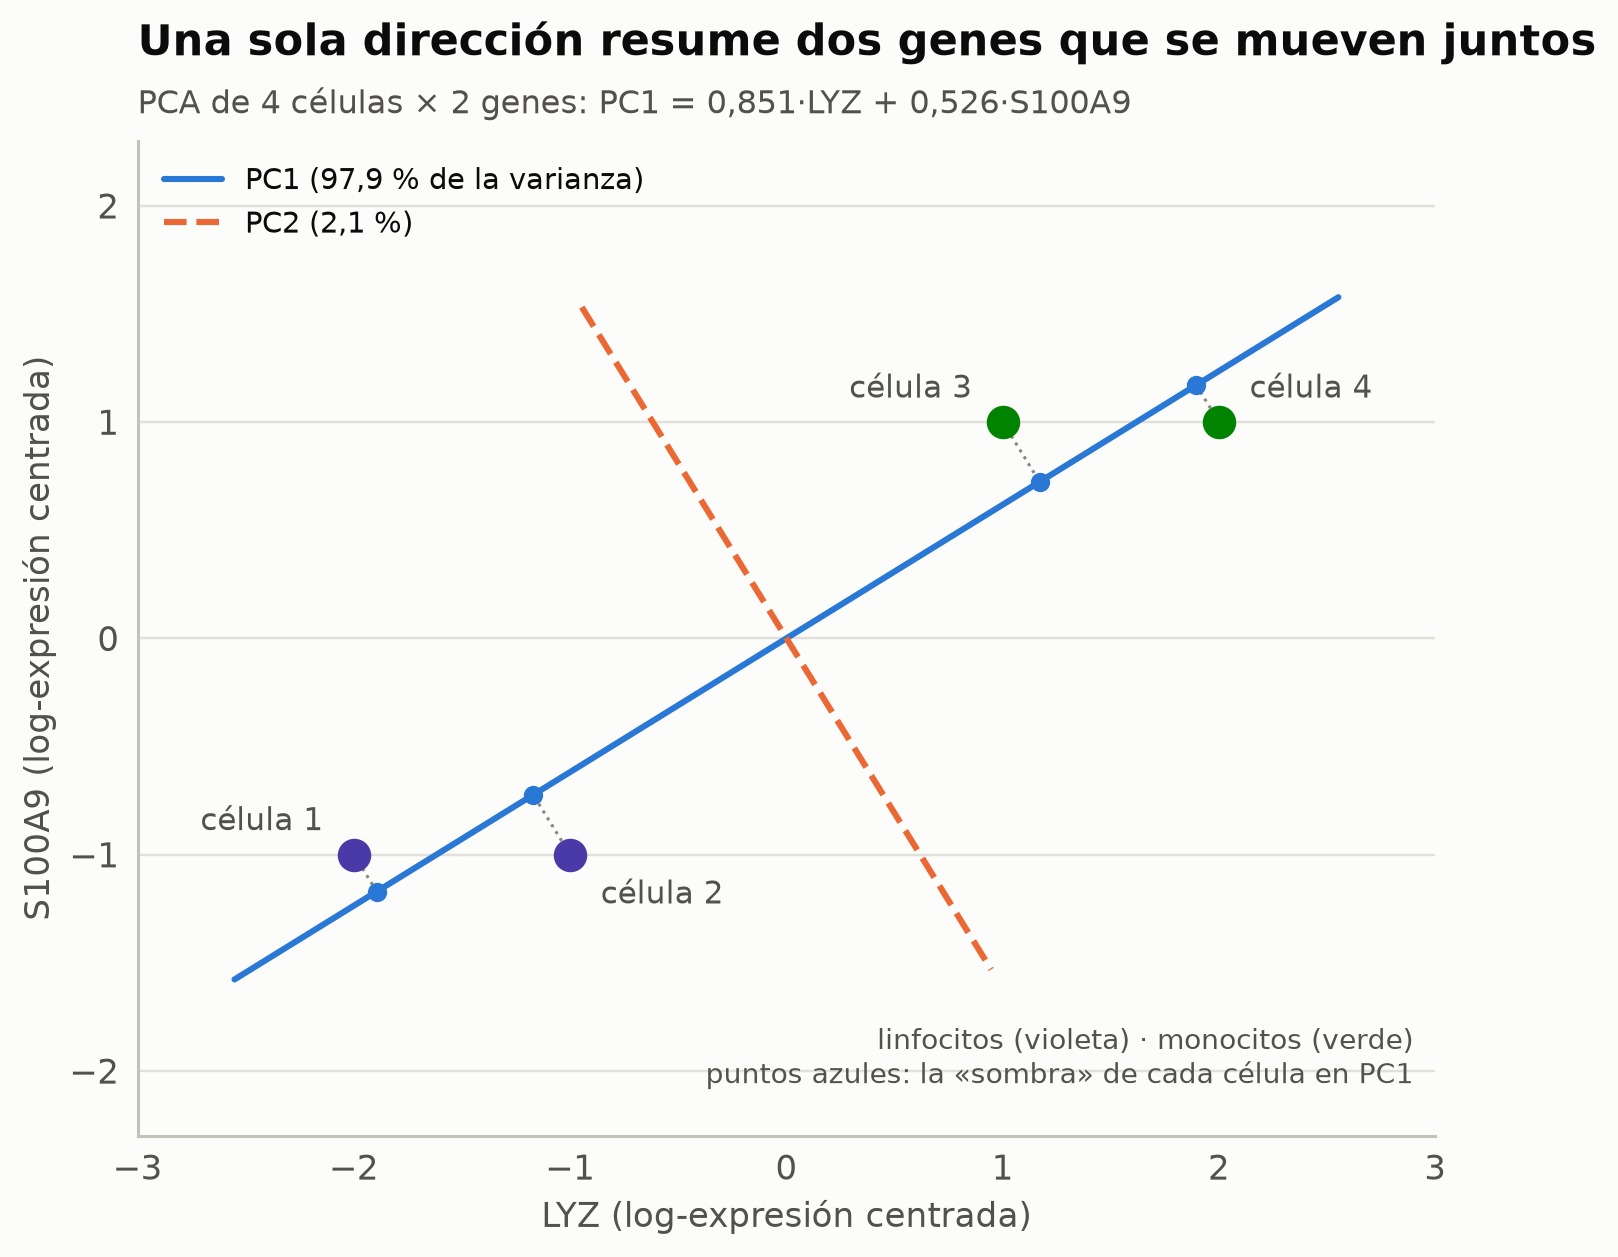

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 5.6))
w1, w2 = W[:, 0], W[:, 1]
tline = np.linspace(-3, 3, 2)
ax.plot(tline * w1[0], tline * w1[1], color=ec.BLUE, lw=2, label="PC1 (97,9 % de la varianza)")
ax.plot(tline * w2[0] * 0.6, tline * w2[1] * 0.6, color=ec.ORANGE, lw=2, ls="--", label="PC2 (2,1 %)")
for i, (x, y) in enumerate(Z_toy):
    proj = (Z_toy[i] @ w1) * w1
    ax.plot([x, proj[0]], [y, proj[1]], color=ec.MUTED, lw=1, ls=":")
    ax.scatter(*proj, s=40, color=ec.BLUE, zorder=4, edgecolor="white")
    ax.scatter(x, y, s=120, color=[ec.VIOLET, ec.VIOLET, ec.GREEN, ec.GREEN][i], zorder=5, edgecolor="white")
    off, ha = [((-10, 8), "right"), ((10, -16), "left"), ((-10, 8), "right"), ((10, 8), "left")][i]
    ax.annotate(f"célula {i + 1}", (x, y), xytext=off, textcoords="offset points", ha=ha,
                fontsize=10, color=ec.INK_2)
ax.set_xlim(-3, 3); ax.set_ylim(-2.3, 2.3); ax.set_aspect("equal")
ax.set_xlabel("LYZ (log-expresión centrada)"); ax.set_ylabel("S100A9 (log-expresión centrada)")
ax.legend(loc="upper left", fontsize=9.5)
ax.text(2.9, -2.1, "linfocitos (violeta) · monocitos (verde)\npuntos azules: la «sombra» de cada célula en PC1",
        ha="right", va="bottom", fontsize=9, color=ec.INK_2)
ec.title(ax, "Una sola dirección resume dos genes que se mueven juntos",
         "PCA de 4 células × 2 genes: PC1 = 0,851·LYZ + 0,526·S100A9")
plt.show()

> 🔎 **Qué observamos.** La recta azul atraviesa la nube por donde más se estira. Al proyectar cada célula sobre ella
> (líneas punteadas) las cuatro quedan ordenadas de linfocito a monocito, y lo que se pierde (la distancia perpendicular
> a la recta) es poquísimo: eso es el 2,1 % que queda para PC2.

### 2.2 El PCA como problema de optimización

Generalicemos. Sea $Z\in\mathbb{R}^{n\times p}$ la matriz de expresión con cada gen centrado (y, habitualmente,
escalado a varianza unitaria y truncado en $\pm10$). La matriz de covarianzas es $S=\frac{1}{n-1}Z^\top Z$. Buscamos la
dirección unitaria $w$ en la que la proyección $Zw$ (la «sombra» de las células sobre la recta) tiene **varianza
máxima**:

$$
\max_{w\in\mathbb{R}^p}\; w^{\top} S\, w \qquad\text{sujeto a}\qquad w^{\top}w = 1.
\tag{12-pca-prob}
$$

La restricción es imprescindible: sin ella bastaría con alargar $w$ para inflar la varianza sin límite. Se resuelve
con un multiplicador de Lagrange, $\mathcal{L}(w,\lambda)=w^\top S w-\lambda(w^\top w-1)$; igualando el gradiente a
cero:

$$
\nabla_w\mathcal{L}=2Sw-2\lambda w=0\;\Longrightarrow\; S\,w=\lambda\,w,\qquad w^\top S w=\lambda\,w^\top w=\lambda.
\tag{12-pca-eig}
$$

| Símbolo | Significado |
|---|---|
| $Z$ | Matriz células $\times$ genes centrada (y escalada); $n$ filas, $p$ columnas |
| $S$ | Matriz de covarianzas entre genes ($p\times p$), simétrica y semidefinida positiva |
| $w$ | Vector de **cargas** (*loadings*): el peso de cada gen en la componente |
| $\lambda$ | Multiplicador de Lagrange; resulta ser la **varianza capturada** por la componente |

Los puntos críticos son los **vectores propios** de $S$, y la varianza capturada es el **valor propio**
correspondiente: el máximo es el vector propio del mayor valor propio. Repitiendo el argumento con la condición
adicional de ser ortogonal a las direcciones ya encontradas se obtienen las siguientes componentes, en orden
decreciente de $\lambda$. Como $S$ es simétrica, sus vectores propios son ortogonales y el procedimiento está bien
definido. En el ejemplo de la sección 2.1, eso es exactamente lo que calculamos a mano.

### 2.3 En la práctica: la descomposición en valores singulares

Con $p=2\,000$ genes, $S$ tendría cuatro millones de entradas y formarla amplifica errores de redondeo. En la práctica
se descompone directamente $Z$:

> **Teorema (PCA mediante la SVD).** Si $Z = U\Sigma V^{\top}$ con $\sigma_1\ge\sigma_2\ge\cdots\ge0$, entonces las
> columnas de $V$ son las direcciones principales, las coordenadas de las células son $ZV = U\Sigma$, la varianza de
> la componente $k$ es $\lambda_k=\sigma_k^2/(n-1)$ y la fracción de varianza explicada es $\lambda_k/\sum_j\lambda_j$.
> Además, $U_k\Sigma_kV_k^{\top}$ (truncada a las $k$ primeras) es la **mejor aproximación de rango $k$** de $Z$ en
> norma de Frobenius (teorema de Eckart-Young; Hastie et al., 2009).

| Símbolo | Significado |
|---|---|
| $U$ ($n\times r$) | Vectores singulares izquierdos: una fila por célula, columnas ortonormales |
| $\Sigma$ | Diagonal con los valores singulares $\sigma_1\ge\sigma_2\ge\dots\ge0$ |
| $V$ ($p\times r$) | Vectores singulares derechos = direcciones principales (cargas); una fila por gen |
| $U\Sigma$ | Coordenadas de las células en las componentes (*scores*, `X_pca` en Scanpy) |
| $\lambda_k=\sigma_k^2/(n-1)$ | Varianza de la componente $k$ |

¿Por qué funciona? Basta sustituir: $Z^\top Z=V\Sigma U^\top U\Sigma V^\top=V\Sigma^2V^\top$, así que
$S\,V=V\,\Sigma^2/(n-1)$: las columnas de $V$ son vectores propios de $S$ con valores propios $\sigma_k^2/(n-1)$. La
última afirmación del teorema es la justificación estadística de usar las primeras componentes como entrada de todo lo
que sigue: son la **mejor compresión lineal posible**, y las componentes de menor varianza, descartadas, contienen sobre
todo ruido de muestreo.

Escribimos el PCA en cinco líneas y lo aplicamos a la simulación del libro, con su misma receta: centrar, dividir por
la desviación típica y truncar en $\pm10$.

In [6]:
def standardize(Y, clip=10.0):
    """Centra cada gen, lo divide por su desviación típica y trunca en ±clip (como sc.pp.scale(max_value=10))."""
    Zs = (Y - Y.mean(0)) / (Y.std(0) + 1e-9)
    return np.clip(Zs, -clip, clip) if clip else Zs

def pca_svd(Zm, k=50):
    """PCA por SVD (teorema del libro): coordenadas UΣ, fracción de varianza explicada y cargas V."""
    U, s, Vt = np.linalg.svd(Zm, full_matrices=False)
    sgn = np.sign(Vt[np.arange(len(Vt)), np.abs(Vt).argmax(1)])   # convenio: la mayor carga, positiva
    U, Vt = U * sgn, Vt * sgn[:, None]
    lam = s ** 2 / (Zm.shape[0] - 1)                # λ_k = σ_k² / (n − 1)
    return U[:, :k] * s[:k], lam / lam.sum(), Vt[:k].T

t0 = time.time()
Z_sim = standardize(Y_sim)
pcs_sim, frac_sim, V_sim = pca_svd(Z_sim, 50)
print("Varianza explicada PC1..5 (%):", np.round(frac_sim[:5] * 100, 2),
      f"| acumulada 10 PC = {frac_sim[:10].sum():.1%} · 30 PC = {frac_sim[:30].sum():.1%}")
for k in range(2):
    top = np.argsort(-np.abs(V_sim[:, k]))[:6]
    print(f"Mayores cargas de PC{k + 1}:", genes_sim[top].tolist())
print(f"⏱️ {time.time() - t0:.1f} s")

Varianza explicada PC1..5 (%): [2.45 1.3  0.98 0.8  0.56] | acumulada 10 PC = 8.1% · 30 PC = 15.2%
Mayores cargas de PC1: ['LYZ', 'G0248', 'S100A9', 'S100A8', 'CD14', 'G1088']
Mayores cargas de PC2: ['G0305', 'G0747', 'G1870', 'G0230', 'G1119', 'G1734']
⏱️ 0.1 s


> 🔎 **Qué observamos.** Exactamente las cifras del libro: PC1 explica el **2,45 %** de la varianza y las 30 primeras,
> el **15,2 %**. Las mayores cargas de PC1 son genes de monocito (*LYZ*, *S100A9*, *S100A8*, *CD14*) más dos genes de
> fondo que la simulación asoció al programa mieloide; las de PC2 son genes anónimos `G…`: los del **estado continuo**
> que el simulador introdujo dentro de las células T CD4 (de *naive* a memoria). PC1 separa el mundo mieloide del
> linfoide; PC2, un proceso que ocurre *dentro* de un tipo.

### 2.4 ¿Cuántas componentes?

Un 2,45 % parece poquísimo. Es poco en términos absolutos porque el **ruido de Poisson** del muestreo de moléculas se
reparte en *todas* las direcciones y se lleva la mayor parte de la varianza total. La pregunta útil no es «¿cuánta
varianza explica?» sino «¿cuánta **más** de la que explicaría el puro ruido?».

Para responderla construimos un **modelo nulo**: permutamos las células de forma independiente dentro de cada gen.
Eso conserva la distribución de cada gen (su media, su varianza, sus ceros) pero **destruye las correlaciones** entre
genes, que son justamente la señal que busca el PCA. Si una componente real no supera a la mayor componente del nulo,
no la distinguimos del ruido.

> 🤔 **Antes de ejecutar, prediga…** La simulación tiene siete tipos celulares y un estado continuo dentro de las T
> CD4. ¿Cuántas componentes espera que superen al nulo? (Pista: con siete grupos, ¿cuántos contrastes independientes
> hay entre sus medias?)

In [7]:
rng_null = np.random.default_rng(9)                 # la semilla del generador del libro
Y_perm = Y_sim.copy()
for j in range(Y_perm.shape[1]):
    Y_perm[:, j] = rng_null.permutation(Y_perm[:, j])  # permutar células dentro de cada gen
s_null = np.linalg.svd(standardize(Y_perm, clip=None), compute_uv=False)
frac_null_sim = s_null ** 2 / (s_null ** 2).sum()
n_sig_sim = int(np.sum(frac_sim > frac_null_sim[0]))
print(f"Nulo permutado: PC1 = {frac_null_sim[0]:.2%}  ·  componentes reales por encima del nulo: {n_sig_sim}")

Nulo permutado: PC1 = 0.39%  ·  componentes reales por encima del nulo: 7


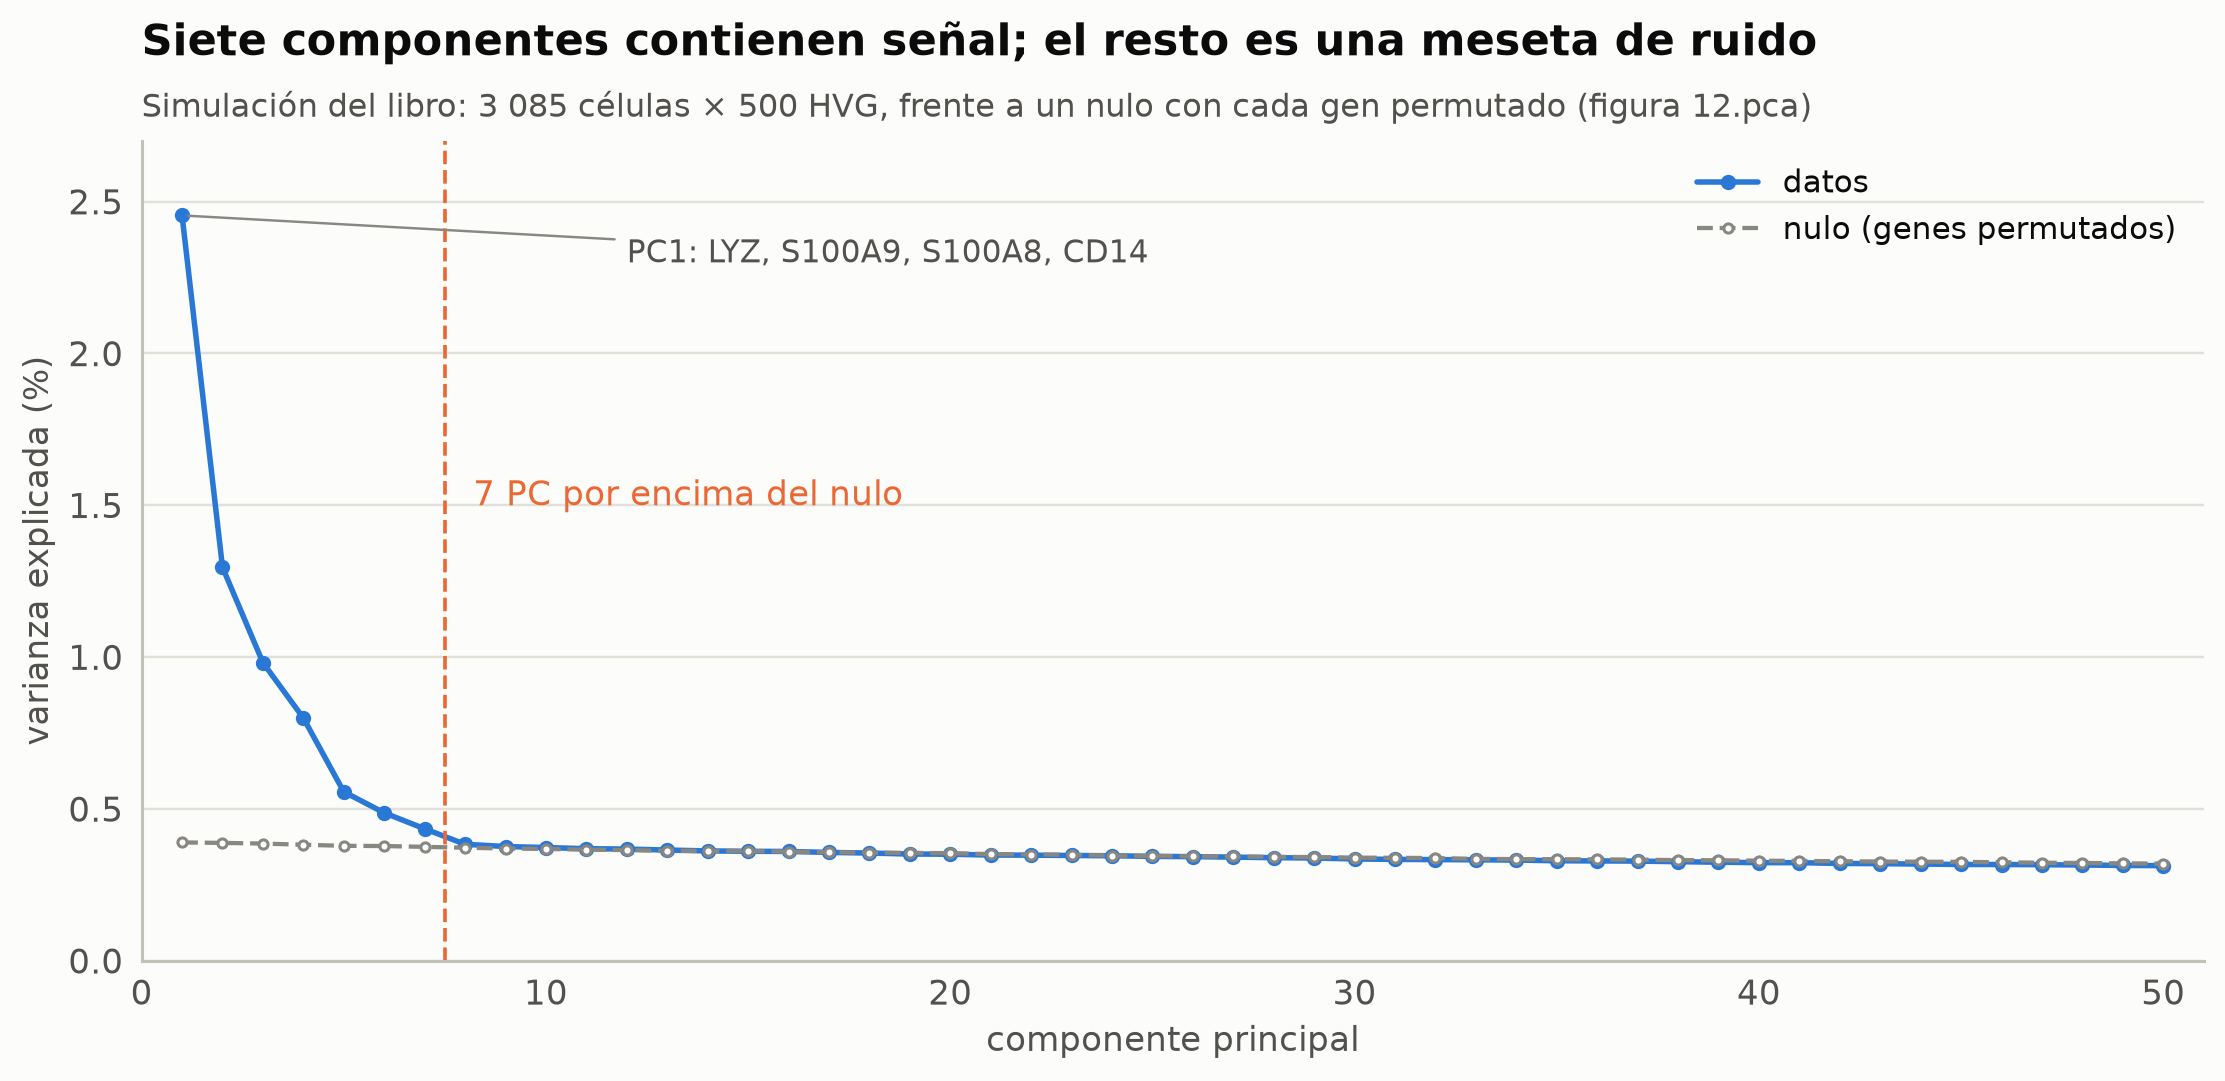

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.8))
pcx = np.arange(1, 51)
ax.plot(pcx, frac_sim[:50] * 100, "-o", color=ec.BLUE, ms=4, lw=1.8, label="datos")
ax.plot(pcx, frac_null_sim[:50] * 100, "--o", color=ec.MUTED, ms=3, mfc="white", lw=1.4,
        label="nulo (genes permutados)")
ax.axvline(n_sig_sim + 0.5, color=ec.ORANGE, ls="--", lw=1.2)
ax.text(n_sig_sim + 1.2, 1.5, f"{n_sig_sim} PC por encima del nulo", color=ec.ORANGE, fontsize=11)
ax.annotate("PC1: LYZ, S100A9, S100A8, CD14", (1, frac_sim[0] * 100), xytext=(12, 2.3), fontsize=10,
            color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=0.8))
ax.set_xlim(0, 51); ax.set_ylim(0, 2.7)
ax.set_xlabel("componente principal"); ax.set_ylabel("varianza explicada (%)")
ax.legend(loc="upper right")
ec.title(ax, "Siete componentes contienen señal; el resto es una meseta de ruido",
         "Simulación del libro: 3 085 células × 500 HVG, frente a un nulo con cada gen permutado (figura 12.pca)")
plt.show()

> 🔎 **Qué observamos.** En los datos permutados ninguna componente supera el **0,39 %**; en los reales, **siete**
> sí: tantas como la estructura simulada (siete tipos celulares definen seis contrastes entre medias, más el estado
> continuo dentro de las T CD4). A partir de la octava la curva azul se aplana en una meseta paralela a la del nulo.
> Ese «codo» (*elbow plot*) es la herramienta clásica para elegir componentes.

En la práctica se usan **30–50 componentes**, bastantes más de las que superan al nulo. ¿Por qué pasarse? Porque la
asimetría de costos es enorme: tomar componentes de más es barato (añaden un poco de ruido, que los métodos basados
en vecinos toleran bien); tomar de menos puede **fundir poblaciones raras**, cuya señal vive precisamente en una
componente de baja varianza (una población del 1 % de las células aporta muy poca varianza total).

> ✅ **Compruebe su comprensión.** Una muestra de médula ósea contiene un 0,5 % de blastos leucémicos con un programa
> transcripcional propio. Usted elige 5 PC porque «el codo está en 5». ¿Qué riesgo corre y cómo lo detectaría?
> *(Respuesta: los blastos podrían definir la PC 12 o la 20 y quedar mezclados con otras células en el espacio de
> 5 PC; conviene repetir el análisis con 30–50 PC y comprobar si aparece un grupo nuevo con marcadores coherentes.)*

### 2.5 Datos reales: el PCA de 2 638 células de sangre

Repetimos todo sobre PBMC 3k: SVD de la matriz $Z$ (2 638 × 2 000), modelo nulo con genes permutados y comparación
con la función de Scanpy `sc.tl.pca`, que es lo que se usa en producción.

In [9]:
t0 = time.time()
pcs, frac, V = pca_svd(Z, 50)
rng = np.random.default_rng(0)
Z_perm = np.column_stack([rng.permutation(col) for col in Z.T])
s_perm = np.linalg.svd(standardize(Z_perm, clip=None), compute_uv=False)
frac_null = s_perm ** 2 / (s_perm ** 2).sum()
n_sig = int(np.sum(frac > frac_null[0]))
print("Varianza explicada PC1..6 (%):", np.round(frac[:6] * 100, 2),
      f"| acumulada 30 PC = {frac[:30].sum():.1%}")
print(f"Nulo: PC1 = {frac_null[0]:.2%} · componentes reales por encima del nulo: {n_sig}")

# La misma operación con Scanpy (escalado + PCA sobre los HVG)
ad_sc = adata.copy()
sc.pp.scale(ad_sc, max_value=10)
sc.tl.pca(ad_sc, n_comps=50, mask_var="highly_variable")
r = [abs(np.corrcoef(pcs[:, k], ad_sc.obsm["X_pca"][:, k])[0, 1]) for k in range(50)]
print(f"|correlación| entre nuestras PC y las de Scanpy: PC1–10 ≥ {min(r[:10]):.4f}; PC1–30 ≥ {min(r[:30]):.4f}")
print("Varianza explicada según Scanpy PC1..6 (%):",
      np.round(ad_sc.uns["pca"]["variance_ratio"][:6] * 100, 2))
del ad_sc
print(f"⏱️ {time.time() - t0:.1f} s")

Varianza explicada PC1..6 (%): [2.53 1.26 1.01 0.87 0.51 0.28] | acumulada 30 PC = 10.8%
Nulo: PC1 = 0.17% · componentes reales por encima del nulo: 19


|correlación| entre nuestras PC y las de Scanpy: PC1–10 ≥ 0.9994; PC1–30 ≥ 0.9994
Varianza explicada según Scanpy PC1..6 (%): [2.53 1.26 1.01 0.87 0.51 0.28]
⏱️ 3.0 s


> 🔎 **Qué observamos.** Nuestras cinco líneas y Scanpy dan las mismas componentes (correlación absoluta ≈ 1: el
> **signo** de cada componente es arbitrario, porque si $w$ es vector propio también lo es $-w$). La varianza
> explicada coincide hasta el segundo decimal, aunque Scanpy estandariza con la desviación típica muestral ($n-1$) y
> usa un algoritmo iterativo (ARPACK) que calcula sólo las 50 primeras: esos detalles sólo mueven decimales más finos. En los datos reales hay más componentes por
> encima del nulo que en la simulación: la sangre real tiene más programas (plaquetas, interferón, ciclo celular,
> subtipos de T…) que los siete tipos del simulador.

Para colorear las figuras necesitamos alguna etiqueta. Encontrar los tipos celulares es el tema de la lección 12.3
(grafo de vecinos, Leiden y genes marcadores), así que hoy usaremos **etiquetas provisionales**: para cada célula
promediamos la expresión (en unidades $z$) de unos pocos marcadores clásicos de cada tipo, suavizamos esa puntuación
entre sus 15 vecinos más cercanos en el espacio de 30 PC (para amortiguar los ceros) y asignamos el tipo con la
puntuación más alta. Es un atajo razonable para mirar, **no** una anotación publicable.

In [10]:
MARKERS = {"T CD4": ["IL7R", "CD3E", "CD3D", "LDHB"], "T CD8": ["CD8A", "CD8B", "CD3E"],
           "NK": ["GNLY", "NKG7", "GZMB", "PRF1"], "B": ["MS4A1", "CD79A", "CD79B"],
           "Mono CD14": ["CD14", "LYZ", "S100A9", "S100A8"], "Mono FCGR3A": ["FCGR3A", "MS4A7", "LST1"],
           "DC": ["FCER1A", "CLEC10A", "CD1C"], "Plaquetas": ["PPBP", "PF4"]}
X30 = pcs[:, :30]                                     # el espacio de trabajo: 30 PC
nn_idx = NearestNeighbors(n_neighbors=15).fit(X30).kneighbors(X30)[1]
def expr(gene):
    return adata[:, gene].X.toarray().ravel()
score = np.column_stack([np.mean([expr(g) for g in gs], axis=0) for gs in MARKERS.values()])
score = (score - score.mean(0)) / score.std(0)
cell_type = np.array(list(MARKERS))[score[nn_idx].mean(1).argmax(1)]
adata.obs["tipo_provisional"] = pd.Categorical(cell_type, categories=list(MARKERS))
print(adata.obs.tipo_provisional.value_counts().to_frame("células").T.to_string())

tipo_provisional  T CD4  Mono CD14    B  T CD8   NK  Mono FCGR3A  DC  Plaquetas
células            1131        439  343    255  219          197  38         16


> ⚠️ **Etiquetas provisionales, recuentos provisionales.** Compare estas cifras con las del tutorial clásico de Scanpy,
> que anota a mano los clusters de Leiden: allí hay unas 155 NK y unos 150 monocitos FCGR3A. Nuestro atajo asigna 219 NK
> y 197 monocitos FCGR3A, bastante más de lo habitual: con tan pocos marcadores, es probable que células fronterizas
> (T CD8 efectoras con *NKG7* y *GZMB*, monocitos con *LST1* alto) caigan del lado NK o FCGR3A. Basta para colorear
> figuras; la anotación seria llega en la lección 12.3.

Ahora miremos qué genes definen las tres primeras componentes (las **cargas** $V$) y cómo se ven las células en el
plano PC1–PC2.

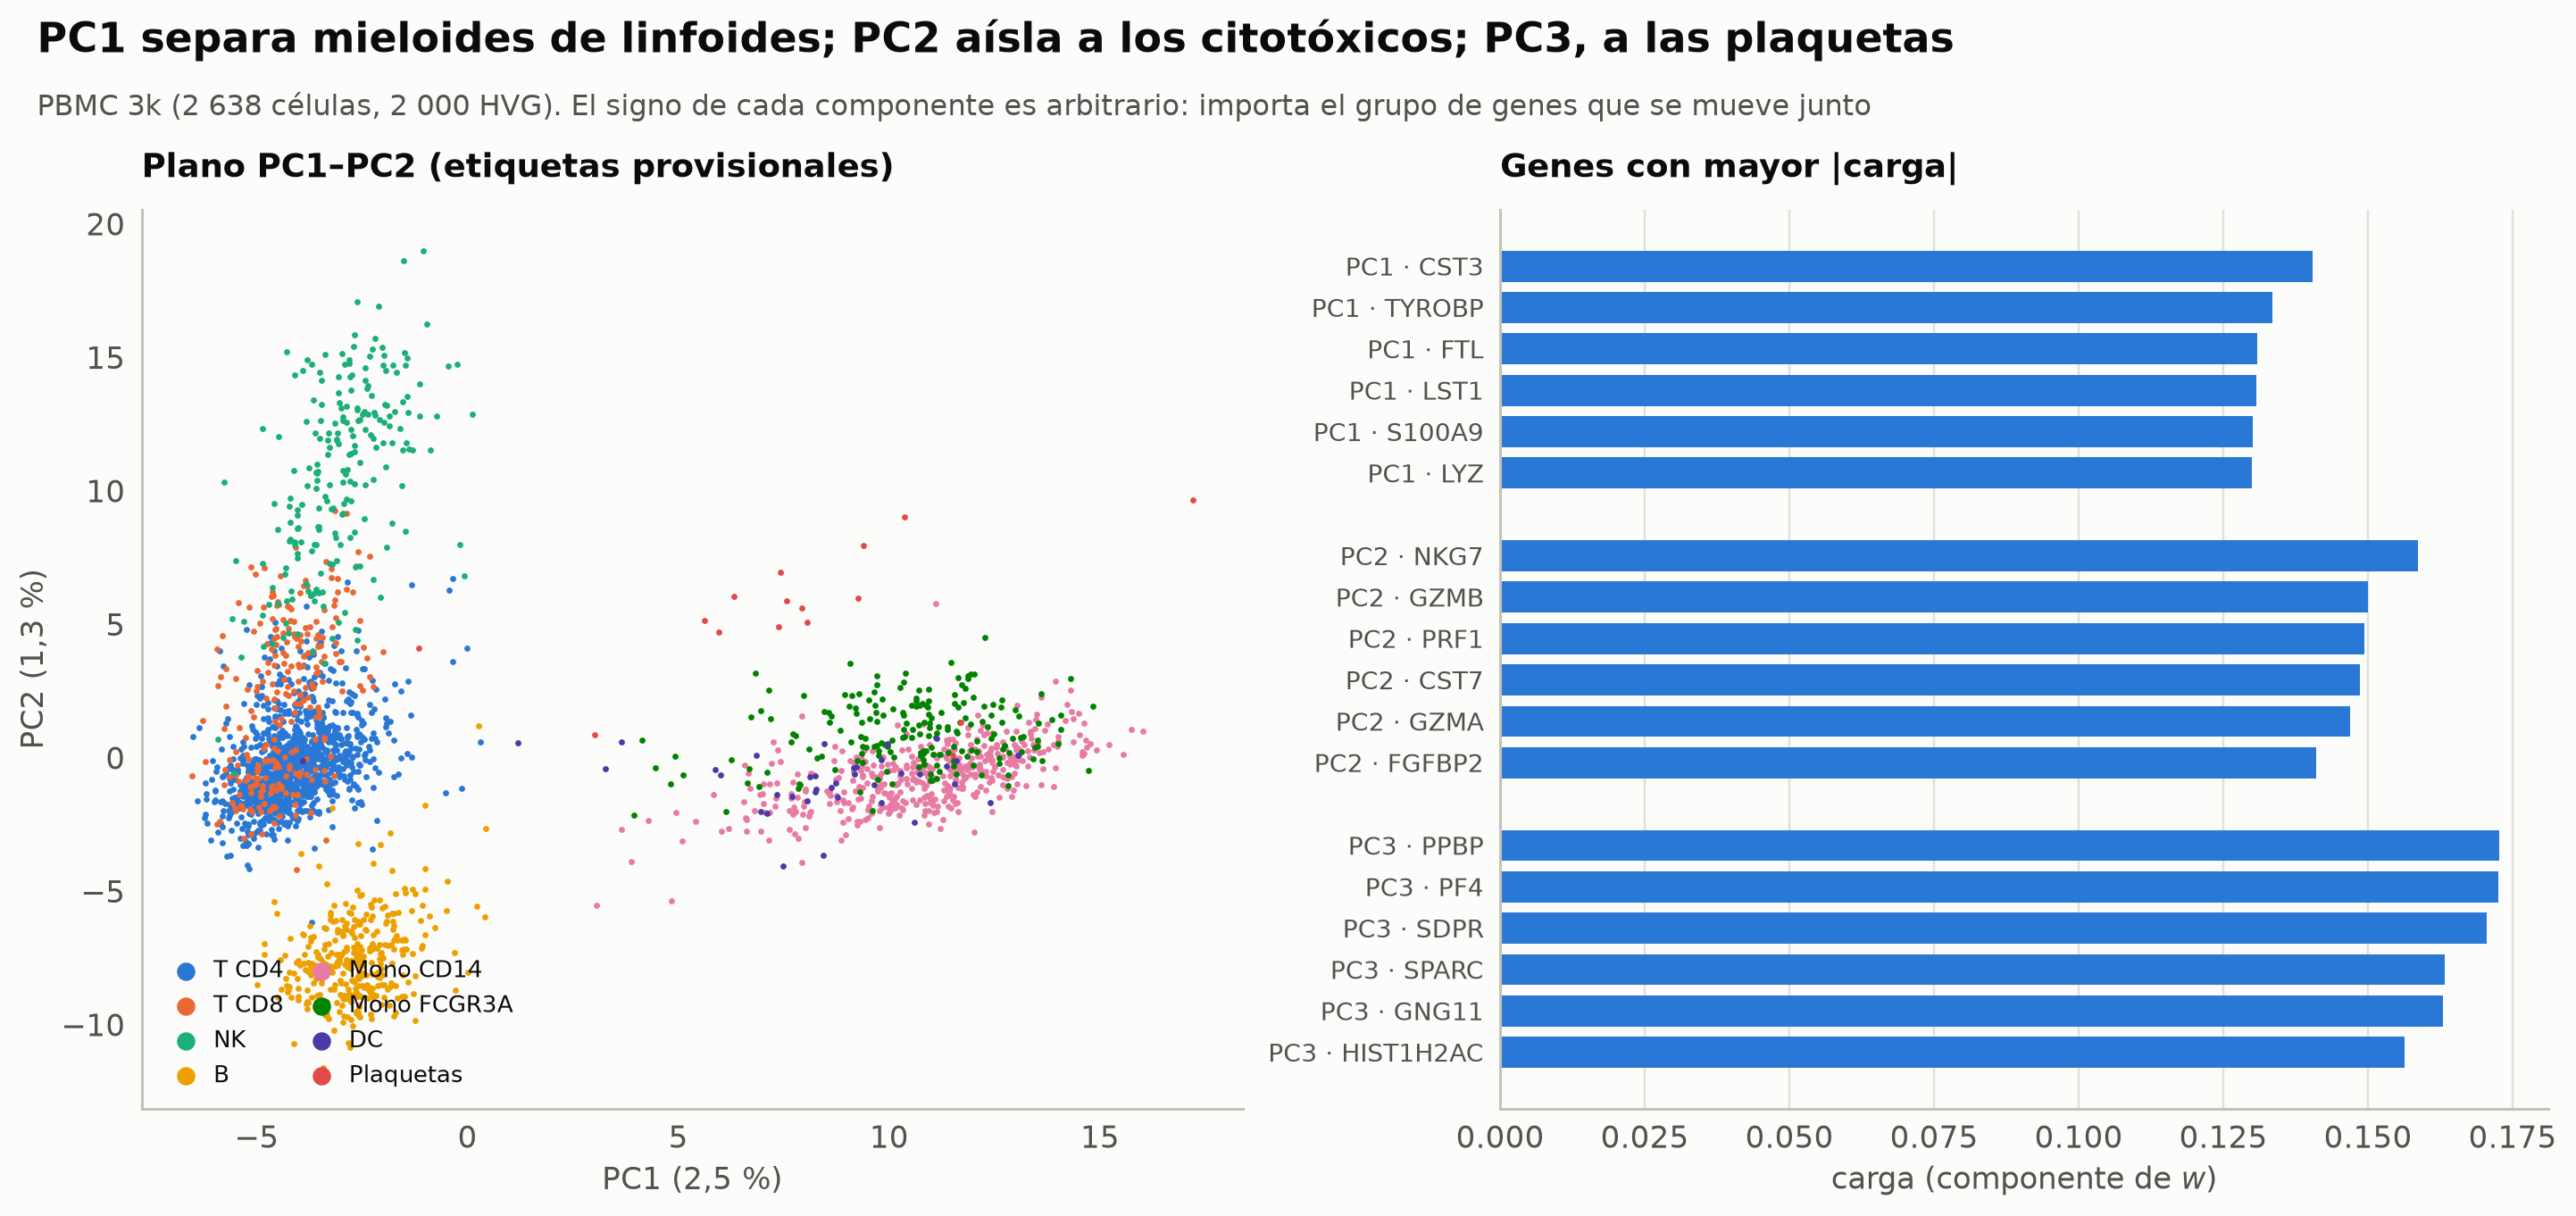

In [11]:
fig = plt.figure(figsize=(13, 5.4))
gs = fig.add_gridspec(1, 2, width_ratios=[1.05, 1])
axl = fig.add_subplot(gs[0]); axs = fig.add_subplot(gs[1])
order = np.random.default_rng(0).permutation(adata.n_obs)
for t in MARKERS:
    m = cell_type[order] == t
    axl.scatter(pcs[order][m, 0], pcs[order][m, 1], s=5, color=TYPE_COLORS[t], lw=0, label=t)
axl.set_xlabel(f"PC1 ({pct(frac[0])})"); axl.set_ylabel(f"PC2 ({pct(frac[1])})"); axl.grid(False)
axl.legend(markerscale=3, fontsize=8.5, loc="lower left", ncol=2, handletextpad=0.2, columnspacing=0.6)
axl.set_title("Plano PC1–PC2 (etiquetas provisionales)", fontsize=12, loc="left")
# cargas de PC1..PC3: los 6 genes con mayor |carga| en cada una
rows = []
for k in range(3):
    for g in np.argsort(-np.abs(V[:, k]))[:6]:
        rows.append((f"PC{k + 1}", hvg_names[g], V[g, k]))
ypos = []; y = 0
for i, (pc, g, v) in enumerate(rows):
    if i and rows[i - 1][0] != pc:
        y += 1
    ypos.append(-y); y += 1
axs.barh(ypos, [r_[2] for r_ in rows], color=[ec.BLUE if r_[2] > 0 else ec.ORANGE for r_ in rows], height=0.75)
axs.set_yticks(ypos, [f"{r_[0]} · {r_[1]}" for r_ in rows], fontsize=9)
axs.axvline(0, color=ec.BASELINE, lw=1); axs.grid(axis="x"); axs.grid(axis="y", visible=False)
axs.set_xlabel("carga (componente de $w$)")
axs.set_title("Genes con mayor |carga|", fontsize=12, loc="left")
ec.fig_title(fig, "PC1 separa mieloides de linfoides; PC2 aísla a los citotóxicos; PC3, a las plaquetas",
             "PBMC 3k (2 638 células, 2 000 HVG). El signo de cada componente es arbitrario: importa el grupo de genes que se mueve junto")
plt.show()

> 🔎 **Qué observamos.** Las cargas cuentan la biología sin que nadie se la haya dicho al algoritmo. PC1 reúne genes
> mieloides (*CST3*, *TYROBP*, *LYZ*, *S100A9*, *FTL*, *LST1*): es el eje monocito ↔ linfocito, igual que en la simulación
> del libro. PC2 junta el arsenal citotóxico (*NKG7*, *GZMB*, *PRF1*, *CST7*, *GZMA*): separa NK y T CD8 efectoras del
> resto. PC3 está dominada por genes de plaquetas (*PPBP*, *PF4*): una población de apenas 16 células que, aun así,
> se lleva una componente entera porque su programa es muy distinto. En el plano PC1–PC2 las células B sí se despegan (hacia abajo), pero T CD4 y
> T CD8 quedan **superpuestas**, igual que los monocitos CD14, los FCGR3A y las DC: se separan en direcciones de menor
> varianza. Ésa es la limitación que motivará t-SNE y
> UMAP.

### 2.6 Explore la nube en 3D

La figura interactiva muestra las tres primeras componentes. Gírela: busque el ángulo en el que las células B se
separan de las T (pista: no está en el plano PC1–PC2). Al pasar el cursor verá el código de barras de la célula, su
tipo provisional y la expresión de dos marcadores.

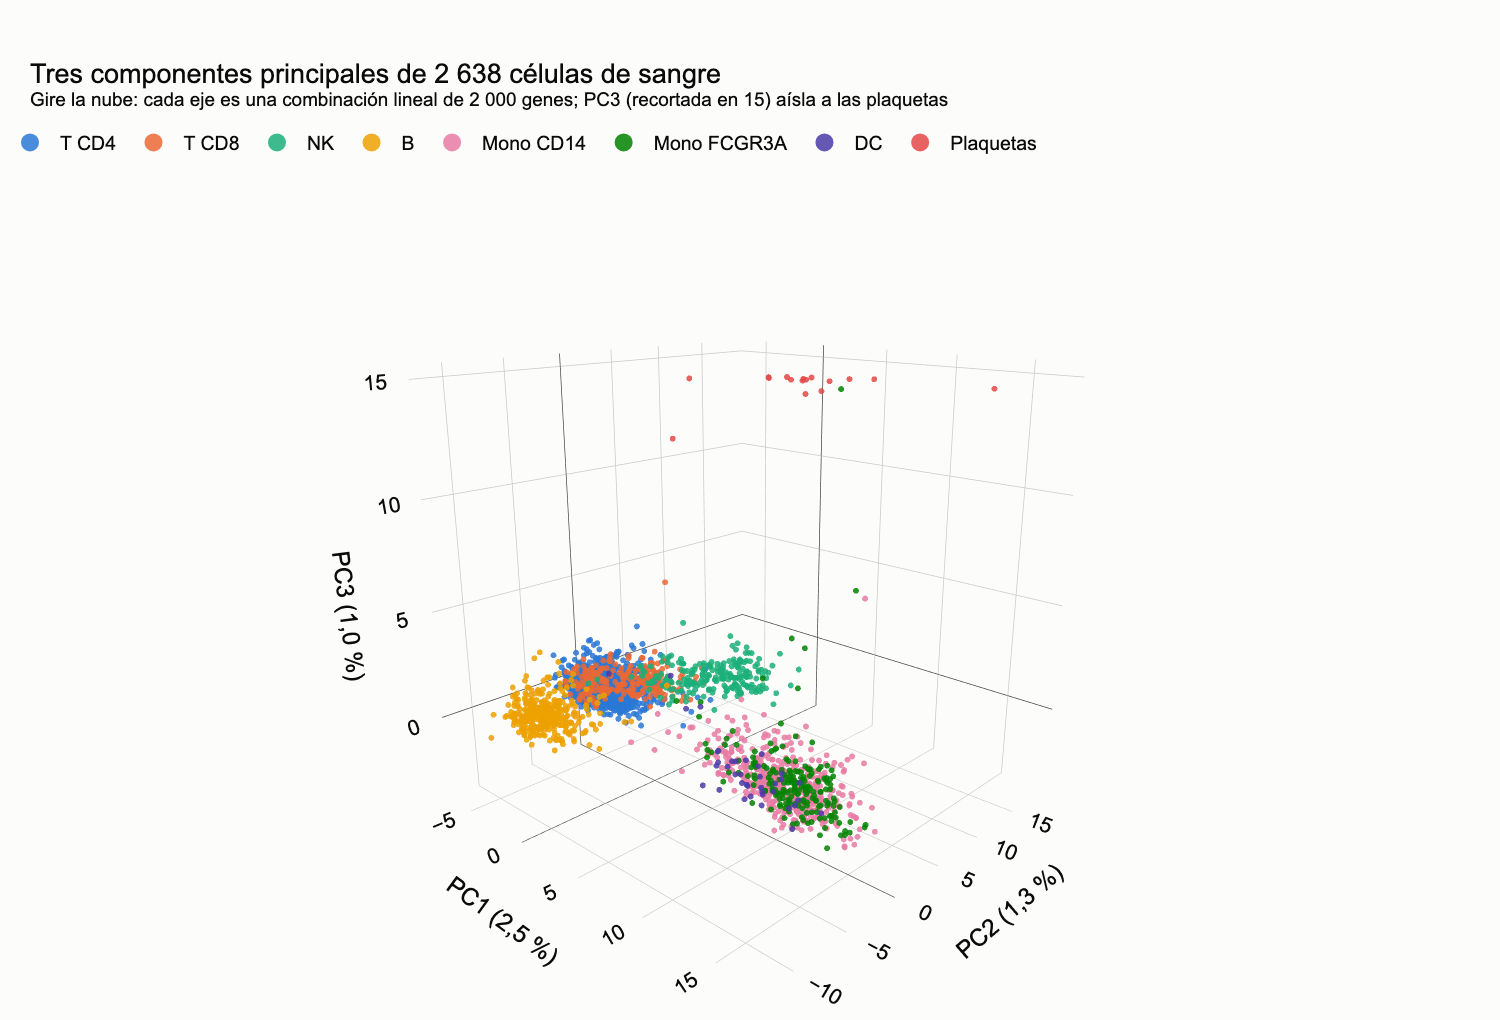

In [12]:
PC3_CAP = 15            # 16 plaquetas llegan a PC3 ≈ 70: recortamos el eje para que no aplasten la nube
dfp = pd.DataFrame({"PC1": pcs[:, 0], "PC2": pcs[:, 1], "PC3": np.minimum(pcs[:, 2], PC3_CAP),
                    "PC3_real": pcs[:, 2], "tipo": cell_type,
                    "barcode": adata.obs_names, "LYZ": expr("LYZ").round(2), "NKG7": expr("NKG7").round(2),
                    "MS4A1": expr("MS4A1").round(2), "UMI": adata.obs.total_counts.astype(int)})
fig = px.scatter_3d(dfp, x="PC1", y="PC2", z="PC3", color="tipo", color_discrete_map=TYPE_COLORS,
                    category_orders={"tipo": list(MARKERS)},
                    custom_data=["barcode", "tipo", "LYZ", "NKG7", "MS4A1", "UMI", "PC3_real"])
fig.update_traces(marker=dict(size=2.2, opacity=0.85),
                  hovertemplate="<b>%{customdata[0]}</b><br>tipo provisional: %{customdata[1]}"
                                "<br>PC1 = %{x:.1f} · PC2 = %{y:.1f} · PC3 = %{customdata[6]:.1f}"
                                "<br>log-expresión: LYZ %{customdata[2]} · NKG7 %{customdata[3]}"
                                " · MS4A1 %{customdata[4]}<br>UMI totales: %{customdata[5]}<extra></extra>")
fig.update_layout(title="Tres componentes principales de 2 638 células de sangre<br><sup>Gire la nube: cada eje"
                        " es una combinación lineal de 2 000 genes; PC3 (recortada en 15) aísla a las plaquetas</sup>",
                  height=680, margin=dict(l=0, r=0, t=110, b=0), legend_title_text="",
                  legend=dict(orientation="h", yanchor="bottom", y=1.0, x=0, itemsizing="constant"),
                  scene=dict(xaxis_title=f"PC1 ({pct(frac[0])})", yaxis_title=f"PC2 ({pct(frac[1])})",
                             zaxis_title=f"PC3 ({pct(frac[2])})", aspectmode="cube",
                             camera=dict(eye=dict(x=1.5, y=-1.6, z=0.7))))
fig.show()

### 2.7 La sombra más grande

Volvamos a la lámpara del principio, esta vez con la simulación del libro (siete tipos conocidos y sin valores
extremos como las plaquetas reales). Si miramos la nube de sus tres primeras componentes desde una dirección $d$, la sombra en la
pared es la proyección sobre el plano perpendicular a $d$, y su «tamaño» (la varianza total de la sombra) es
$\lambda_1+\lambda_2+\lambda_3-d^\top\Lambda d$. La animación mueve la lámpara desde el eje PC1 (la sombra muestra
PC2–PC3, pequeña) hasta el eje PC3 (la sombra muestra PC1–PC2, la mayor posible). El PCA no es más que el ángulo
que maximiza la sombra.

![La lámpara gira alrededor de la nube de 3 PC de la simulación del libro: la sombra crece hasta que la dirección de observación coincide con PC3 y en la pared queda el plano PC1–PC2, el de máxima varianza](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-12-celula-unica/12.2_sombra_pca.gif)

*La lámpara gira alrededor de la nube de 3 PC de la simulación del libro: la sombra crece hasta que la dirección de observación coincide con PC3 y en la pared queda el plano PC1–PC2, el de máxima varianza*

In [13]:
P3 = pcs_sim[:, :3]                                  # simulación del libro: 3 primeras PC
lam3 = P3.var(0, ddof=1)
# Trayectoria de la dirección de observación d: de e1 a e2 y de e2 a e3 (arcos de círculo máximo)
angles = np.linspace(0, np.pi / 2, 24)
dirs = [np.array([np.cos(a), np.sin(a), 0.0]) for a in angles] + \
       [np.array([0.0, np.cos(a), np.sin(a)]) for a in angles[1:]]
dirs += [dirs[-1]] * 8                                                    # pausa final
def plane_basis(d):
    """Dos vectores ortonormales que generan el plano perpendicular a d (la pared)."""
    a = np.array([0.0, 0.0, 1.0]) if abs(d[2]) < 0.9 else np.array([1.0, 0.0, 0.0])
    e1 = np.cross(d, a); e1 /= np.linalg.norm(e1)
    return e1, np.cross(d, e1)
def shadow_var(d):
    return lam3.sum() - d @ np.diag(lam3) @ d

# Para que la sombra no «salte», orientamos la base de forma continua entre cuadros
bases = []; prev = None
for d in dirs:
    e1, e2 = plane_basis(d)
    if prev is not None:
        if e1 @ prev[0] < 0: e1 = -e1
        if e2 @ prev[1] < 0: e2 = -e2
    bases.append((e1, e2)); prev = (e1, e2)
sv = np.array([shadow_var(d) for d in dirs])
cols = np.array([ec.CATEGORICAL[t] for t in T_sim])

fig = plt.figure(figsize=(12.5, 5.6))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.86))
g2 = fig.add_gridspec(1, 2, width_ratios=[1.1, 1])
axs_ = fig.add_subplot(g2[0]); axv = fig.add_subplot(g2[1])
lim = np.percentile(np.abs(P3), 99.7)
sca = axs_.scatter(np.zeros(len(P3)), np.zeros(len(P3)), s=3, c=cols, lw=0)
axs_.set_xlim(-lim, lim); axs_.set_ylim(-lim, lim); axs_.set_aspect("equal"); axs_.grid(False)
axs_.set_xticks([]); axs_.set_yticks([])
axs_.set_title("sombra en la pared", fontsize=12, loc="left")
dtxt = axs_.text(0.02, 0.02, "", transform=axs_.transAxes, fontsize=10, color=ec.INK_2, zorder=5,
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))
step = np.arange(len(dirs))
axv.plot(step, sv, color=ec.BASELINE, lw=1.5)
for val, name, col, va in [(lam3[1] + lam3[2], "λ₂ + λ₃ (lámpara en PC1)", ec.MUTED, "bottom"),
                           (lam3[0] + lam3[2], "λ₁ + λ₃ (lámpara en PC2)", ec.MUTED, "top"),
                           (lam3[0] + lam3[1], "λ₁ + λ₂: el máximo (lámpara en PC3)", ec.BLUE, "bottom")]:
    axv.axhline(val, color=col, ls=":", lw=1)
    axv.text(0, val, name, ha="left", va=va, fontsize=9.5, color=ec.INK_2)
pt, = axv.plot([], [], "o", color=ec.ORANGE, ms=9)
trail, = axv.plot([], [], color=ec.ORANGE, lw=2.2)
axv.set_xlabel("posición de la lámpara (cuadro)"); axv.set_ylabel("varianza de la sombra")
axv.set_ylim((lam3[1] + lam3[2]) * 0.8, (lam3[0] + lam3[1]) * 1.08)
axv.set_title("tamaño de la sombra", fontsize=12, loc="left")
fig.text(0.01, 0.985, "El PCA elige el ángulo en el que la sombra es más grande", fontsize=15,
         fontweight="bold", color=ec.INK, va="top")
fig.text(0.01, 0.935, "Simulación del libro: 3 primeras PC proyectadas sobre el plano perpendicular a la dirección de "
         "observación d; colores: los 7 tipos verdaderos", fontsize=10.5, color=ec.INK_2, va="top")

def update(f):
    e1, e2 = bases[f]
    sca.set_offsets(np.column_stack([P3 @ e1, P3 @ e2]))
    d = dirs[f]
    dtxt.set_text(f"d = ({d[0]:+.2f}, {d[1]:+.2f}, {d[2]:+.2f}) en ejes PC1, PC2, PC3")
    pt.set_data([f], [sv[f]]); trail.set_data(step[: f + 1], sv[: f + 1])
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(dirs), interval=140, name="12.2_sombra_pca")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Con la lámpara en PC1, la pared sólo recibe PC2 y PC3: el eje mieloide–linfoide desaparece
> y monocitos y linfocitos se amontonan uno encima del otro. A medida que la lámpara gira, ese eje se despliega y la
> sombra crece hasta su máximo, $\lambda_1+\lambda_2$, cuando miramos a lo largo de PC3. Ningún otro ángulo da una
> sombra mayor: ésa es la afirmación del teorema de Eckart-Young para $k=2$.

### 2.8 Eckart-Young en números: ¿cuánto se pierde al comprimir?

El teorema dice que la reconstrucción de rango $k$, $Z_k=U_k\Sigma_kV_k^\top$, es la mejor posible y que el error
relativo es exactamente la varianza **no** explicada: $\lVert Z-Z_k\rVert_F^2/\lVert Z\rVert_F^2=1-\sum_{j\le k}
\lambda_j/\sum_j\lambda_j$. Comprobémoslo con $k=30$.

In [14]:
U_, s_, Vt_ = np.linalg.svd(Z, full_matrices=False)
for k in (2, 10, 30, 50):
    Zk = (U_[:, :k] * s_[:k]) @ Vt_[:k]
    err = np.linalg.norm(Z - Zk) ** 2 / np.linalg.norm(Z) ** 2
    print(f"k = {k:2d}: error relativo ‖Z − Z_k‖²/‖Z‖² = {err:.4f}  ·  1 − varianza explicada = "
          f"{1 - (s_[:k] ** 2).sum() / (s_ ** 2).sum():.4f}  ·  números guardados: {k * (Z.shape[0] + Z.shape[1]):,} "
          f"de {Z.size:,}")
del U_, Vt_, Zk

k =  2: error relativo ‖Z − Z_k‖²/‖Z‖² = 0.9621  ·  1 − varianza explicada = 0.9621  ·  números guardados: 9,276 de 5,276,000
k = 10: error relativo ‖Z − Z_k‖²/‖Z‖² = 0.9270  ·  1 − varianza explicada = 0.9270  ·  números guardados: 46,380 de 5,276,000
k = 30: error relativo ‖Z − Z_k‖²/‖Z‖² = 0.8919  ·  1 − varianza explicada = 0.8919  ·  números guardados: 139,140 de 5,276,000
k = 50: error relativo ‖Z − Z_k‖²/‖Z‖² = 0.8593  ·  1 − varianza explicada = 0.8593  ·  números guardados: 231,900 de 5,276,000


> 🔎 **Qué observamos.** Las dos columnas coinciden: el teorema se cumple al pie de la letra. Con 30 PC se guarda
> menos del 3 % de los números y el error relativo es grande (≈ 89 %)… pero ese 80 % es, sobre todo, ruido de
> muestreo repartido en miles de direcciones. Lo que se conserva es la **estructura correlacionada**, que es lo único
> que nos interesa para encontrar vecinos. La compresión de PCA es una limpieza, no sólo un ahorro.

> ✅ **Compruebe su comprensión.** ¿Por qué el PCA de un conjunto de células **no** se hace sobre las cuentas crudas
> sino sobre $\log(1+\text{CP10k})$ escaladas? Piense en qué genes dominarían $S$ si no se normalizara ni escalara.
> *(Respuesta: sin normalizar, PC1 reflejaría el tamaño de librería de cada célula; sin logaritmo ni escalado, los
> pocos genes con muchísimas cuentas —ribosomales, mitocondriales, *MALAT1*— acapararían la varianza.)*

## 3. t-SNE: conservar vecindarios

El PCA es **lineal y global**: preserva bien las grandes distancias y comprime los grupos pequeños unos sobre otros
(lo acabamos de ver con T CD4 y T CD8). El *t-distributed stochastic neighbor embedding* (t-SNE), propuesto por van
der Maaten y Hinton en 2008 y popularizado en célula única, **invierte la prioridad**: renuncia a las distancias
largas para conservar los vecindarios (Kobak y Berens, 2019).

La idea en palabras simples: cada célula reparte su «atención» entre las demás, mucha para sus vecinas cercanas y casi
nada para las lejanas. Después buscamos puntos en un plano cuyas atenciones se parezcan lo más posible a las
originales. Si dos células se prestaban mucha atención en el espacio de 30 PC, en el plano deben quedar juntas.

### 3.1 Similitudes en alta dimensión y la perplejidad

Para cada célula $i$, t-SNE define una distribución de probabilidad sobre las demás, gaussiana en la distancia:

$$
p_{j\mid i}=\frac{\exp\!\left(-\lVert x_i-x_j\rVert^2/2\sigma_i^2\right)}{\sum_{k\neq i}\exp\!\left(-\lVert x_i-x_k\rVert^2/2\sigma_i^2\right)},
\qquad
\mathrm{Perp}(P_i)=2^{H(P_i)},\qquad H(P_i)=-\sum_{j}p_{j\mid i}\log_2 p_{j\mid i}.
\tag{12-tsne-p}
$$

| Símbolo | Significado |
|---|---|
| $x_i$ | Coordenadas de la célula $i$ en el espacio de entrada (p. ej., 30 PC) |
| $\sigma_i$ | Ancho de banda **propio de cada célula**, elegido por bisección |
| $p_{j\mid i}$ | Probabilidad de que $i$ «elija» a $j$ como vecina; $\sum_j p_{j\mid i}=1$ |
| $\mathrm{Perp}$ | **Perplejidad**: número efectivo de vecinos que «ve» cada célula; el único parámetro que fija el usuario |
| $H(P_i)$ | Entropía de Shannon (en bits) de la distribución de vecinos de $i$ |

El ancho $\sigma_i$ **no es común**: se ajusta en cada célula para que la perplejidad sea la deseada. Así, en regiones
densas $\sigma_i$ es pequeño y en regiones dispersas es grande, y cada célula considera aproximadamente el mismo
número de vecinos. Después las probabilidades se simetrizan: $p_{ij}=(p_{j\mid i}+p_{i\mid j})/2n$, de modo que
$\sum_{i\neq j}p_{ij}=1$.

**¿Por qué «número efectivo de vecinos»?** Si una célula repartiera su atención por igual entre $m$ vecinas
($p=1/m$ para cada una), su entropía sería $H=\log_2 m$ y su perplejidad, $2^H=m$ exactamente. Una perplejidad de 30
equivale a la incertidumbre de elegir uniformemente entre 30 vecinas.

**A mano.** Una célula tiene cuatro vecinas a distancias al cuadrado $1, 2, 4, 9$ y probamos $\sigma=1$. Los pesos
$e^{-d^2/2}$ son $0{,}607;\ 0{,}368;\ 0{,}135;\ 0{,}011$, que suman $1{,}121$. Normalizando:
$p=(0{,}541;\ 0{,}328;\ 0{,}121;\ 0{,}010)$. La entropía es
$H=-(0{,}541\log_2 0{,}541+\dots)\approx1{,}44$ bits y la perplejidad $2^{1{,}44}\approx2{,}7$: con $\sigma=1$ esta
célula «ve» algo menos de tres vecinas. Si quisiéramos perplejidad 3, habría que **ensanchar** $\sigma$ un poco. Esa
búsqueda es una bisección.

In [15]:
d2_toy = np.array([1.0, 2.0, 4.0, 9.0])
w_toy = np.exp(-d2_toy / 2); p_toy = w_toy / w_toy.sum()
H_toy = -np.sum(p_toy * np.log2(p_toy))
print("pesos:", w_toy.round(3), " p:", p_toy.round(3), f" H = {H_toy:.3f} bits  →  Perp = {2 ** H_toy:.2f}")

def sigma_perp(d2, perp_obj, tol=1e-5):
    """Bisección (en escala geométrica) del ancho σ que da la perplejidad pedida (como en el generador del libro)."""
    lo, hi = 1e-6, 1e6
    for _ in range(200):
        s_ = math.sqrt(lo * hi)
        p = np.exp(-(d2 - d2.min()) / (2 * s_ * s_)); p /= p.sum()   # restar el mínimo evita desbordamientos
        H = -np.sum(p[p > 0] * np.log2(p[p > 0]))
        if abs(2 ** H - perp_obj) < tol:
            break
        if 2 ** H > perp_obj:
            hi = s_                     # ve demasiados vecinos: estrechar
        else:
            lo = s_                     # ve muy pocos: ensanchar
    return s_, p

s3, p3 = sigma_perp(d2_toy, 3.0)
print(f"Para Perp = 3 hace falta σ = {s3:.3f}; p = {p3.round(3)}")

pesos: [0.607 0.368 0.135 0.011]  p: [0.541 0.328 0.121 0.01 ]  H = 1.441 bits  →  Perp = 2.72
Para Perp = 3 hace falta σ = 1.156; p = [0.485 0.333 0.158 0.024]


Ahora el ejemplo del libro, **«La perplejidad como número de vecinos»**: la célula 0 de la simulación, en el espacio de
30 PC, con perplejidades 5, 30 y 300.

> 🤔 **Antes de ejecutar, prediga…** Al pasar de perplejidad 5 a 300, ¿$\sigma$ crece o decrece? ¿Qué le pasa a la
> probabilidad que recibe el vecino más cercano?

In [16]:
X30_sim = pcs_sim[:, :30]
d2_c0 = np.sum((X30_sim[1:] - X30_sim[0]) ** 2, axis=1)       # distancias² de la célula 0 a las otras n − 1
ex_rows, p_by_perp = [], {}
for perp in (5, 30, 300):
    s_, p_ = sigma_perp(d2_c0, perp)
    p_by_perp[perp] = p_
    ex_rows.append({"perplejidad": perp, "σ": round(s_, 3), "máx p_j|i (vecino más cercano)": f"{p_.max():.1%}",
                    "células con p > 1/(n−1)": int(np.sum(p_ > 1 / len(p_))),
                    "libro (σ; máx p; células)": {5: "0,893; 42,4 %; 13", 30: "1,722; 12,1 %; 85",
                                                  300: "2,834; 2,5 %; 331"}[perp]})
print(f"Célula 0 de la simulación: tipo verdadero = {TIPOS[T_sim[0]]}")
pd.DataFrame(ex_rows)

Célula 0 de la simulación: tipo verdadero = DC


,perplejidad,σ,máx p_j|i (vecino más cercano),células con p > 1/(n−1),libro (σ; máx p; células)
0,5,0.893,42.4%,13,"0,893; 42,4 %; 13"
1,30,1.722,12.1%,85,"1,722; 12,1 %; 85"
2,300,2.834,2.5%,331,"2,834; 2,5 %; 331"


> 🔎 **Qué observamos.** Las cifras coinciden con el libro: $\sigma=0{,}893$ con perplejidad 5, $1{,}722$ con 30 y
> $2{,}834$ con 300. Con perplejidad 5, su vecino más cercano se lleva el **42,4 %** de la probabilidad y sólo 13
> células superan el nivel uniforme $1/(n-1)$; con 300, el vecino más cercano recibe el **2,5 %** y 331 células
> superan ese nivel. La perplejidad es un «zoom»: baja, la célula mira a su círculo íntimo; alta, a todo su barrio.

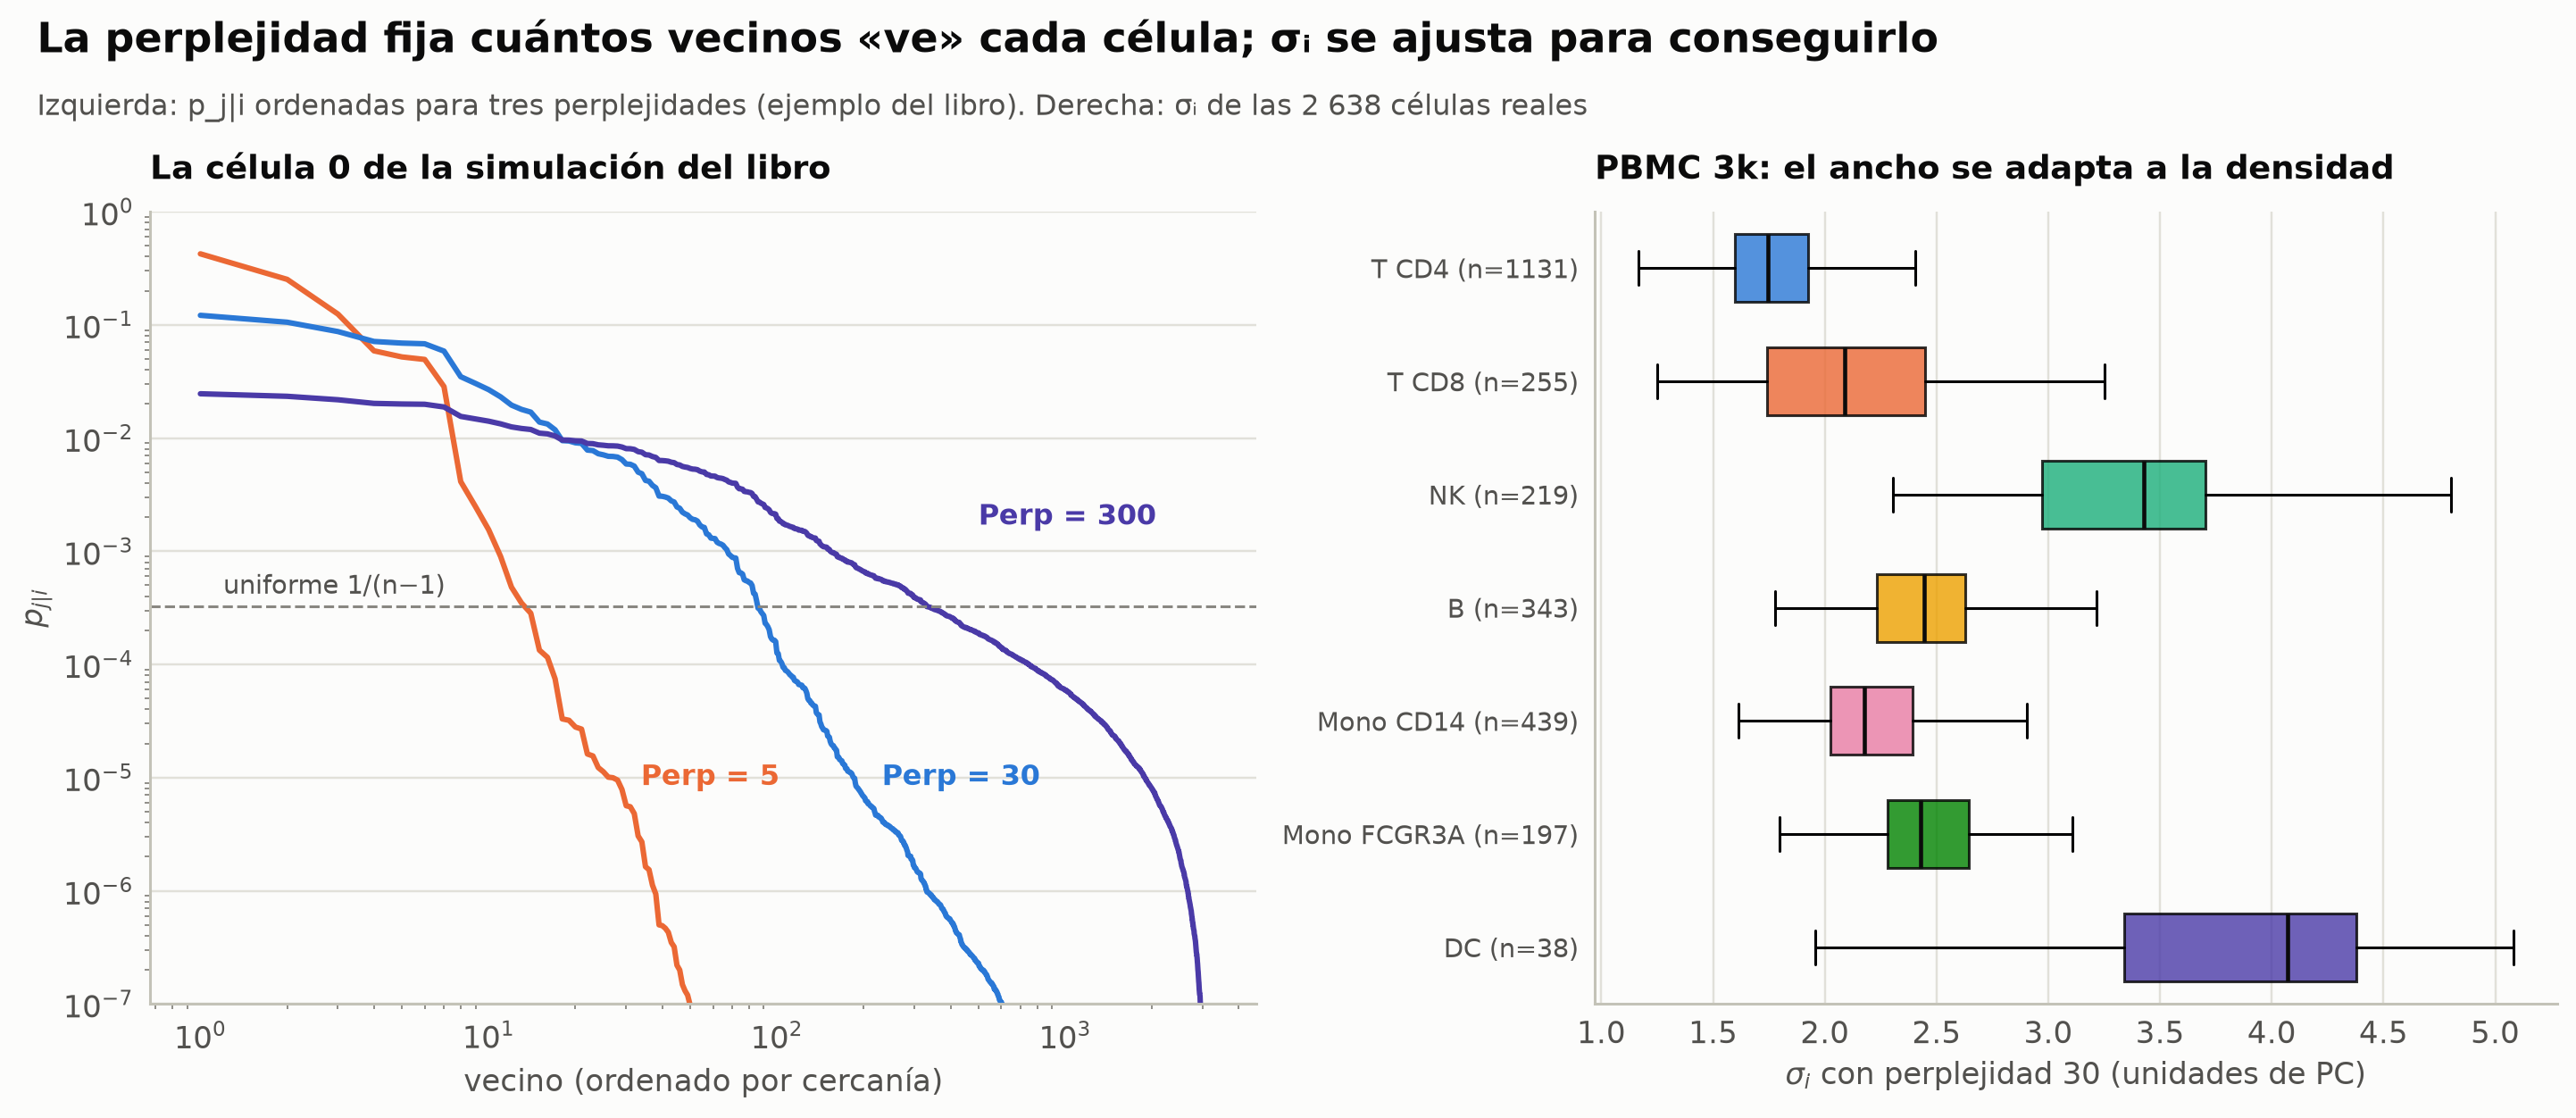

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.9), gridspec_kw=dict(width_ratios=[1.15, 1]))
ax = axs[0]
rank = np.arange(1, len(d2_c0) + 1)
for perp, col in zip((5, 30, 300), (ec.ORANGE, ec.BLUE, ec.VIOLET)):
    ps = np.sort(p_by_perp[perp])[::-1]
    ax.plot(rank, ps, color=col, lw=2)
    xc = rank[np.argmax(ps < 1e-5)]                       # dónde cruza 10⁻⁵: ahí va la etiqueta
    xy_lab = (500, 2e-3) if perp == 300 else (xc * 1.25, 1e-5)
    ax.text(*xy_lab, f"Perp = {perp}", color=col, fontsize=10.5, fontweight="bold", ha="left", va="center")
ax.axhline(1 / len(d2_c0), color=ec.MUTED, ls="--", lw=1)
ax.text(1.2, 1 / len(d2_c0) * 1.3, "uniforme 1/(n−1)", fontsize=9.5, color=ec.INK_2)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_ylim(1e-7, 1)
ax.set_xlabel("vecino (ordenado por cercanía)"); ax.set_ylabel("$p_{j|i}$")
ax.set_title("La célula 0 de la simulación del libro", fontsize=12, loc="left")
# σ_i de TODAS las células reales (PBMC) con perplejidad 30: se adapta a la densidad
def sigmas_all(Xin, perp=30, k=None, iters=60):
    """σ_i de cada célula por bisección vectorizada sobre sus k = 3·Perp vecinos más cercanos."""
    k = k or min(len(Xin) - 1, 3 * perp)
    dist, _ = NearestNeighbors(n_neighbors=k + 1).fit(Xin).kneighbors(Xin)
    d2 = dist[:, 1:] ** 2
    lo, hi = np.full(len(Xin), 1e-3), np.full(len(Xin), 1e3)
    for _ in range(iters):
        s_ = np.sqrt(lo * hi)
        P = np.exp(-(d2 - d2[:, :1]) / (2 * s_[:, None] ** 2)); P /= P.sum(1, keepdims=True)
        H = -(P * np.log2(np.maximum(P, 1e-300))).sum(1)
        too_wide = 2 ** H > perp
        hi = np.where(too_wide, s_, hi); lo = np.where(too_wide, lo, s_)
    return s_, dist[:, 1:]
sig_pbmc, _ = sigmas_all(X30, 30)
ax = axs[1]
typ_order = [t for t in MARKERS if t != "Plaquetas"]
data_ = [sig_pbmc[cell_type == t] for t in typ_order]
bp = ax.boxplot(data_, vert=False, patch_artist=True, widths=0.6, showfliers=False,
                medianprops=dict(color=ec.INK, lw=1.5))
for patch, t in zip(bp["boxes"], typ_order):
    patch.set_facecolor(TYPE_COLORS[t]); patch.set_alpha(0.8)
ax.set_yticks(range(1, len(typ_order) + 1), [f"{t} (n={np.sum(cell_type == t)})" for t in typ_order], fontsize=9.5)
ax.invert_yaxis(); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_xlabel("$\\sigma_i$ con perplejidad 30 (unidades de PC)")
ax.set_title("PBMC 3k: el ancho se adapta a la densidad", fontsize=12, loc="left")
ec.fig_title(fig, "La perplejidad fija cuántos vecinos «ve» cada célula; σᵢ se ajusta para conseguirlo",
             "Izquierda: p_j|i ordenadas para tres perplejidades (ejemplo del libro). Derecha: σᵢ de las 2 638 células reales")
plt.show()

> 🔎 **Qué observamos.** A la izquierda, con perplejidad 5 la probabilidad se concentra en una decena de vecinas y
> cae en picado; con 300 se reparte casi plana entre cientos. A la derecha, en los datos reales, las T CD4 (el tipo
> más abundante y compacto) tienen los $\sigma_i$ más pequeños, y los tipos escasos o dispersos, como las DC o los
> monocitos FCGR3A, los mayores: sus 30 vecinas efectivas están más lejos. Por eso t-SNE **no conserva densidades**:
> iguala a todas las células a «30 vecinas», vivan en un barrio abarrotado o en uno despoblado.

### 3.2 Similitudes en baja dimensión y la cola pesada

En el mapa bidimensional $y_1,\dots,y_n$ las similitudes se miden con una distribución $t$ de Student con un grado de
libertad (Cauchy):

$$
q_{ij}=\frac{\left(1+\lVert y_i-y_j\rVert^2\right)^{-1}}{\sum_{k\neq l}\left(1+\lVert y_k-y_l\rVert^2\right)^{-1}}.
\tag{12-tsne-q}
$$

| Símbolo | Significado |
|---|---|
| $y_i$ | Posición de la célula $i$ en el mapa (2D); son las incógnitas que se optimizan |
| $q_{ij}$ | Similitud entre $i$ y $j$ en el mapa; normalizada sobre **todos** los pares, $\sum_{k\neq l}q_{kl}=1$ |
| $(1+d^2)^{-1}$ | Núcleo de Cauchy: decae como $1/d^2$, mucho más despacio que la gaussiana $e^{-d^2/2}$ |

¿Por qué no otra gaussiana? Por el **problema de hacinamiento** (*crowding*). En 30 dimensiones caben muchísimas más
células a distancia moderada de una dada que en un plano: el «volumen» a distancia $r$ crece como $r^{29}$ en vez de
como $r$. Si forzamos a todas esas vecinas moderadas a caber alrededor de ella en dos dimensiones, se amontonan. La
cola pesada de la $t$ permite colocar a las células moderadamente lejanas **mucho más lejos** en el mapa sin pagar
casi nada, lo que abre espacio y separa los grupos. La figura lo cuantifica.

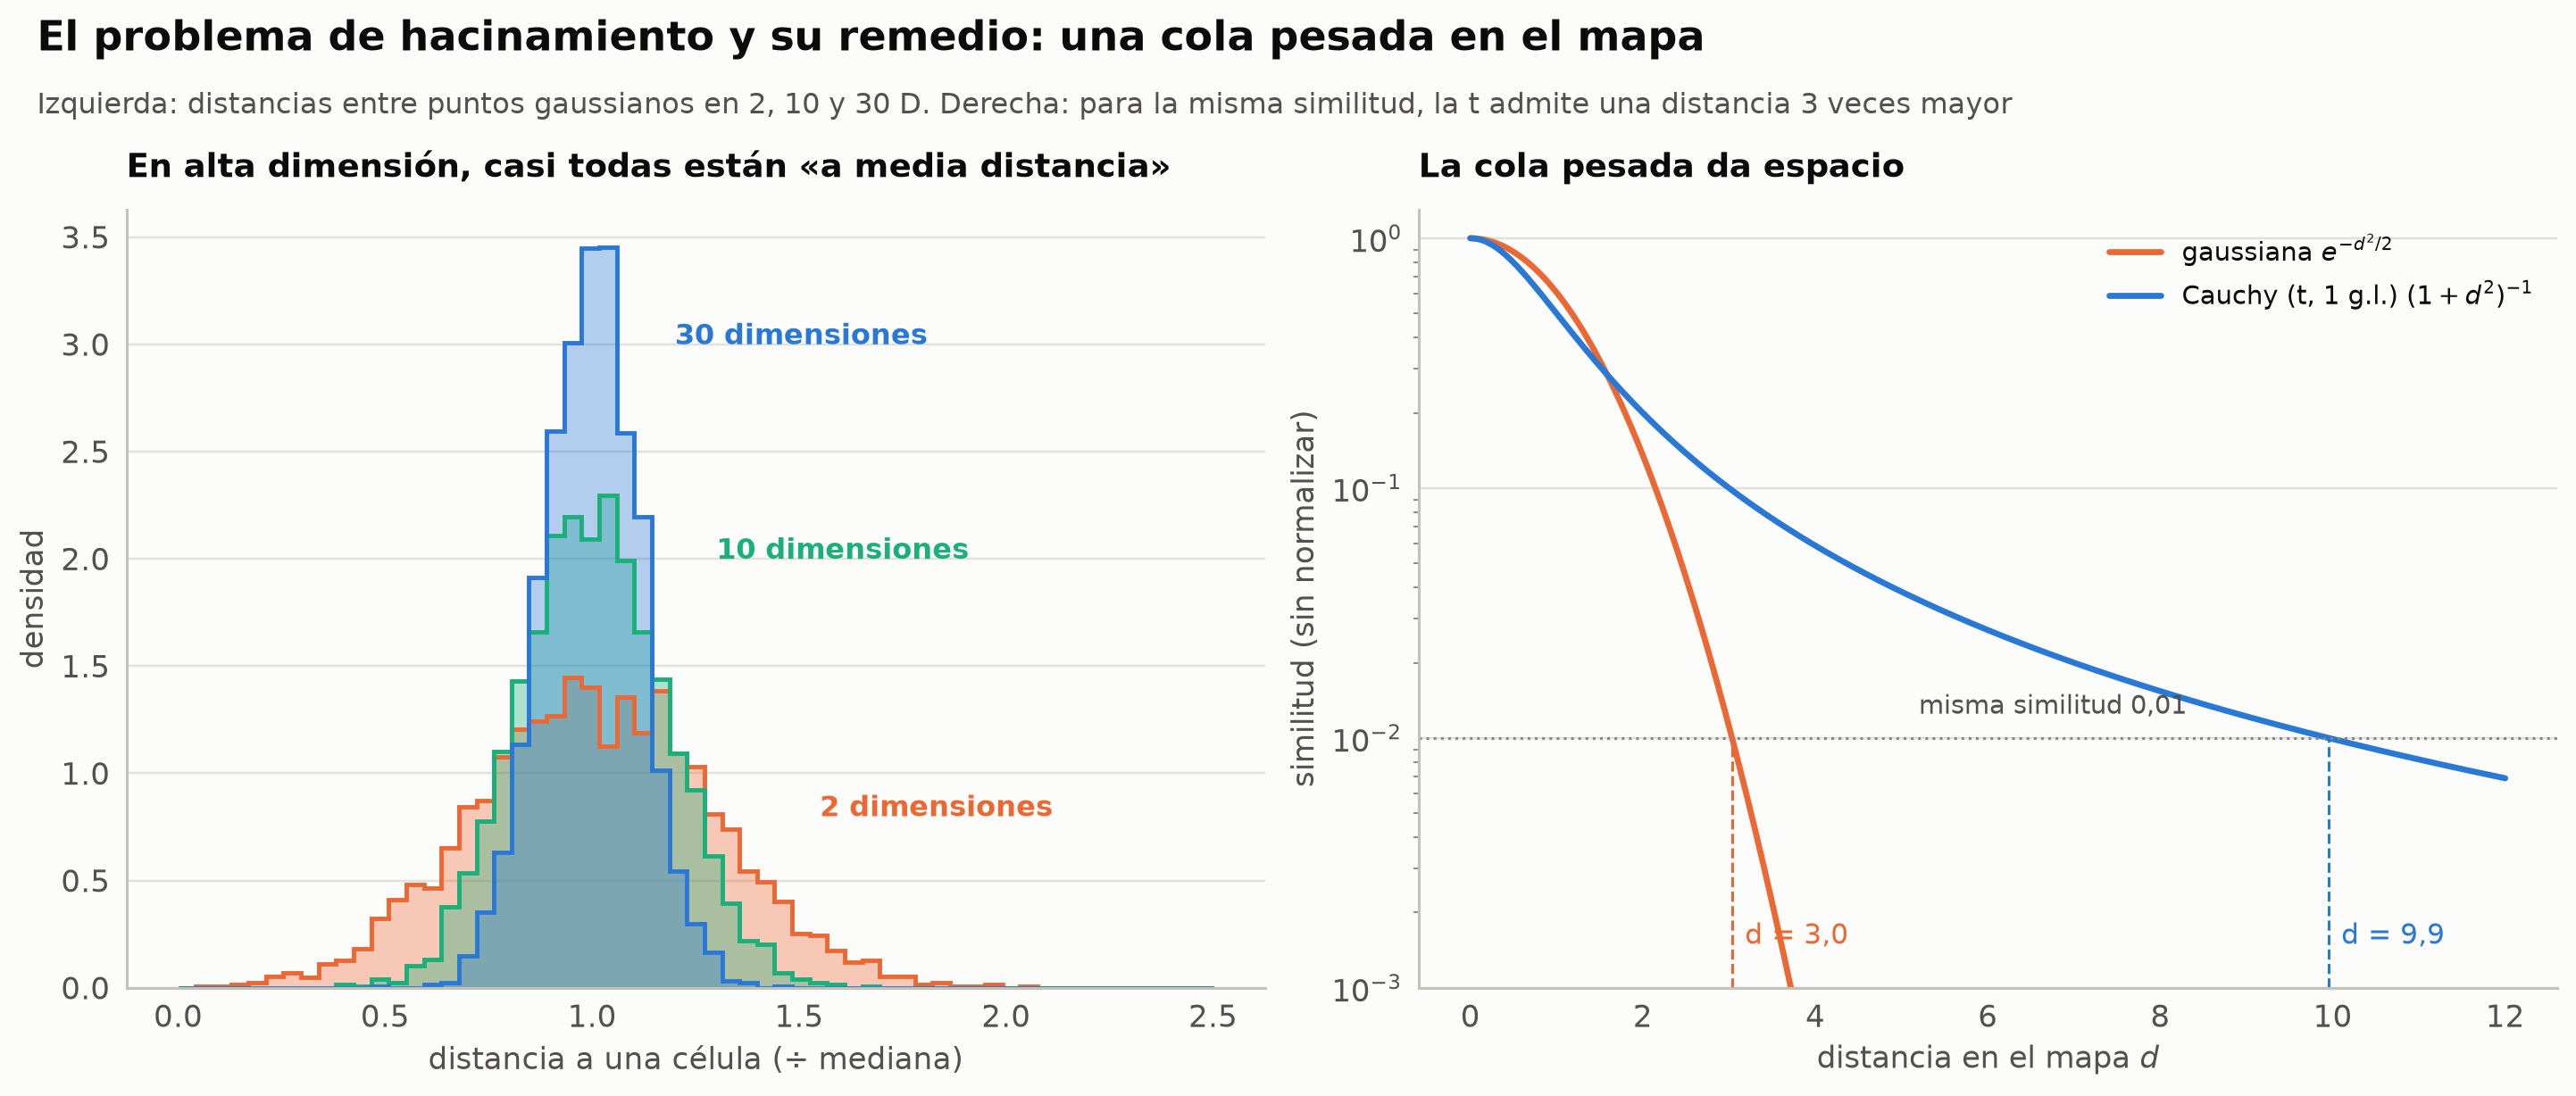

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.8))
rng = np.random.default_rng(3)
ax = axs[0]
for dim, col in zip((2, 10, 30), (ec.ORANGE, ec.AQUA, ec.BLUE)):
    pts = rng.normal(size=(3000, dim))
    dd = np.linalg.norm(pts[1:] - pts[0], axis=1)
    dd /= np.median(dd)
    ax.hist(dd, bins=np.linspace(0, 2.5, 60), density=True, histtype="stepfilled", alpha=0.35, color=col)
    ax.hist(dd, bins=np.linspace(0, 2.5, 60), density=True, histtype="step", lw=1.6, color=col)
    ax.text({2: 1.55, 10: 1.3, 30: 1.2}[dim], {2: 0.8, 10: 2.0, 30: 3.0}[dim], f"{dim} dimensiones", color=col,
            fontsize=10.5, fontweight="bold")
ax.set_xlabel("distancia a una célula (÷ mediana)"); ax.set_ylabel("densidad")
ax.set_title("En alta dimensión, casi todas están «a media distancia»", fontsize=12, loc="left")
ax = axs[1]
dgrid = np.linspace(0, 12, 400)
ax.plot(dgrid, np.exp(-dgrid ** 2 / 2), color=ec.ORANGE, lw=2.2, label="gaussiana $e^{-d^2/2}$")
ax.plot(dgrid, 1 / (1 + dgrid ** 2), color=ec.BLUE, lw=2.2, label="Cauchy (t, 1 g.l.) $(1+d^2)^{-1}$")
ax.set_yscale("log"); ax.set_ylim(1e-3, 1.3)
lvl = 0.01
dg, dc = math.sqrt(-2 * math.log(lvl)), math.sqrt(1 / lvl - 1)
ax.axhline(lvl, color=ec.MUTED, ls=":", lw=1)
for dx, col in ((dg, ec.ORANGE), (dc, ec.BLUE)):
    ax.plot([dx, dx], [1e-3, lvl], color=col, ls="--", lw=1)
    ax.text(dx + 0.15, 1.5e-3, f"d = {dx:.1f}".replace(".", ","), color=col, fontsize=10)
ax.text(5.2, lvl * 1.25, "misma similitud 0,01", fontsize=9.5, color=ec.INK_2)
ax.set_xlabel("distancia en el mapa $d$"); ax.set_ylabel("similitud (sin normalizar)")
ax.legend(loc="upper right", fontsize=9.5)
ax.set_title("La cola pesada da espacio", fontsize=12, loc="left")
ec.fig_title(fig, "El problema de hacinamiento y su remedio: una cola pesada en el mapa",
             "Izquierda: distancias entre puntos gaussianos en 2, 10 y 30 D. Derecha: para la misma similitud, la t admite una distancia 3 veces mayor")
plt.show()

> 🔎 **Qué observamos.** A la izquierda, en 2 dimensiones las distancias se reparten desde casi cero hasta el doble
> de la mediana; en 30 dimensiones se **concentran** alrededor de la mediana: casi todas las células están «a media
> distancia» de todas. Un plano no tiene sitio para tantas vecinas equidistantes. A la derecha, para expresar la
> misma similitud baja (0,01), la gaussiana coloca a la pareja a $d\approx3{,}0$ y la Cauchy a $d\approx9{,}9$: los
> pares moderadamente lejanos pueden alejarse en el mapa, y así se abren huecos entre grupos.

### 3.3 La función de costo y su gradiente

> **Teorema (función de costo y gradiente de t-SNE).** t-SNE minimiza la divergencia de Kullback-Leibler entre las
> similitudes de alta y baja dimensión,
> $$C=\mathrm{KL}(P\,\Vert\,Q)=\sum_{i\neq j}p_{ij}\log\frac{p_{ij}}{q_{ij}}, \tag{12-kl}$$
> cuyo gradiente respecto de la posición de la célula $i$ es
> $$\frac{\partial C}{\partial y_i}=4\sum_{j\neq i}\left(p_{ij}-q_{ij}\right)\left(y_i-y_j\right)\left(1+\lVert y_i-y_j\rVert^2\right)^{-1}. \tag{12-grad}$$

| Símbolo | Significado |
|---|---|
| $P=\{p_{ij}\}$, $Q=\{q_{ij}\}$ | Similitudes simetrizadas en el espacio de PC y en el mapa |
| $C$ | Costo: divergencia KL, $\ge0$ e igual a 0 sólo si $P=Q$ |
| $\partial C/\partial y_i$ | Fuerza neta sobre la célula $i$ (se avanza en sentido contrario) |

La ecuación 12-grad se lee como un **sistema de resortes**: si $p_{ij}>q_{ij}$ (las células son más vecinas en el
espacio original que en el mapa) el término **atrae** a $y_i$ hacia $y_j$; si $p_{ij}<q_{ij}$, las **repele**. La KL
es asimétrica, y esa asimetría es la esencia del método: poner lejos a dos vecinas reales (grande $p$, pequeño $q$)
cuesta mucho; poner cerca a dos células lejanas (pequeño $p$, grande $q$) cuesta poco. t-SNE conserva vecindarios y
deja libres las distancias largas.

**A mano con tres células.** En el mapa, $y_1=(0,0)$, $y_2=(1,0)$, $y_3=(0,2)$. Las distancias al cuadrado son
$d^2_{12}=1$, $d^2_{13}=4$, $d^2_{23}=5$ y los núcleos $(1+d^2)^{-1}$ valen $0{,}5$; $0{,}2$; $0{,}167$. La suma sobre
los **pares ordenados** es $2(0{,}5+0{,}2+0{,}167)=1{,}733$, así que $q_{12}=0{,}288$, $q_{13}=0{,}115$,
$q_{23}=0{,}096$. Supongamos que en el espacio original 1 y 2 son muy vecinas: $p_{12}=0{,}40$ y $p_{13}=p_{23}=0{,}05$.
Entonces

$$
\frac{\partial C}{\partial y_1}=4\Big[\underbrace{(0{,}40-0{,}288)}_{>0:\ \text{atrae}}(-1,0)(0{,}5)
+\underbrace{(0{,}05-0{,}115)}_{<0:\ \text{repele}}(0,-2)(0{,}2)\Big]\approx(-0{,}223;\ +0{,}105).
$$

Como el descenso avanza en contra del gradiente, $y_1$ se mueve hacia $+x$ (hacia su vecina real $y_2$) y hacia $-y$
(lejos de $y_3$, a la que el mapa había puesto demasiado cerca). Verifiquémoslo con código y con **diferencias
finitas**, la prueba de fuego de cualquier gradiente escrito a mano.

In [19]:
def q_matrix(Ymap):
    """Núcleo de Cauchy (1 + d²)⁻¹ y Q normalizada sobre todos los pares ordenados (ecuación 12-tsne-q)."""
    D2 = np.sum((Ymap[:, None] - Ymap[None]) ** 2, axis=2)
    num = 1.0 / (1.0 + D2); np.fill_diagonal(num, 0.0)
    return num, num / num.sum()

def kl_cost(P, Ymap):
    _, Q = q_matrix(Ymap)
    m = P > 0
    return np.sum(P[m] * np.log(P[m] / np.maximum(Q[m], 1e-300)))

def kl_grad(P, Ymap):
    """Gradiente de la ecuación 12-grad: 4 Σ_j (p_ij − q_ij)(y_i − y_j)(1 + ‖y_i − y_j‖²)⁻¹."""
    num, Q = q_matrix(Ymap)
    W = (P - Q) * num
    return 4.0 * (W.sum(1)[:, None] * Ymap - W @ Ymap)

Y3 = np.array([[0.0, 0.0], [1.0, 0.0], [0.0, 2.0]])
P3 = np.array([[0, 0.40, 0.05], [0.40, 0, 0.05], [0.05, 0.05, 0]])
num3, Q3 = q_matrix(Y3)
print("Q =\n", Q3.round(3), f"\nKL(P‖Q) = {kl_cost(P3, Y3):.4f}")
g = kl_grad(P3, Y3)
print("gradiente analítico en y1:", g[0].round(4))
eps = 1e-6; g_num = np.zeros_like(Y3)
for i in range(3):
    for d in range(2):
        Yp, Ym = Y3.copy(), Y3.copy(); Yp[i, d] += eps; Ym[i, d] -= eps
        g_num[i, d] = (kl_cost(P3, Yp) - kl_cost(P3, Ym)) / (2 * eps)
print("gradiente numérico en y1:", g_num[0].round(4), f"| máx. diferencia (3 células) = {np.abs(g - g_num).max():.1e}")

Q =
 [[0.    0.288 0.115]
 [0.288 0.    0.096]
 [0.115 0.096 0.   ]] 
KL(P‖Q) = 0.1125
gradiente analítico en y1: [-0.2231  0.1046]
gradiente numérico en y1: [-0.2231  0.1046] | máx. diferencia (3 células) = 4.6e-11


> 🔎 **Qué observamos.** El gradiente analítico coincide con el numérico hasta la sexta cifra decimal: el factor 4 y
> el núcleo $(1+d^2)^{-1}$ de la ecuación 12-grad son correctos. (El factor 4 sale de dos contribuciones: $y_i$
> aparece en $q_{ij}$ y en $q_{ji}$, y la derivada del núcleo aporta otro 2.)

### 3.4 Un t-SNE escrito desde cero

Con $P$, $Q$ y el gradiente ya tenemos todo. Faltan tres trucos de optimización que usan todas las implementaciones
(y que Kobak y Berens, 2019, recomiendan explícitamente):

1. **Inicialización con PCA**: partir de PC1–PC2 (reescaladas a una desviación típica diminuta, $10^{-4}$) en lugar de
   posiciones aleatorias, para heredar la estructura global.
2. **Exageración temprana**: durante las primeras 250 iteraciones se multiplica $P$ por 12. Las atracciones dominan,
   los grupos se forman rápido como gotas compactas y tienen sitio para moverse unos respecto de otros.
3. **Momento y ganancias adaptativas**: el paso de cada coordenada acumula inercia (momento 0,5 y luego 0,8) y
   aumenta mientras el gradiente no cambie de signo.

Lo aplicamos a **700 células** de PBMC elegidas al azar (el cálculo exacto cuesta $O(n^2)$ por iteración; para miles o
millones de células se usan aproximaciones: Barnes-Hut o la interpolación en rejilla de FIt-SNE, Linderman et al.,
2019).

> 🤔 **Antes de ejecutar, prediga…** Durante la exageración temprana, ¿el mapa estará más contraído o más expandido
> que al final? ¿Y la KL, bajará de forma suave o con un salto cuando se apague la exageración?

In [20]:
def joint_P(Xin, perp=30):
    """P simétrica exacta: p_j|i por bisección para cada célula y p_ij = (p_j|i + p_i|j) / 2n."""
    n = len(Xin)
    D2 = np.sum((Xin[:, None] - Xin[None]) ** 2, axis=2)
    Pc = np.zeros((n, n))
    for i in range(n):
        d2 = np.delete(D2[i], i)
        _, p = sigma_perp(d2, perp, tol=1e-4)
        Pc[i, np.arange(n) != i] = p
    return (Pc + Pc.T) / (2 * n)

def tsne_scratch(Xin, perp=30, n_iter=750, exag=12.0, exag_iters=250, seed=0, record=()):
    """t-SNE exacto: gradiente 12-grad + exageración temprana + momento + ganancias (como van der Maaten, 2008)."""
    n = len(Xin)
    P = joint_P(Xin, perp)
    Y0 = Xin[:, :2] - Xin[:, :2].mean(0)
    Ymap = Y0 / Y0[:, 0].std() * 1e-4                     # inicialización PCA con desviación típica 1e-4
    lr = max(n / exag / 4, 50)                            # tasa de aprendizaje «auto» (Belkina et al., 2019)
    upd = np.zeros_like(Ymap); gains = np.ones_like(Ymap)
    snaps, kls = {}, []
    for it in range(n_iter):
        ex = exag if it < exag_iters else 1.0
        grad = kl_grad(ex * P, Ymap)
        mom = 0.5 if it < exag_iters else 0.8
        same = np.sign(grad) == np.sign(upd)
        gains = np.clip(np.where(same, gains * 0.8, gains + 0.2), 0.01, None)
        upd = mom * upd - lr * gains * grad
        Ymap = Ymap + upd
        Ymap -= Ymap.mean(0)
        if it in record or it == n_iter - 1:
            snaps[it] = Ymap.copy(); kls.append((it, kl_cost(P, Ymap)))
    return Ymap, P, snaps, np.array(kls)

t0 = time.time()
rng = np.random.default_rng(1)
sub = np.sort(rng.choice(adata.n_obs, 700, replace=False))
X_sub = X30[sub]
REC = sorted(set(np.r_[0, np.round(np.geomspace(1, 749, 60)).astype(int)]))
Y_scr, P_sub, snaps, kl_curve = tsne_scratch(X_sub, 30, record=REC)
print(f"{len(sub)} células · {len(REC)} instantáneas · KL final = {kl_curve[-1, 1]:.3f} · ⏱️ {time.time() - t0:.1f} s")

from sklearn.manifold import TSNE
tsk = TSNE(perplexity=30, init="pca", random_state=0, method="exact").fit(X_sub)
print(f"scikit-learn (método exacto) sobre las mismas células: KL = {tsk.kl_divergence_:.3f}")

700 células · 49 instantáneas · KL final = 1.093 · ⏱️ 6.6 s


scikit-learn (método exacto) sobre las mismas células: KL = 1.107


![t-SNE desde cero sobre 700 células de PBMC 3k: con la exageración temprana (sombreado) los tipos se condensan en gotas; al apagarla el mapa se expande y la KL baja hasta estabilizarse](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-12-celula-unica/12.2_tsne_descenso.gif)

*t-SNE desde cero sobre 700 células de PBMC 3k: con la exageración temprana (sombreado) los tipos se condensan en gotas; al apagarla el mapa se expande y la KL baja hasta estabilizarse*

In [21]:
its = sorted(snaps)
sub_types = cell_type[sub]
sub_cols = np.array([TYPE_COLORS[t] for t in sub_types])
fig = plt.figure(figsize=(12.5, 5.8))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.86))
g2 = fig.add_gridspec(1, 2, width_ratios=[1.1, 1])
axm = fig.add_subplot(g2[0]); axk = fig.add_subplot(g2[1])
sc_ = axm.scatter(snaps[its[0]][:, 0], snaps[its[0]][:, 1], s=9, c=sub_cols, lw=0)
axm.set_xticks([]); axm.set_yticks([]); axm.grid(False); axm.set_aspect("equal")
for t in MARKERS:
    axm.scatter([], [], s=25, color=TYPE_COLORS[t], label=t)
axm.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), fontsize=8.5, handletextpad=0.1, borderaxespad=0)
itxt = axm.text(0.02, 0.97, "", transform=axm.transAxes, fontsize=11, fontweight="bold", color=ec.INK, va="top")
stxt = axm.text(0.02, 0.02, "", transform=axm.transAxes, fontsize=9.5, color=ec.INK_2)
axk.axvspan(0, 250, color=ec.YELLOW, alpha=0.12, lw=0)
axk.text(125, 0.97, "exageración ×12", transform=axk.get_xaxis_transform(), ha="center", va="top",
         fontsize=9.5, color=ec.INK_2)
axk.plot(kl_curve[:, 0], kl_curve[:, 1], color=ec.BASELINE, lw=1.5)
pt, = axk.plot([], [], "o", color=ec.BLUE, ms=8)
tr, = axk.plot([], [], color=ec.BLUE, lw=2.2)
axk.set_xlim(-10, 760); axk.set_ylim(0, kl_curve[:, 1].max() * 1.12)
axk.set_xlabel("iteración"); axk.set_ylabel("KL(P ‖ Q)")
fig.text(0.01, 0.985, "El descenso de gradiente ordena las células: primero gotas, después un mapa", fontsize=15,
         fontweight="bold", color=ec.INK, va="top")
fig.text(0.01, 0.935, "t-SNE escrito desde cero (perplejidad 30, inicialización PCA) sobre 700 células de PBMC 3k; "
         "colores: tipos provisionales", fontsize=10.5, color=ec.INK_2, va="top")

def update(f):
    it = its[f]; Ym = snaps[it]
    sc_.set_offsets(Ym)
    lo_, hi_ = np.percentile(Ym, 0.5, axis=0), np.percentile(Ym, 99.5, axis=0)
    c, r_ = (lo_ + hi_) / 2, (hi_ - lo_).max() / 2 * 1.15
    axm.set_xlim(c[0] - r_, c[0] + r_); axm.set_ylim(c[1] - r_, c[1] + r_)
    itxt.set_text(f"iteración {it}")
    stxt.set_text(f"ancho del mapa ≈ {2 * r_:.2g} unidades")
    m = kl_curve[:, 0] <= it
    pt.set_data([it], [kl_curve[m, 1][-1]]); tr.set_data(kl_curve[m, 0], kl_curve[m, 1])
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(its), interval=150, name="12.2_tsne_descenso")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Al principio todas las células están apiñadas en un punto (desviación típica $10^{-4}$) y
> ordenadas como en el plano PC1–PC2. Durante la exageración, las atracciones multiplicadas por 12 condensan cada tipo
> en una gota y el mapa sigue siendo pequeño; la KL (calculada con la $P$ verdadera) baja rápido. Al apagar la
> exageración en la iteración 250, las repulsiones toman el control: el mapa se **expande** varias veces y la KL da un
> último descenso antes de estabilizarse. Las T CD4 y CD8, superpuestas en el PCA, se separan; las NK quedan junto a
> las T CD8 (comparten el programa citotóxico). Nuestro valor final de KL es comparable al de scikit-learn con el
> mismo algoritmo exacto: las pequeñas diferencias vienen de detalles como la tasa de aprendizaje.

### 3.5 t-SNE en producción: Scanpy y openTSNE sobre las 2 638 células

Para el conjunto completo usamos implementaciones aproximadas. `sc.tl.tsne` de Scanpy llama a scikit-learn
(Barnes-Hut); **openTSNE** (Poličar et al., 2024) implementa FIt-SNE y los consejos de Kobak y Berens. Si openTSNE no
está instalado (no viene en Colab), el notebook lo instala; si falla, simplemente se omite.

In [22]:
t0 = time.time()
adata.obsm["X_pca"] = pcs.astype(np.float32)          # nuestras PC (con el convenio de signo de pca_svd)
sc.tl.tsne(adata, n_pcs=30, perplexity=30, random_state=0)
emb_tsne = adata.obsm["X_tsne"].copy()
print(f"Scanpy/scikit-learn t-SNE: ⏱️ {time.time() - t0:.1f} s")

emb_otsne = None
try:
    try:
        import openTSNE
    except ImportError:
        if IN_COLAB:
            %pip install -q openTSNE
        import openTSNE
    t0 = time.time()
    emb_otsne = np.asarray(openTSNE.TSNE(perplexity=30, initialization="pca", random_state=0,
                                         n_jobs=2).fit(X30))
    print(f"openTSNE (FIt-SNE): ⏱️ {time.time() - t0:.1f} s")
except Exception as err:
    print("openTSNE no disponible; se omite la comparación:", err)

Scanpy/scikit-learn t-SNE: ⏱️ 5.1 s


openTSNE (FIt-SNE): ⏱️ 6.6 s


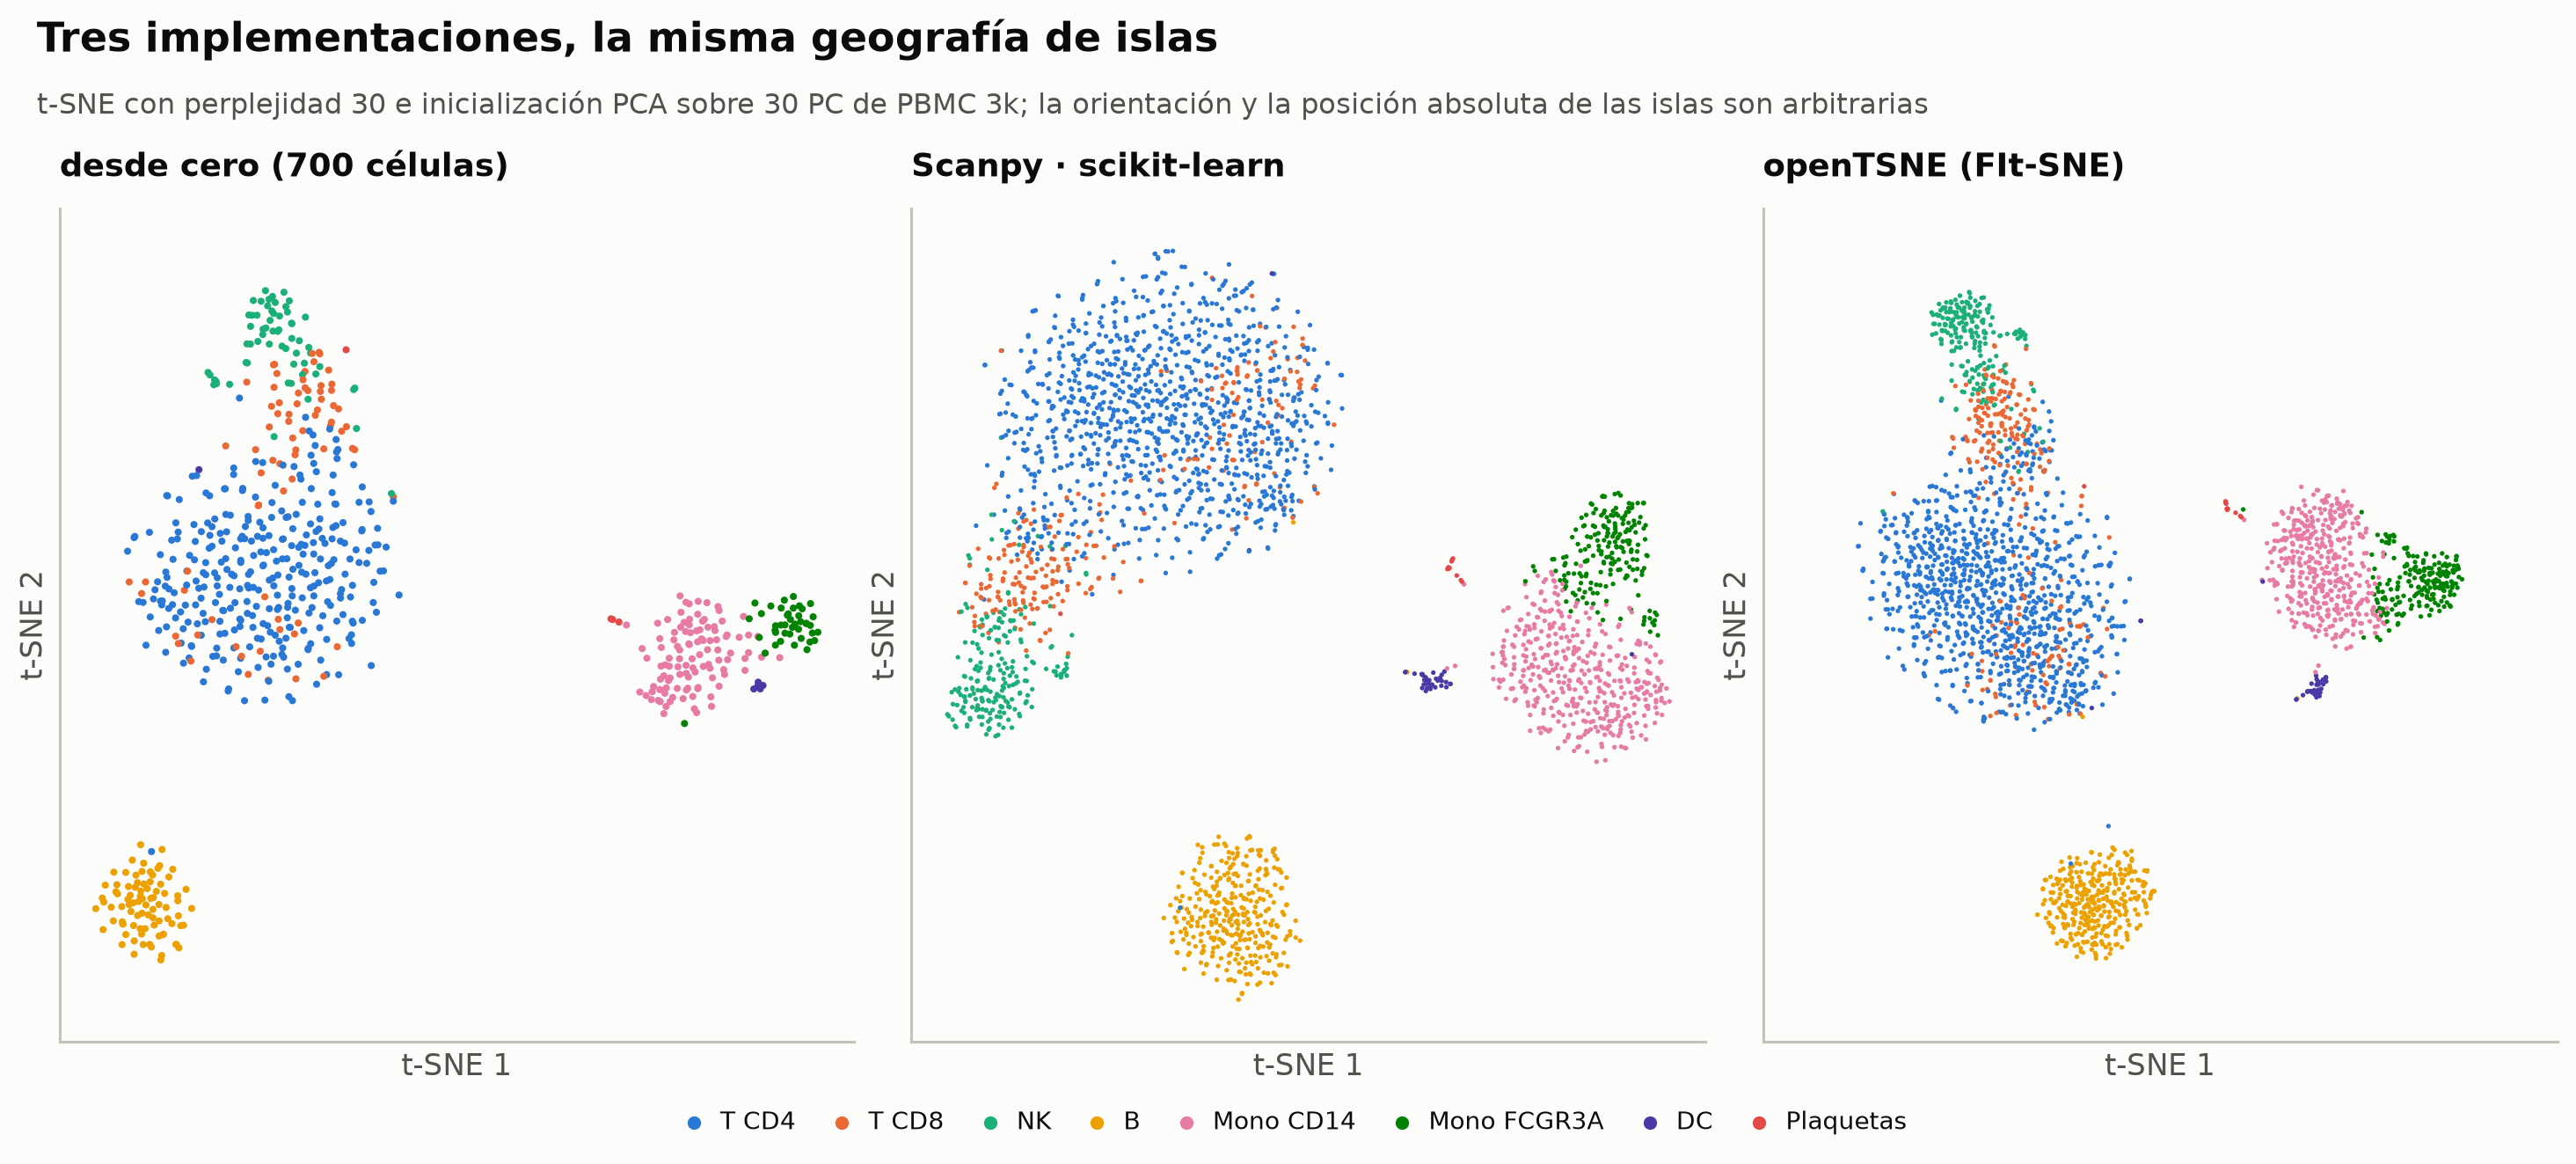

In [23]:
panels = [("desde cero (700 células)", Y_scr, sub_types), ("Scanpy · scikit-learn", emb_tsne, cell_type)]
if emb_otsne is not None:
    panels.append(("openTSNE (FIt-SNE)", emb_otsne, cell_type))
fig, axs = plt.subplots(1, len(panels), figsize=(4.4 * len(panels), 4.9))
for ax, (name, E, ty) in zip(axs, panels):
    o = np.random.default_rng(0).permutation(len(E))
    ax.scatter(E[o, 0], E[o, 1], s=3 if len(E) > 1000 else 7, c=[TYPE_COLORS[t] for t in ty[o]], lw=0)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False); ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(name, fontsize=12, loc="left")
    ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
for t in MARKERS:
    axs[-1].scatter([], [], s=25, color=TYPE_COLORS[t], label=t)
fig.legend(*axs[-1].get_legend_handles_labels(), loc="lower center", ncol=8, fontsize=9, bbox_to_anchor=(0.5, -0.07),
           handletextpad=0.1, columnspacing=0.9)
ec.fig_title(fig, "Tres implementaciones, la misma geografía de islas",
             "t-SNE con perplejidad 30 e inicialización PCA sobre 30 PC de PBMC 3k; la orientación y la posición absoluta de las islas son arbitrarias")
plt.show()

> 🔎 **Qué observamos.** Las tres versiones separan los mismos tipos en islas: B, monocitos CD14 junto a FCGR3A y DC,
> NK pegadas a T CD8, y una gran masa de T CD4. La orientación cambia (un mapa t-SNE puede rotarse o reflejarse sin
> alterar la KL), pero las **vecindades** se conservan. Nuestro t-SNE de 700 células es, en esencia, lo mismo que
> hacen las bibliotecas; ellas sólo aceleran el cálculo de las repulsiones.

### 3.6 La perplejidad cambia la imagen

Con perplejidad baja, cada célula sólo atiende a un puñado de vecinas y los grupos se fragmentan en **subgrupos
espurios**; con perplejidad alta, el mapa conserva mejor la **estructura global**, pero los tipos cercanos
(monocitos CD14 y FCGR3A; linfocitos T CD4 y CD8) tienden a fundirse. Kobak y Berens (2019) recomiendan inicializar con
PCA (para heredar la estructura global), usar una perplejidad del orden de $n/100$ en conjuntos grandes o combinar
varias escalas, y aumentar la exageración de las atracciones al inicio.

La fila superior reproduce la figura del libro (simulación, perplejidades 5, 30 y 300, calculadas por el generador
del libro con la misma semilla); la inferior, lo mismo con las células reales.

> 🤔 **Antes de ejecutar, prediga…** Con perplejidad 300 cada célula de PBMC «ve» a más del 10 % del conjunto. ¿Qué
> le pasará a la pequeña isla de plaquetas (16 células)?

⏱️ t-SNE con perplejidades 5 y 300: 14.9 s


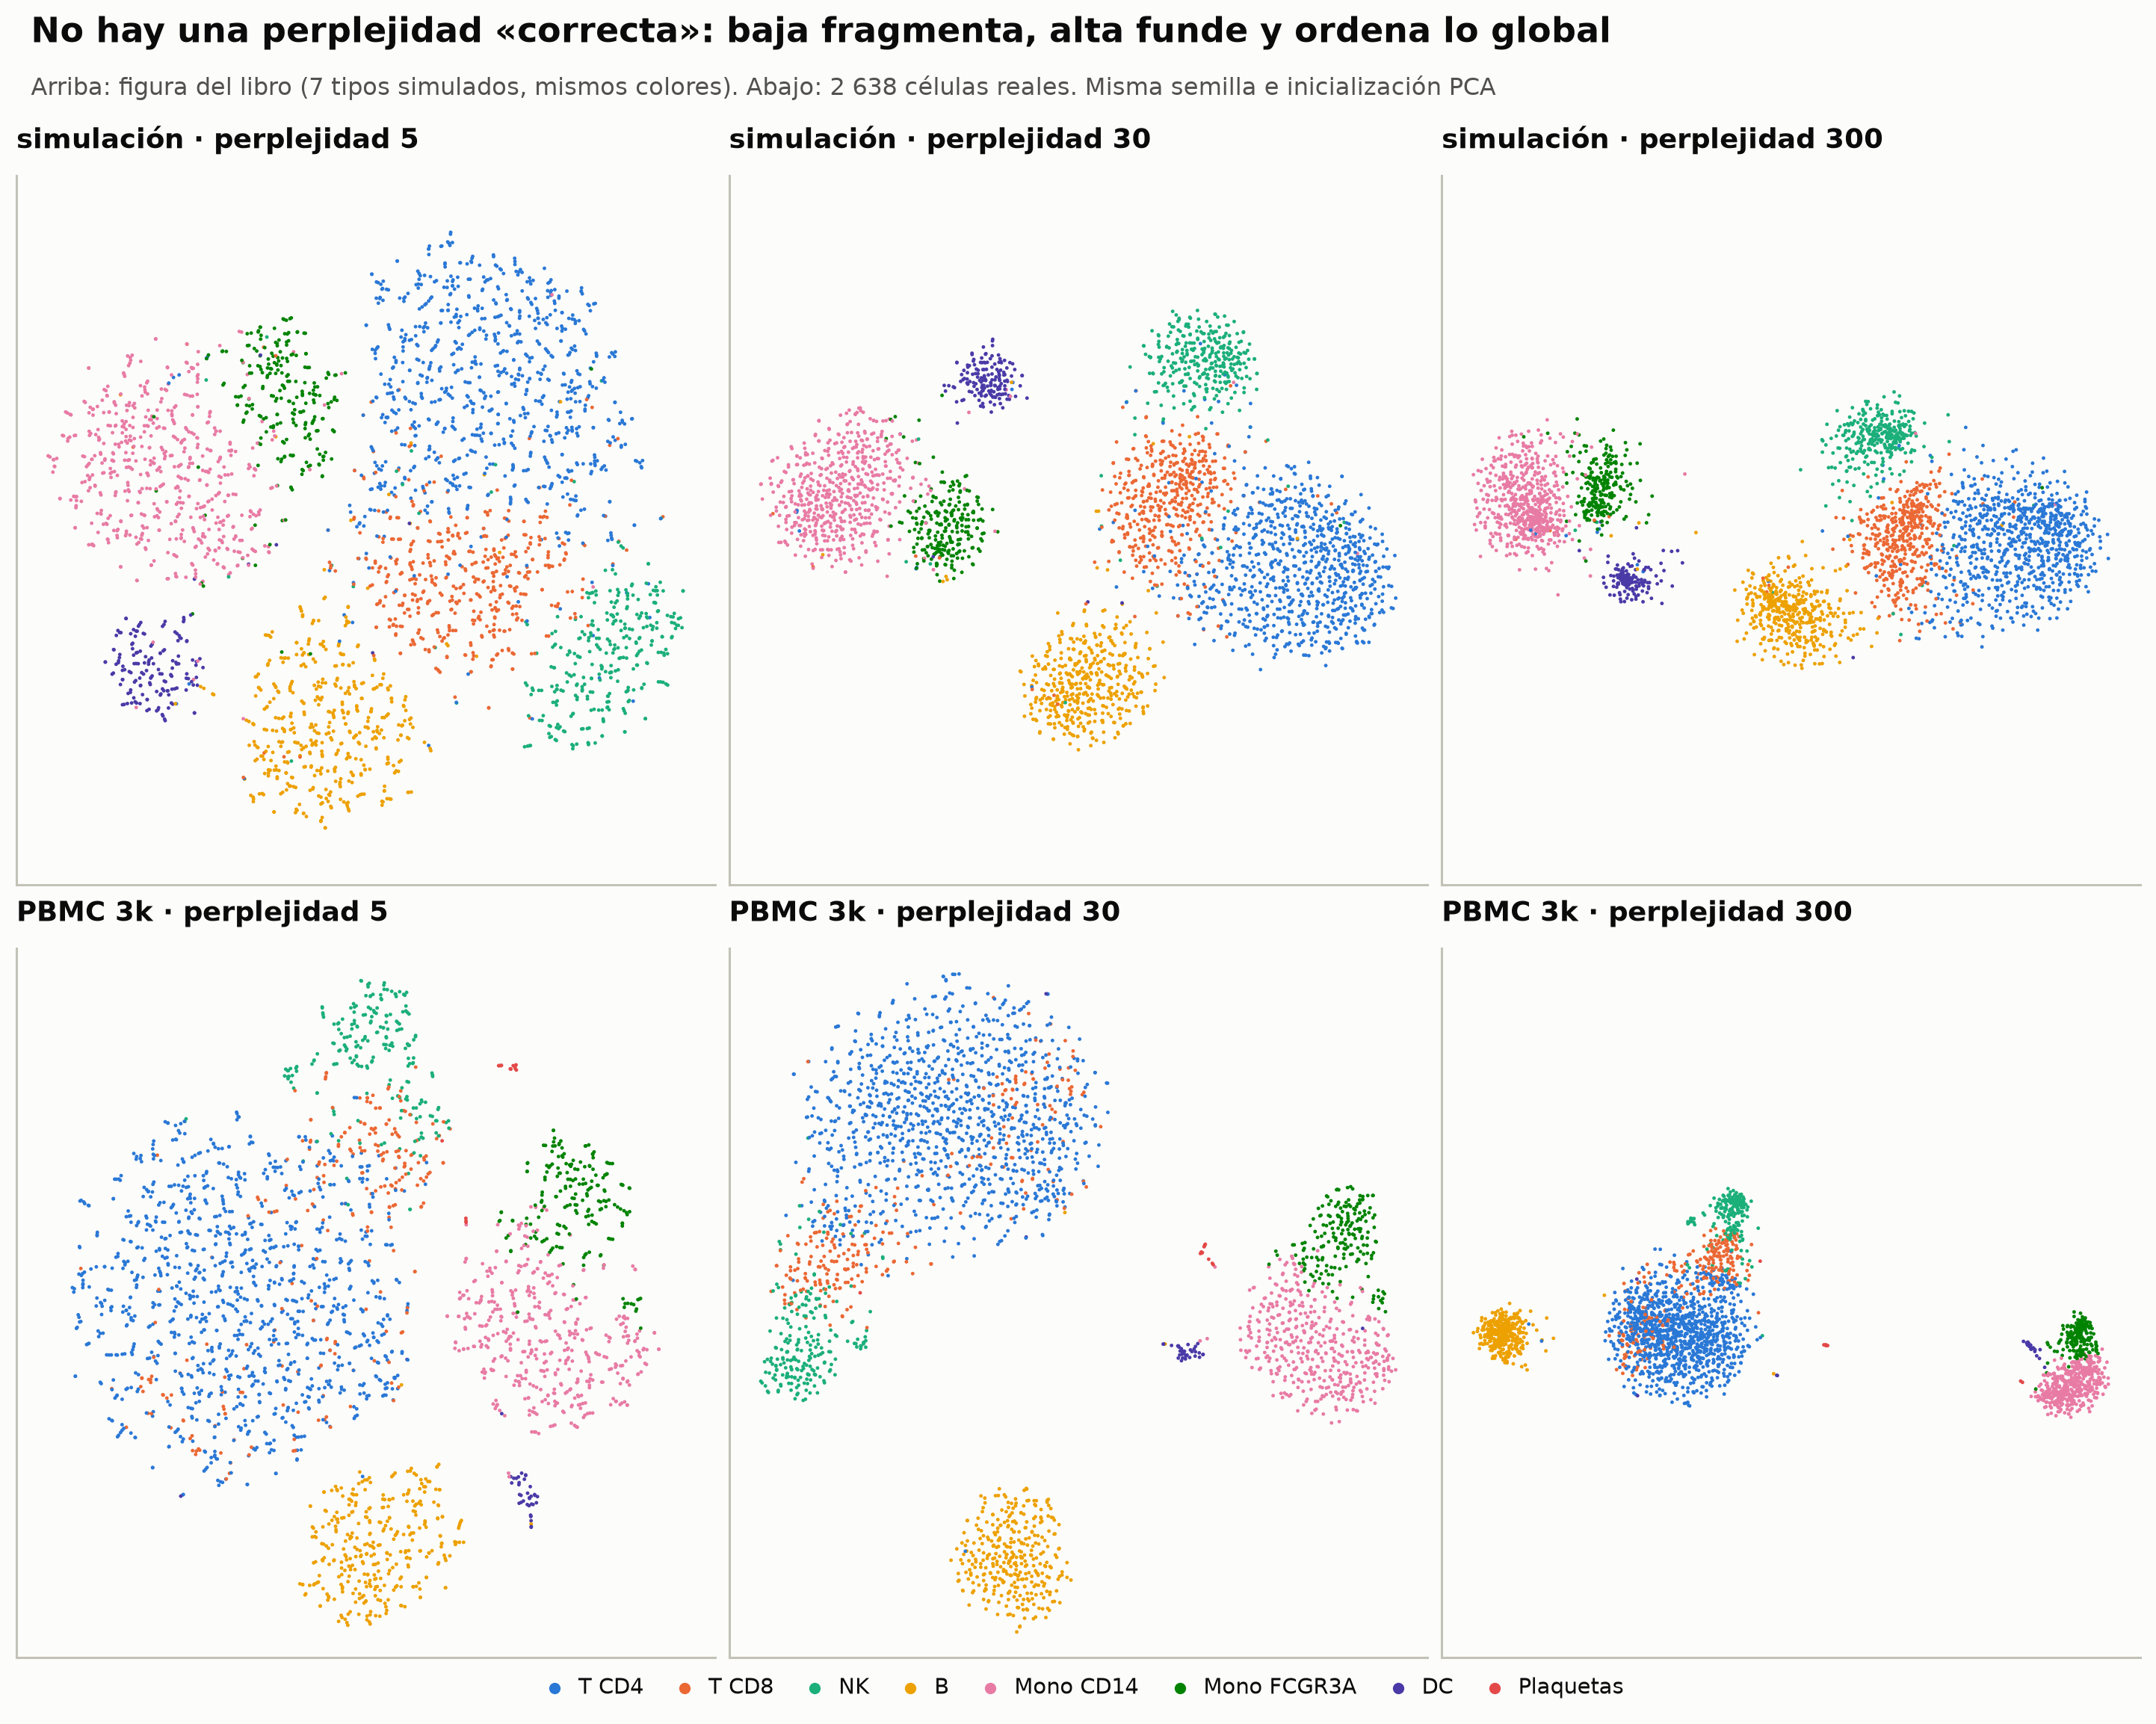

In [24]:
t0 = time.time()
emb_perp = {30: emb_tsne}
for perp in (5, 300):
    emb_perp[perp] = TSNE(perplexity=perp, init="pca", random_state=0).fit_transform(X30)
print(f"⏱️ t-SNE con perplejidades 5 y 300: {time.time() - t0:.1f} s")
sim_perp = {5: sim["tsne5"], 30: sim["tsne"], 300: sim["tsne300"]}

def panel_types(ax, E, labels, colors, s=2.5):
    o = np.random.default_rng(0).permutation(len(E))
    ax.scatter(E[o, 0], E[o, 1], s=s, c=colors[o], lw=0)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False); ax.set_aspect("equal", adjustable="datalim")

fig, axs = plt.subplots(2, 3, figsize=(13, 9.4))
sim_cols = np.array([ec.CATEGORICAL[t] for t in T_sim])
real_cols = np.array([TYPE_COLORS[t] for t in cell_type])
for j, perp in enumerate((5, 30, 300)):
    panel_types(axs[0, j], sim_perp[perp], T_sim, sim_cols)
    axs[0, j].set_title(f"simulación · perplejidad {perp}", fontsize=12, loc="left")
    panel_types(axs[1, j], emb_perp[perp], cell_type, real_cols)
    axs[1, j].set_title(f"PBMC 3k · perplejidad {perp}", fontsize=12, loc="left")
for t in MARKERS:
    axs[1, 2].scatter([], [], s=25, color=TYPE_COLORS[t], label=t)
fig.legend(*axs[1, 2].get_legend_handles_labels(), loc="lower center", ncol=8, fontsize=9.5,
           bbox_to_anchor=(0.5, -0.035), handletextpad=0.1, columnspacing=0.9)
ec.fig_title(fig, "No hay una perplejidad «correcta»: baja fragmenta, alta funde y ordena lo global",
             "Arriba: figura del libro (7 tipos simulados, mismos colores). Abajo: 2 638 células reales. Misma semilla e inicialización PCA")
plt.show()

> 🔎 **Qué observamos.** Con perplejidad 5 las islas se ven **granuladas**: cada célula sólo ve a unas pocas vecinas
> y aparecen agrupamientos locales sin significado biológico (en la simulación sabemos que dentro de cada tipo no hay
> subtipos, ¡y aun así aparecen grumos!). El valor por defecto, 30, da islas limpias. Con 300 la disposición global
> es más ordenada (el eje mieloide–linfoide se ve como en el PCA), pero los tipos emparentados se acercan y las islas
> pequeñas se pegan a las grandes. Conviene mirar **varias** perplejidades antes de creer en una estructura.

> ✅ **Compruebe su comprensión.** Un colega le muestra un t-SNE con perplejidad 5 de 50 000 células y señala tres
> «subpoblaciones nuevas» de linfocitos T. ¿Qué dos comprobaciones le pediría? *(Respuesta: repetir con perplejidades
> mayores, del orden de $n/100=500$ o combinando escalas, y verificar en el espacio de PC o con genes marcadores
> diferenciales que esos grupos existen; un grumo que sólo aparece con perplejidad baja suele ser un artefacto.)*

## 4. UMAP: un grafo difuso

UMAP (*uniform manifold approximation and projection*) parte de la teoría de conjuntos difusos y la topología
algebraica, pero su algoritmo se parece mucho a t-SNE (McInnes et al., 2018). Tiene dos etapas: primero construye un
**grafo de $k$ vecinos más cercanos** con pesos entre 0 y 1; después busca coordenadas 2D cuyo grafo se parezca a ése.

### 4.1 Los pesos del grafo

$$
v_{j\mid i}=\exp\!\left(-\frac{d(x_i,x_j)-\rho_i}{\sigma_i}\right),\qquad \sum_{j=1}^{k} v_{j\mid i}=\log_2 k,
\qquad
v_{ij}=v_{j\mid i}+v_{i\mid j}-v_{j\mid i}\,v_{i\mid j}.
\tag{12-umap-v}
$$

| Símbolo | Significado |
|---|---|
| $d(x_i,x_j)$ | Distancia (euclídea en 30 PC) entre las células $i$ y $j$; sólo para los $k$ vecinos de $i$ |
| $\rho_i$ | Distancia de $i$ a su vecino más cercano: garantiza que toda célula tenga al menos un vecino con peso 1 |
| $\sigma_i$ | Escala local, elegida para que la suma de pesos sea $\log_2 k$ (el papel de la perplejidad) |
| $v_{j\mid i}$ | Peso dirigido de la arista $i\to j$ |
| $v_{ij}$ | Peso simétrico: probabilidad de que exista **al menos una** de las dos aristas dirigidas (unión difusa) |
| $k$ | Número de vecinos (`n_neighbors`); controla el equilibrio entre estructura local y global |

Tres diferencias con t-SNE saltan a la vista: sólo se miran los $k$ vecinos (el resto tiene peso 0, lo que hace el
cálculo muy barato), el núcleo es exponencial en la distancia **menos $\rho_i$** (la vecina más cercana siempre pesa
1, aunque la célula viva aislada) y la simetrización es una **unión probabilística** en lugar de una media.

**A mano.** Una célula con $k=4$ vecinas a distancias $0{,}5;\ 0{,}8;\ 1{,}0;\ 1{,}6$. Entonces $\rho=0{,}5$ y la
primera vecina pesa $e^0=1$. Buscamos $\sigma$ tal que $1+e^{-0{,}3/\sigma}+e^{-0{,}5/\sigma}+e^{-1{,}1/\sigma}=\log_2
4=2$, o sea que las otras tres sumen 1. Probando: con $\sigma=0{,}4$ suman $0{,}472+0{,}287+0{,}064=0{,}82$ (poco); con
$\sigma=0{,}5$, $0{,}549+0{,}368+0{,}111=1{,}03$ (algo de más). La bisección da $\sigma\approx0{,}49$. Para la unión
difusa, si $v_{j\mid i}=0{,}8$ y $v_{i\mid j}=0{,}3$: $v_{ij}=0{,}8+0{,}3-0{,}24=0{,}86$, la probabilidad de que al
menos uno de los dos «crea» en la arista.

In [25]:
def umap_sigma(dists, target, iters=64):
    """ρ y σ de UMAP para una célula: dists = distancias a sus vecinos (sin ella misma), ordenadas."""
    rho = dists[0]
    lo, hi = 0.0, np.inf; mid = 1.0
    for _ in range(iters):
        s_ = np.sum(np.exp(-np.maximum(dists - rho, 0) / mid))
        if abs(s_ - target) < 1e-5:
            break
        if s_ > target:
            hi = mid; mid = (lo + hi) / 2
        else:
            lo = mid; mid = mid * 2 if hi == np.inf else (lo + hi) / 2
    return rho, mid

d_toy = np.array([0.5, 0.8, 1.0, 1.6])
rho_t, sig_t = umap_sigma(d_toy, np.log2(4))
v_toy = np.exp(-(d_toy - rho_t) / sig_t)
print(f"ρ = {rho_t}, σ = {sig_t:.4f}; pesos v_j|i = {v_toy.round(3)} (suma = {v_toy.sum():.4f} = log2 4)")
print("unión difusa de 0,8 y 0,3:", 0.8 + 0.3 - 0.8 * 0.3)

ρ = 0.5, σ = 0.4856; pesos v_j|i = [1.    0.539 0.357 0.104] (suma = 2.0000 = log2 4)
unión difusa de 0,8 y 0,3: 0.8600000000000001


Ahora el grafo completo de PBMC con $k=15$ y la comparación con umap-learn. Un detalle de implementación que conviene
conocer: umap-learn cuenta a la **propia célula** como uno de sus `n_neighbors` vecinos (distancia 0), así que con
`n_neighbors=15` cada célula tiene 14 vecinas reales, y la suma de sus pesos se ajusta a $\log_2 15$. La ecuación del
libro, $\sum_{j=1}^{k}$, se lee con el mismo convenio si $k$ incluye a la célula misma.

In [26]:
import umap
from umap.umap_ import fuzzy_simplicial_set, find_ab_params
t0 = time.time()
K = 15
knn_d, knn_i = NearestNeighbors(n_neighbors=K).fit(X30).kneighbors(X30)     # incluye a la propia célula
knn_d[:, 0] = 0.0          # la distancia a sí misma debe ser 0 exacto (el redondeo deja ~1e-7 y umap-learn la
                           # tomaría por una vecina real, con ρ_i ≈ 0)
rows, cols_, vals = [], [], []
rhos, sigs = np.zeros(len(X30)), np.zeros(len(X30))
for i in range(len(X30)):
    d_i = knn_d[i, 1:]                                   # 14 vecinas reales
    rhos[i], sigs[i] = umap_sigma(d_i, np.log2(K))
    rows += [i] * (K - 1); cols_ += list(knn_i[i, 1:]); vals += list(np.exp(-np.maximum(d_i - rhos[i], 0) / sigs[i]))
Vdir = sparse.csr_matrix((vals, (rows, cols_)), shape=(len(X30), len(X30)))
V_ours = Vdir + Vdir.T - Vdir.multiply(Vdir.T)           # unión difusa
G_umap, sig_umap, rho_umap = fuzzy_simplicial_set(X30, n_neighbors=K, random_state=np.random.RandomState(0),
                                                  metric="euclidean", knn_indices=knn_i,
                                                  knn_dists=knn_d.astype(np.float32))[:3]
diff = abs(V_ours - G_umap)
print(f"Aristas: nuestras = {V_ours.nnz:,} · umap-learn = {G_umap.nnz:,}")
print(f"máx |ρ − ρ_umap| = {np.abs(rhos - rho_umap).max():.1e} · correlación σ = "
      f"{np.corrcoef(sigs, sig_umap)[0, 1]:.4f} · máx |v_ij − v_ij(umap)| = {diff.max():.1e}")
asym = Vdir.multiply(Vdir.T > 0).nnz / Vdir.nnz
print(f"Aristas dirigidas correspondidas (j es vecina de i e i de j): {asym:.1%}")
print(f"⏱️ {time.time() - t0:.1f} s")

Aristas: nuestras = 61,460 · umap-learn = 61,460
máx |ρ − ρ_umap| = 9.1e-07 · correlación σ = 1.0000 · máx |v_ij − v_ij(umap)| = 3.8e-06
Aristas dirigidas correspondidas (j es vecina de i e i de j): 33.6%
⏱️ 1.9 s


> 🔎 **Qué observamos.** Nuestro grafo reproduce el de umap-learn: los $\rho_i$ coinciden exactamente y los pesos
> difieren sólo en redondeos (umap-learn trabaja en precisión simple y fija un mínimo para $\sigma_i$). Sólo una parte
> de las aristas es recíproca: la relación «ser una de mis 14 vecinas» no es simétrica (una célula en el borde de un
> grupo puede tener como vecinas a células del centro sin que ellas la elijan). La unión difusa resuelve esa
> asimetría sin descartar información.

### 4.2 El mapa: `min_dist` y los parámetros $a$ y $b$

UMAP busca coordenadas $y_i$ cuyas similitudes $w_{ij}=\left(1+a\lVert y_i-y_j\rVert^{2b}\right)^{-1}$ se parezcan a
$v_{ij}$. Con $a=b=1$ sería exactamente el núcleo de Cauchy de t-SNE. Los parámetros $a$ y $b$ se ajustan a partir de
`min_dist`, que fija lo **compactos** que se permite que queden los grupos: $w$ se aproxima a una curva que vale 1
hasta `min_dist` y luego decae exponencialmente.

| Símbolo | Significado |
|---|---|
| $w_{ij}$ | Similitud en el mapa entre $i$ y $j$ (no se normaliza globalmente) |
| $a$, $b$ | Forma del núcleo; se obtienen ajustando una curva por mínimos cuadrados a partir de `min_dist` |
| `min_dist` | Distancia mínima «efectiva» entre puntos del mapa; pequeña → grupos apretados |

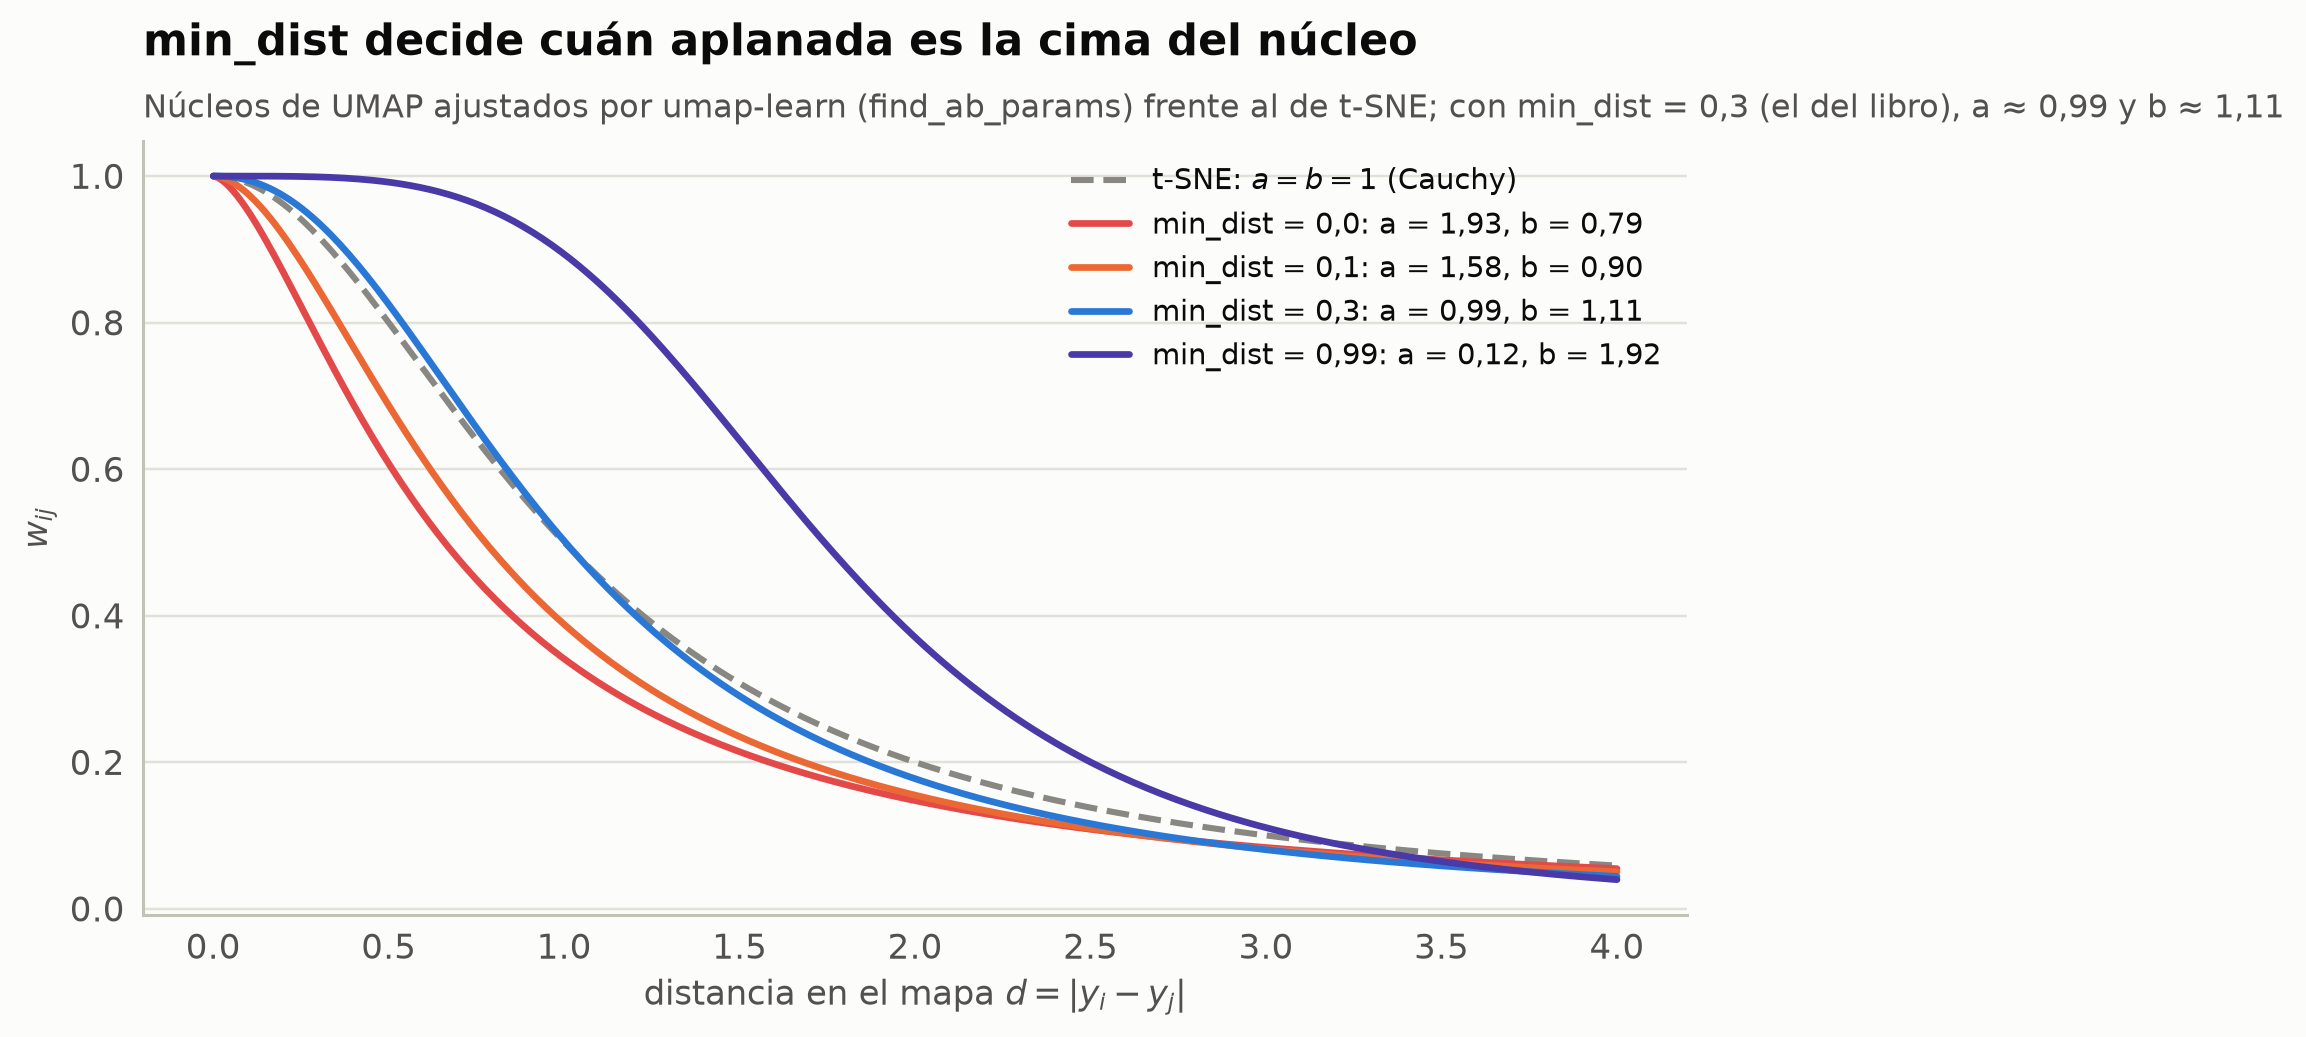

In [27]:
fig, ax = plt.subplots(figsize=(10, 4.6))
dd = np.linspace(0, 4, 300)
ax.plot(dd, 1 / (1 + dd ** 2), color=ec.MUTED, lw=2, ls="--", label="t-SNE: $a=b=1$ (Cauchy)")
ab_rows = []
for md, col in zip((0.0, 0.1, 0.3, 0.99), (ec.RED, ec.ORANGE, ec.BLUE, ec.VIOLET)):
    a_, b_ = find_ab_params(1.0, md)
    ab_rows.append((md, a_, b_))
    ax.plot(dd, 1 / (1 + a_ * dd ** (2 * b_)), color=col, lw=2.2,
            label=f"min_dist = {md}: a = {a_:.2f}, b = {b_:.2f}".replace(".", ","))
ax.set_xlabel("distancia en el mapa $d = |y_i - y_j|$"); ax.set_ylabel("$w_{ij}$")
ax.legend(loc="upper right", fontsize=9.5)
ec.title(ax, "min_dist decide cuán aplanada es la cima del núcleo",
         "Núcleos de UMAP ajustados por umap-learn (find_ab_params) frente al de t-SNE; con min_dist = 0,3 (el del libro), a ≈ 0,99 y b ≈ 1,11")
plt.show()

> 🔎 **Qué observamos.** Con `min_dist` = 0 el núcleo cae en picado desde cero: dos células casi idénticas pueden
> quedar pegadas (grupos muy densos). Con 0,99 la cima es plana hasta casi 1: los puntos se reparten y los grupos se
> ven esponjosos. El valor por defecto de Scanpy, 0,5, y el del libro, 0,3, quedan en medio.

### 4.3 La función de costo: entropía cruzada

$$
\mathrm{CE}=\sum_{i\neq j}\left[v_{ij}\log\frac{v_{ij}}{w_{ij}}+\left(1-v_{ij}\right)\log\frac{1-v_{ij}}{1-w_{ij}}\right].
\tag{12-umap-ce}
$$

| Término | Qué penaliza |
|---|---|
| $v_{ij}\log(v_{ij}/w_{ij})$ | **Atracción**: vecinas en el grafo ($v$ grande) puestas lejos en el mapa ($w$ pequeño); es el término de t-SNE |
| $(1-v_{ij})\log\frac{1-v_{ij}}{1-w_{ij}}$ | **Repulsión**: no vecinas ($v\approx0$) puestas cerca ($w\approx1$); ausente en la KL |

El segundo término penaliza **explícitamente** colocar cerca a células que no son vecinas. Un número lo aclara: para un
par sin arista ($v_{ij}=0$) que el mapa coloca a una distancia con $w_{ij}=0{,}9$, el costo es
$-\log(1-0{,}9)=2{,}30$; si lo separa hasta $w_{ij}=0{,}1$, baja a $0{,}105$. Como las similitudes **no se normalizan
globalmente**, la optimización se hace por descenso de gradiente estocástico muestreando aristas (y unas pocas «no
aristas» al azar para la repulsión), lo que la hace muy rápida. Becht et al. (2019) mostraron en datos de citometría y
de célula única que UMAP es más rápido que las implementaciones de t-SNE de entonces y que organiza mejor la
continuidad entre poblaciones emparentadas. Conviene matizarlo: t-SNE con inicialización PCA y perplejidades grandes
también conserva buena parte de la estructura global (Kobak y Berens, 2019).

### 4.4 UMAP de PBMC 3k

En Scanpy, UMAP se calcula en dos pasos: `sc.pp.neighbors` (el grafo, sección 4.1) y `sc.tl.umap` (la optimización).
Explore el resultado en la figura interactiva: el menú cambia el gen con que se colorean las células. Los genes
marcadores confirman (o desmienten) las etiquetas provisionales.

> 🤔 **Antes de ejecutar, prediga…** Si colorea por *CD3E* (todas las células T), ¿qué islas se encenderán? ¿Y si
> colorea por el porcentaje de UMI mitocondriales?

In [28]:
t0 = time.time()
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30, use_rep="X_pca", random_state=0)
sc.tl.umap(adata, min_dist=0.3, random_state=0)
emb_umap = adata.obsm["X_umap"].copy()
print(f"sc.pp.neighbors + sc.tl.umap: ⏱️ {time.time() - t0:.1f} s")

sc.pp.neighbors + sc.tl.umap: ⏱️ 2.6 s


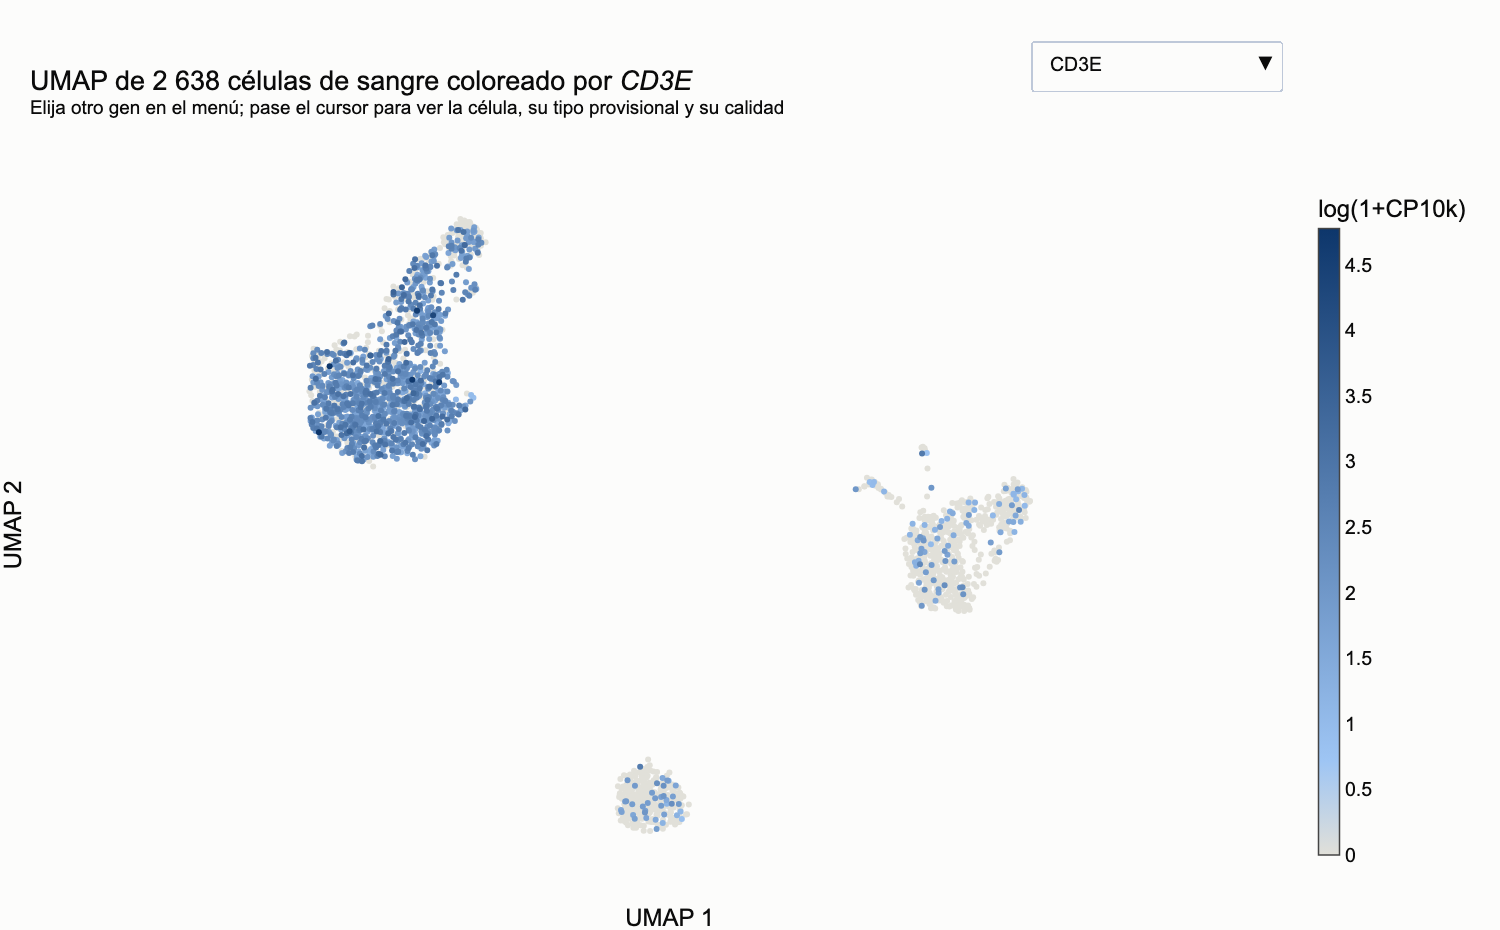

In [29]:
GENES_SHOW = ["CD3E", "CD8A", "MS4A1", "LYZ", "FCGR3A", "NKG7", "FCER1A", "PPBP"]
color_vals = {g: expr(g) for g in GENES_SHOW}
color_vals["% UMI mitocondriales"] = adata.obs.pct_counts_mt.values
color_vals["UMI totales"] = adata.obs.total_counts.values
first = GENES_SHOW[0]
hover = ("<b>%{customdata[0]}</b><br>tipo provisional: %{customdata[1]}<br>"
         "valor mostrado: %{marker.color:.2f}<br>UMI totales: %{customdata[2]} · % mt: %{customdata[3]:.1f}"
         "<extra></extra>")
cd = np.column_stack([adata.obs_names, cell_type, adata.obs.total_counts.astype(int), adata.obs.pct_counts_mt])
order_c = np.argsort(color_vals[first])                    # las células que expresan se dibujan encima
fig = go.Figure(go.Scatter(
    x=emb_umap[order_c, 0], y=emb_umap[order_c, 1], mode="markers", customdata=cd[order_c],
    marker=dict(size=4, color=color_vals[first][order_c], colorscale=[[0, "#e1e0d9"], [0.15, "#9ec5f4"],
                                                                     [1, "#0d366b"]],
                colorbar=dict(title="log(1+CP10k)", thickness=14)),
    hovertemplate=hover))
buttons = []
for name, vals_ in color_vals.items():
    o = np.argsort(vals_)
    buttons.append(dict(label=name, method="update",
                        args=[{"x": [emb_umap[o, 0]], "y": [emb_umap[o, 1]], "customdata": [cd[o]],
                               "marker.color": [vals_[o]],
                               "marker.colorbar.title.text": "log(1+CP10k)" if name in GENES_SHOW else name},
                              {"title.text": f"UMAP de 2 638 células de sangre coloreado por <i>{name}</i>"
                                             "<br><sup>Elija otro gen en el menú; pase el cursor para ver la célula,"
                                             " su tipo provisional y su calidad</sup>"}]))
fig.update_layout(
    title=f"UMAP de 2 638 células de sangre coloreado por <i>{first}</i><br><sup>Elija otro gen en el menú; pase el"
          " cursor para ver la célula, su tipo provisional y su calidad</sup>",
    updatemenus=[dict(buttons=buttons, direction="down", x=1.0, xanchor="right", y=1.13, yanchor="bottom")],
    height=620, margin=dict(l=40, r=20, t=120, b=40),
    xaxis=dict(title="UMAP 1", showticklabels=False), yaxis=dict(title="UMAP 2", showticklabels=False,
                                                                 scaleanchor="x", showgrid=False))
fig.show()

> 🔎 **Qué observamos.** *CD3E* enciende la gran región de linfocitos T (CD4 y CD8 juntas); *CD8A* sólo una parte de
> ella, pegada a las NK (*NKG7*); *MS4A1* marca la isla B; *LYZ* todo el territorio mieloide; *FCGR3A* los monocitos no
> clásicos (y, más débil, las NK); *FCER1A* un grupito de DC; *PPBP* la minúscula isla de plaquetas. El porcentaje
> mitocondrial, en cambio, no dibuja ninguna isla propia: el QC fue efectivo. Si un «tipo celular nuevo» se encendiera
> con el % mitocondrial o con UMI totales bajos, lo más probable es que fuese un grupo de células de mala calidad.

### 4.5 `n_neighbors` y `min_dist` cambian la imagen

Igual que la perplejidad en t-SNE, $k$ (`n_neighbors`) fija la escala: pocos vecinos → detalles locales y
fragmentos; muchos → estructura global. `min_dist` sólo cambia lo apretados que quedan los puntos.

5 UMAP con umap-learn: ⏱️ 18.0 s


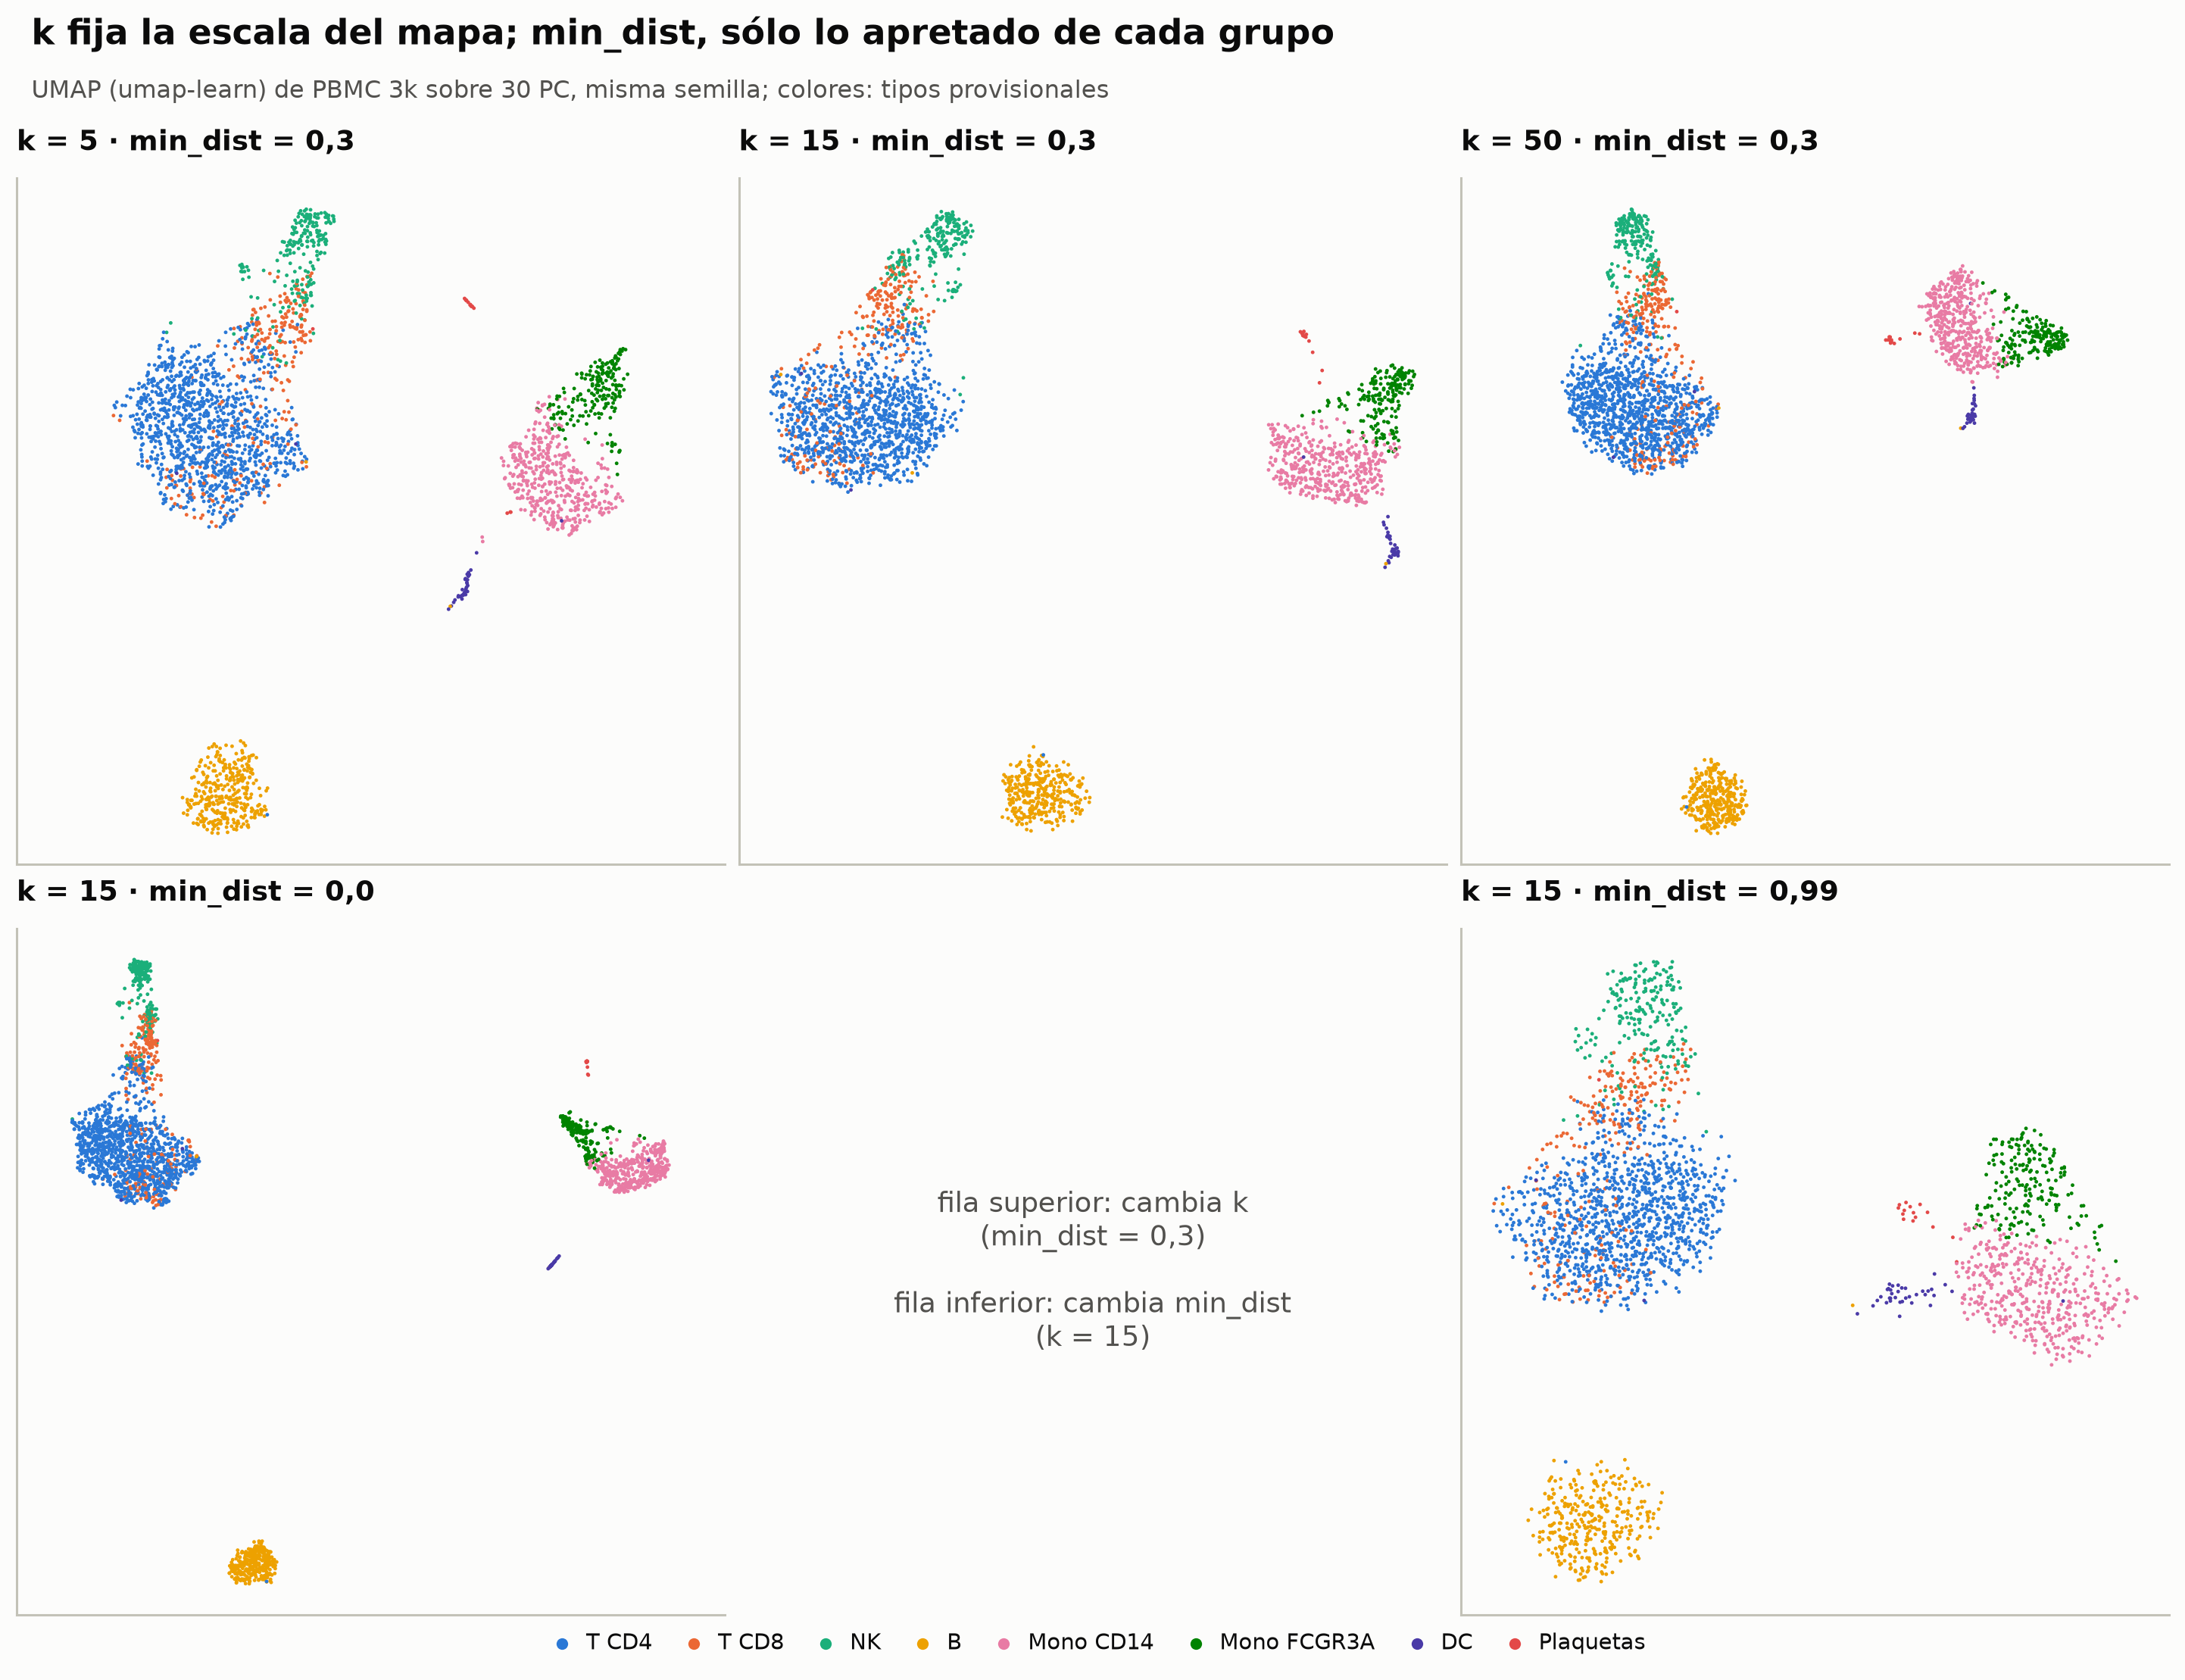

In [30]:
t0 = time.time()
umap_runs = {}
for k_, md in [(5, 0.3), (15, 0.3), (50, 0.3), (15, 0.0), (15, 0.99)]:
    umap_runs[(k_, md)] = umap.UMAP(n_neighbors=k_, min_dist=md, random_state=0, n_epochs=200).fit_transform(X30)
print(f"5 UMAP con umap-learn: ⏱️ {time.time() - t0:.1f} s")
fig, axs = plt.subplots(2, 3, figsize=(13, 9))
layout_ = [[(5, 0.3), (15, 0.3), (50, 0.3)], [(15, 0.0), None, (15, 0.99)]]
for r_i in range(2):
    for c_i in range(3):
        ax = axs[r_i, c_i]; key = layout_[r_i][c_i]
        if key is None:
            ax.axis("off")
            ax.text(0.5, 0.5, "fila superior: cambia k\n(min_dist = 0,3)\n\nfila inferior: cambia min_dist\n(k = 15)",
                    ha="center", va="center", fontsize=12, color=ec.INK_2, transform=ax.transAxes)
            continue
        panel_types(ax, umap_runs[key], cell_type, real_cols)
        ax.set_title(f"k = {key[0]} · min_dist = {key[1]}".replace(".", ","), fontsize=12, loc="left")
for t in MARKERS:
    axs[1, 2].scatter([], [], s=25, color=TYPE_COLORS[t], label=t)
fig.legend(*axs[1, 2].get_legend_handles_labels(), loc="lower center", ncol=8, fontsize=9.5,
           bbox_to_anchor=(0.5, -0.035), handletextpad=0.1, columnspacing=0.9)
ec.fig_title(fig, "k fija la escala del mapa; min_dist, sólo lo apretado de cada grupo",
             "UMAP (umap-learn) de PBMC 3k sobre 30 PC, misma semilla; colores: tipos provisionales")
plt.show()

> 🔎 **Qué observamos.** Con $k=5$ los grupos se deshilachan: aparecen colas y pequeños satélites (algunas NK
> sueltas, las DC y las plaquetas como filamentos aislados) porque cada célula sólo conoce a cuatro vecinas y el grafo
> tiende a romperse en componentes. Con $k=50$ los grupos emparentados se
> acercan y el conjunto se ordena en los grandes linajes (mieloide, B, T/NK). Con `min_dist` = 0 los grupos se
> contraen en manchas densas, útiles para ver fronteras; con 0,99 se hinchan hasta casi tocarse. **Ninguno** de estos
> cambios altera los datos: sólo la forma de dibujarlos.

> ✅ **Compruebe su comprensión.** En Scanpy, usted cambia `n_neighbors` de 15 a 50 en `sc.pp.neighbors` para que el
> UMAP «se vea mejor». ¿Qué más ha cambiado sin querer? *(Respuesta: el grafo de vecinos también lo usan Leiden y
> PAGA: al cambiar $k$ cambian los clusters de la lección 12.3 y las trayectorias de la 12.4. Si sólo quiere otro
> dibujo, calcule un grafo aparte con `key_added` o use umap-learn directamente.)*

## 5. Lo que un *embedding* no dice

Un mapa bidimensional es una herramienta de **exploración**, no una **medida**. Primero, la figura del libro con los
tres métodos sobre la simulación: las mismas 30 PC, coloreadas por el tipo celular simulado (que ningún método
conoce).

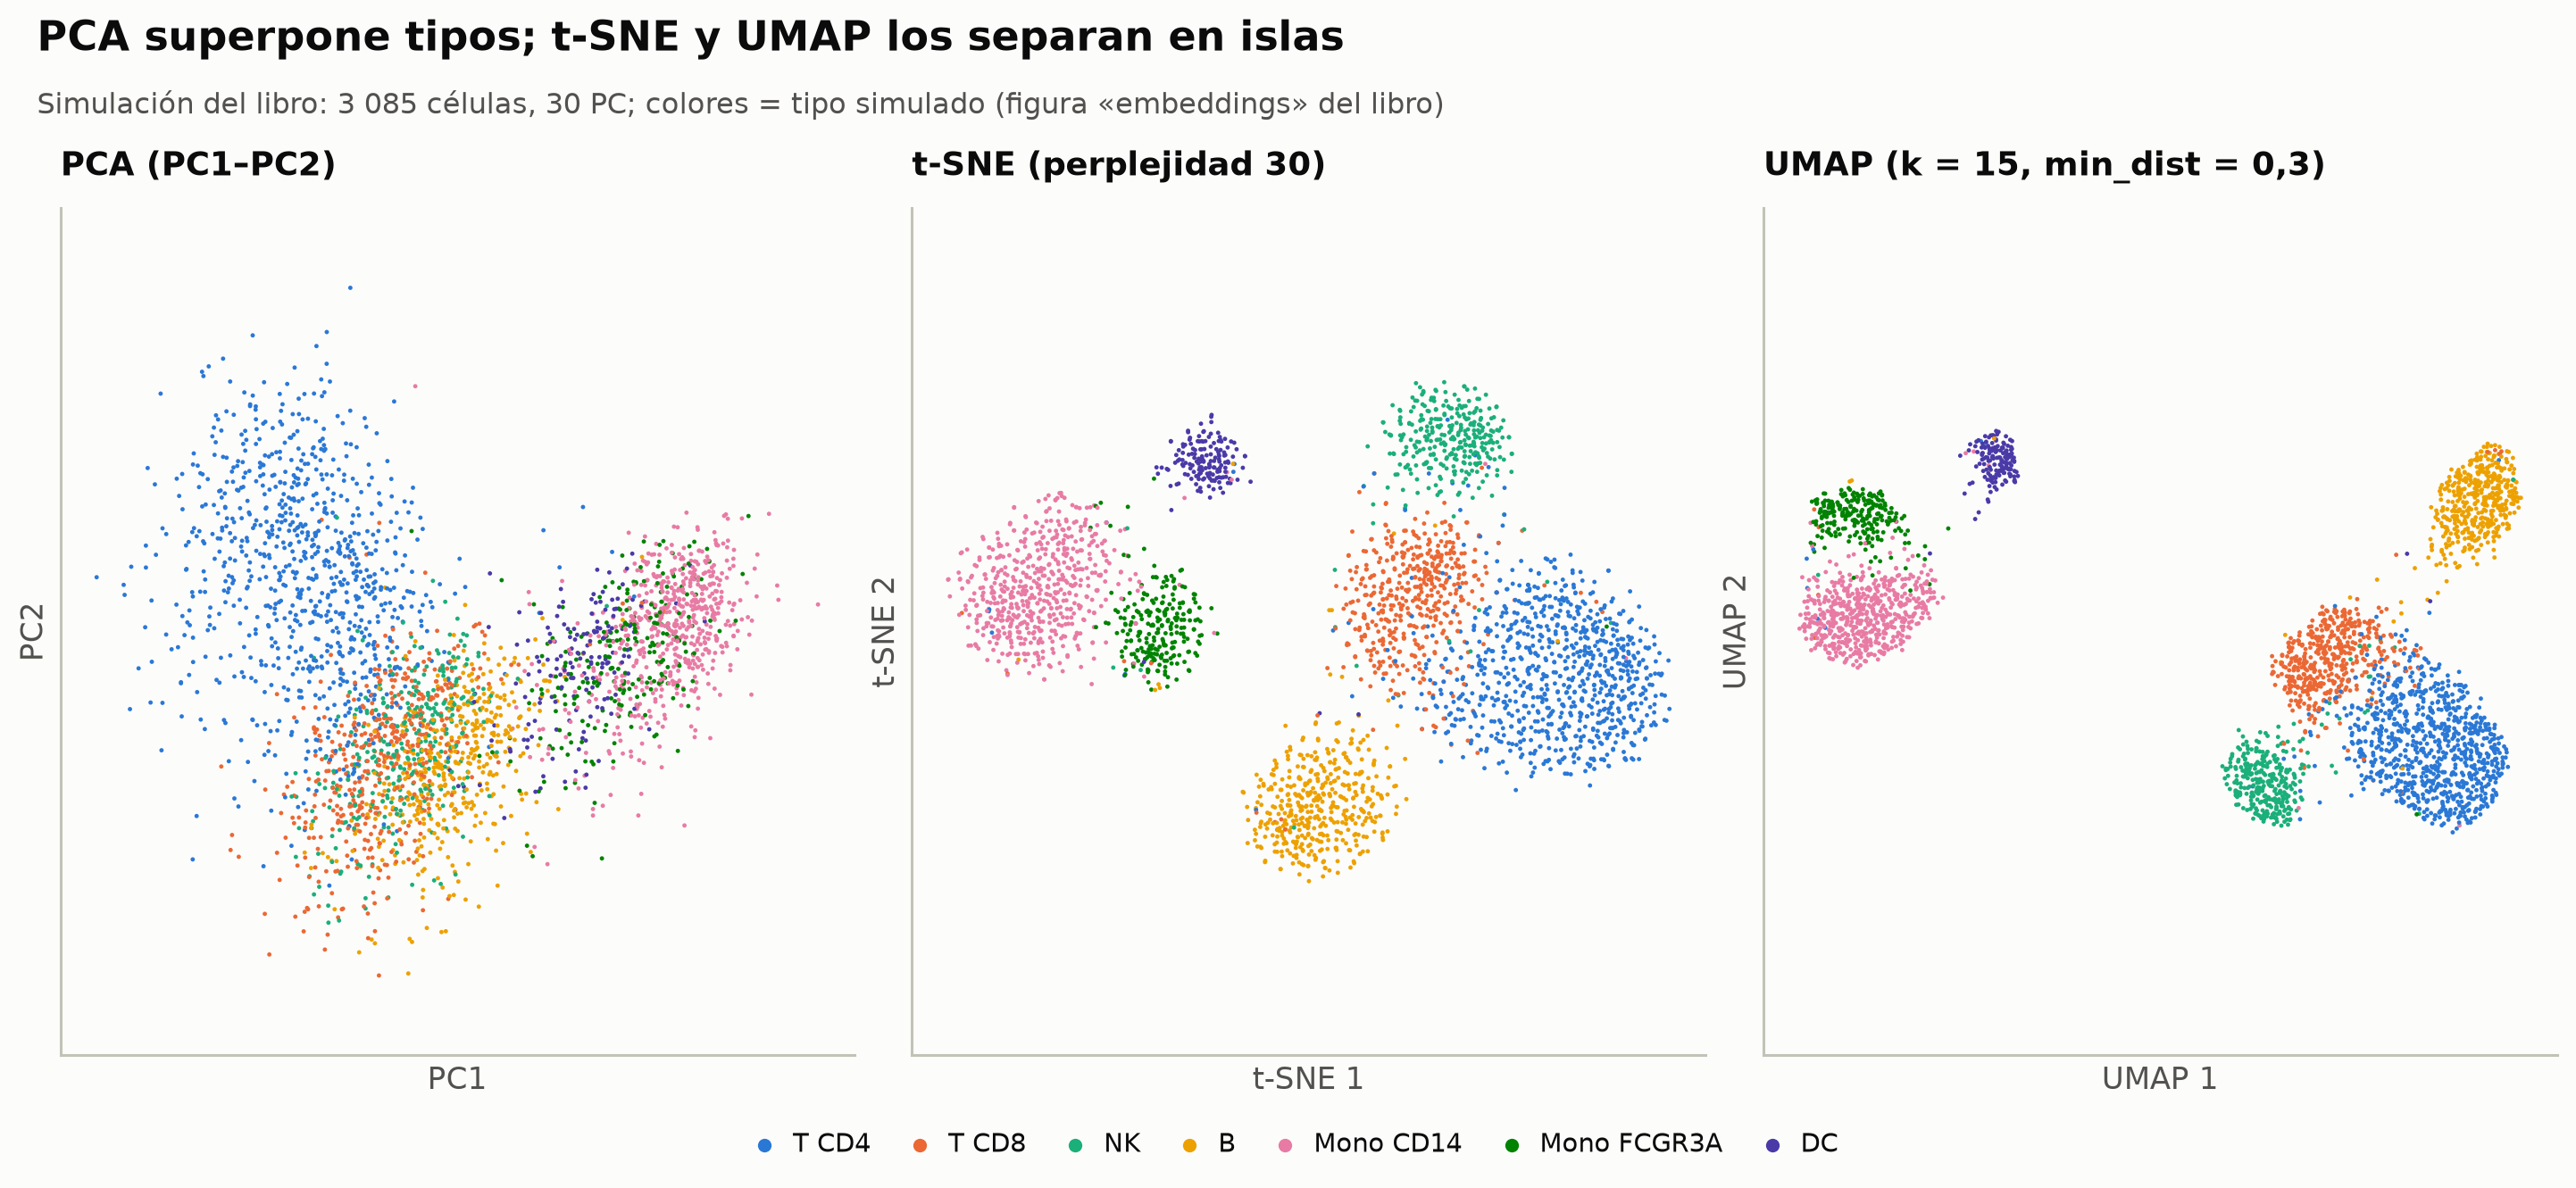

In [31]:
emb_sim = {"PCA": pcs_sim[:, :2], "t-SNE": sim["tsne"].astype(float), "UMAP": sim["umap"].astype(float)}
fig, axs = plt.subplots(1, 3, figsize=(13, 4.9))
for ax, (name, E), lab_ in zip(axs, emb_sim.items(), ("PC", "t-SNE ", "UMAP ")):
    panel_types(ax, E, T_sim, sim_cols)
    ax.set_title({"PCA": "PCA (PC1–PC2)", "t-SNE": "t-SNE (perplejidad 30)", "UMAP": "UMAP (k = 15, min_dist = 0,3)"}[name],
                 fontsize=12, loc="left")
    ax.set_xlabel(f"{lab_}1"); ax.set_ylabel(f"{lab_}2")
for i, t in enumerate(TIPOS):
    axs[2].scatter([], [], s=25, color=ec.CATEGORICAL[i], label=t)
fig.legend(*axs[2].get_legend_handles_labels(), loc="lower center", ncol=7, fontsize=9.5, bbox_to_anchor=(0.5, -0.08),
           handletextpad=0.1, columnspacing=0.9)
ec.fig_title(fig, "PCA superpone tipos; t-SNE y UMAP los separan en islas",
             "Simulación del libro: 3 085 células, 30 PC; colores = tipo simulado (figura «embeddings» del libro)")
plt.show()

> 🔎 **Qué observamos.** Las dos primeras PC separan el eje mieloide–linfoide y el estado continuo de las T CD4, pero
> superponen tipos que difieren en direcciones de menor varianza. t-SNE separa los siete tipos en islas compactas;
> UMAP produce grupos similares, más compactos y con más espacio vacío entre ellos. Ni el tamaño de las islas ni la
> distancia entre ellas deben leerse al pie de la letra. Vamos a cuantificarlo.

### 5.1 Tres medidas de distorsión

Para 4 000 pares de células al azar comparamos su distancia en el espacio de 30 PC con su distancia en el mapa:

* **Correlación de Spearman $\rho$** entre ambas distancias: ¿se conserva el **orden** de las distancias?
* **Vecinos conservados**: de los 15 vecinos más cercanos de cada célula en 30 PC, ¿qué fracción sigue entre sus 15
  más cercanos en el mapa? (Lo **local**.)
* **Centroides**: correlación de Spearman entre las distancias de los centroides de los tipos en 30 PC y en el mapa.
  (Lo **global**, entre grupos.)

> 🤔 **Antes de ejecutar, prediga…** ¿Qué método tendrá la mayor $\rho$ global? ¿Y la mayor fracción de vecinos
> conservados?

In [32]:
def distortion(Xhigh, embs, labels, n_types, seed=4, npair=4000, k=15):
    """Spearman de distancias entre pares al azar, fracción de kNN conservados y Spearman entre centroides."""
    rng_ = np.random.default_rng(seed)
    a_, b_ = rng_.integers(0, len(Xhigh), npair), rng_.integers(0, len(Xhigh), npair)
    m_ = a_ != b_; a_, b_ = a_[m_], b_[m_]
    dh = np.linalg.norm(Xhigh[a_] - Xhigh[b_], axis=1)
    knn = lambda Zx: NearestNeighbors(n_neighbors=k + 1).fit(Zx).kneighbors(Zx)[1][:, 1:]
    ref = knn(Xhigh)
    iu = np.triu_indices(n_types, 1)
    cH = np.array([Xhigh[labels == t].mean(0) for t in range(n_types)])
    dH = np.linalg.norm(cH[:, None] - cH[None], axis=2)[iu]
    out, pairs = {}, {}
    for name, E in embs.items():
        dl = np.linalg.norm(E[a_] - E[b_], axis=1)
        kk = knn(E)
        pres = np.mean([len(set(ref[i]) & set(kk[i])) / k for i in range(len(ref))])
        cE = np.array([E[labels == t].mean(0) for t in range(n_types)])
        dE = np.linalg.norm(cE[:, None] - cE[None], axis=2)[iu]
        out[name] = dict(spearman=stats.spearmanr(dh, dl).statistic, knn=pres,
                         centroides=stats.spearmanr(dH, dE).statistic if name != "PCA" else np.nan)
        pairs[name] = (dh, dl)
    return pd.DataFrame(out).T, pairs

t0 = time.time()
res_sim, pairs_sim = distortion(X30_sim, emb_sim, T_sim, 7)
book = pd.DataFrame({"spearman": [0.610, 0.444, 0.424], "knn": [0.043, 0.233, 0.119],
                     "centroides": [np.nan, 0.835, 0.801]}, index=["PCA", "t-SNE", "UMAP"])
tab = pd.concat({"este notebook": res_sim.round(3), "libro": book}, axis=1)
print(f"⏱️ {time.time() - t0:.1f} s")
tab

⏱️ 0.1 s


este notebook                      libro                  
           spearman    knn centroides spearman    knn centroides
PCA           0.610  0.043        NaN    0.610  0.043        NaN
t-SNE         0.445  0.234      0.835    0.444  0.233      0.835
UMAP          0.424  0.119      0.801    0.424  0.119      0.801

> 🔎 **Qué observamos.** Reproducimos las cifras del libro: el PCA en 2D conserva mejor el **orden** de las distancias
> ($\rho=0{,}61$) pero es una pésima representación local: sólo el **4,3 %** de los 15 vecinos de cada célula sigue
> siéndolo en el plano. t-SNE ($\rho\approx0{,}44$) y UMAP ($\rho=0{,}42$) conservan más vecinos (≈ 23 % y 12 %). Las
> diferencias en la tercera cifra decimal para t-SNE (0,445 frente a 0,444; 0,234 frente a 0,233) vienen de que las
> coordenadas de t-SNE cambian ligeramente entre versiones de scikit-learn; las del mapa guardado se calcularon con
> una versión más reciente que la usada para el libro.

Ahora lo mismo con las células reales, y mirando la **forma** de la relación entre distancias.

⏱️ 0.0 s


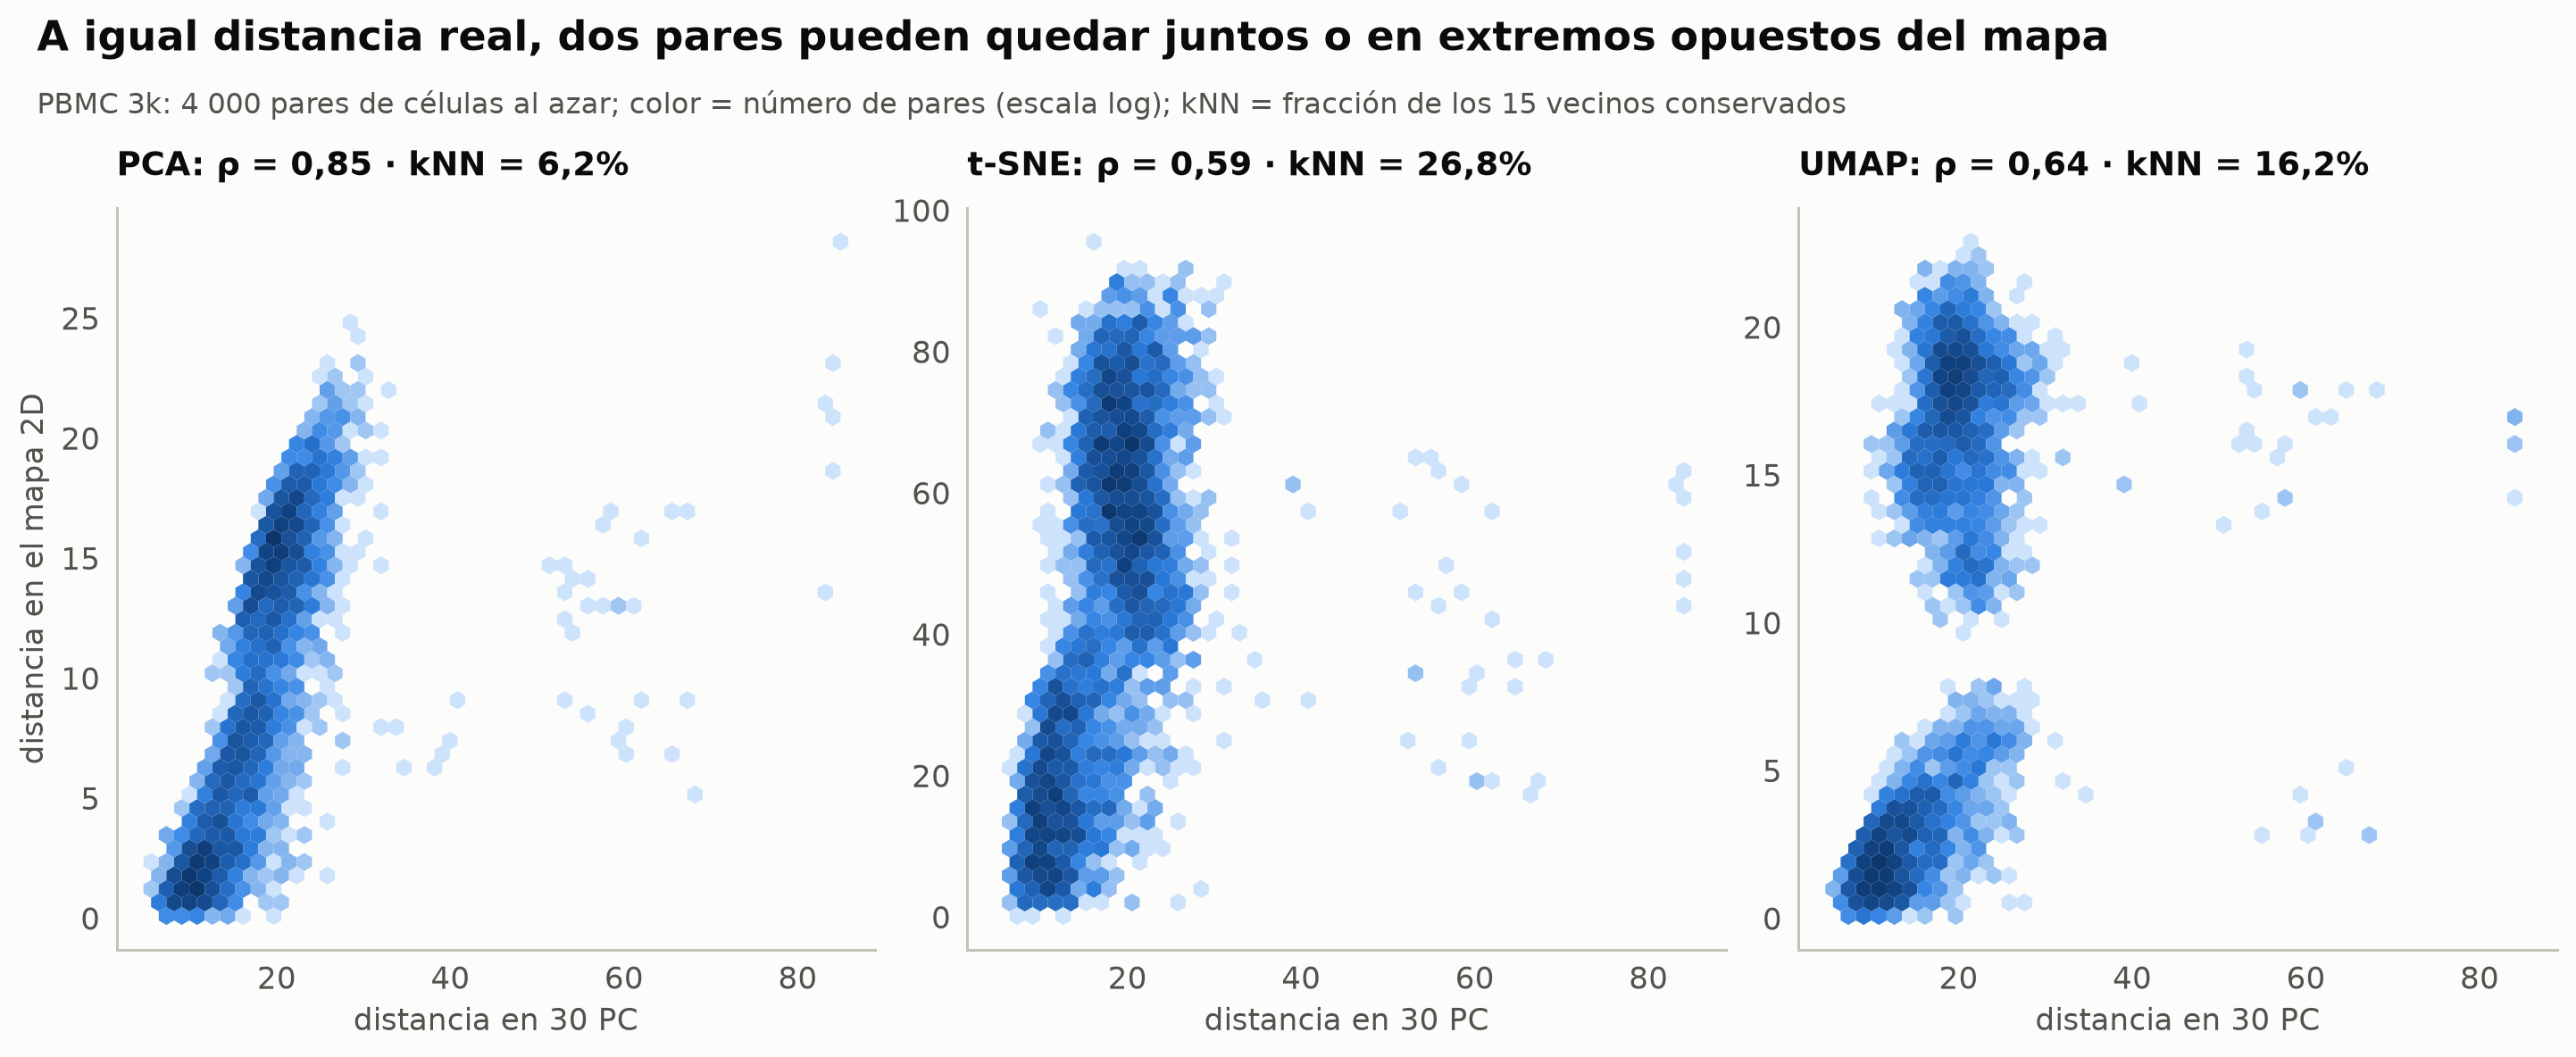

,spearman,knn,centroides
PCA,0.855,0.062,NaN
t-SNE,0.590,0.268,0.107
UMAP,0.639,0.162,0.173


In [33]:
t0 = time.time()
emb_real = {"PCA": pcs[:, :2], "t-SNE": emb_tsne, "UMAP": emb_umap}
typ_idx = np.array([list(MARKERS).index(t) for t in cell_type])
res_real, pairs_real = distortion(X30, emb_real, typ_idx, len(MARKERS))
print(f"⏱️ {time.time() - t0:.1f} s")
fig, axs = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, name in zip(axs, emb_real):
    dh, dl = pairs_real[name]
    ax.hexbin(dh, dl, gridsize=45, cmap=ec.CMAP_SEQ, mincnt=1, bins="log", lw=0)
    r_ = res_real.loc[name]
    ax.set_title(f"{name}: ρ = {r_.spearman:.2f} · kNN = {r_.knn:.1%}".replace(".", ","), fontsize=12, loc="left")
    ax.set_xlabel("distancia en 30 PC"); ax.grid(False)
axs[0].set_ylabel("distancia en el mapa 2D")
ec.fig_title(fig, "A igual distancia real, dos pares pueden quedar juntos o en extremos opuestos del mapa",
             "PBMC 3k: 4 000 pares de células al azar; color = número de pares (escala log); kNN = fracción de los 15 vecinos conservados")
plt.show()
res_real.round(3)

> 🔎 **Qué observamos.** En el PCA la nube es una banda ancha pero **monótona**: más lejos en 30 PC suele ser más lejos
> en el plano. En t-SNE y UMAP la relación se **rompe en escalones**: los pares cercanos (a la izquierda) quedan cerca,
> pero a partir de cierta distancia real el mapa coloca a unos pares a distancia media y a otros en extremos opuestos,
> según caigan en la misma isla o en islas distintas. Y, de nuevo, t-SNE y UMAP conservan muchos más vecinos que el
> PCA: son buenos **mapas de barrio** y malos **mapas de carreteras**. En la tabla, la columna de centroides lo confirma
con crudeza: en PBMC la correlación entre las distancias de los centroides de los tipos en 30 PC y en el mapa es
apenas de 0,1–0,2 (con sólo ocho tipos, y uno de 16 células), muy por debajo de la simulación.

### 5.2 El tamaño de una isla no mide su heterogeneidad

t-SNE y UMAP adaptan la escala local a la densidad ($\sigma_i$, $\rho_i$), así que el área que ocupa un grupo en el
mapa no refleja cuánto varían sus células. Lo comprobamos comparando, para cada tipo provisional, la dispersión en 30
PC (distancia media al centroide) con la dispersión en el UMAP.

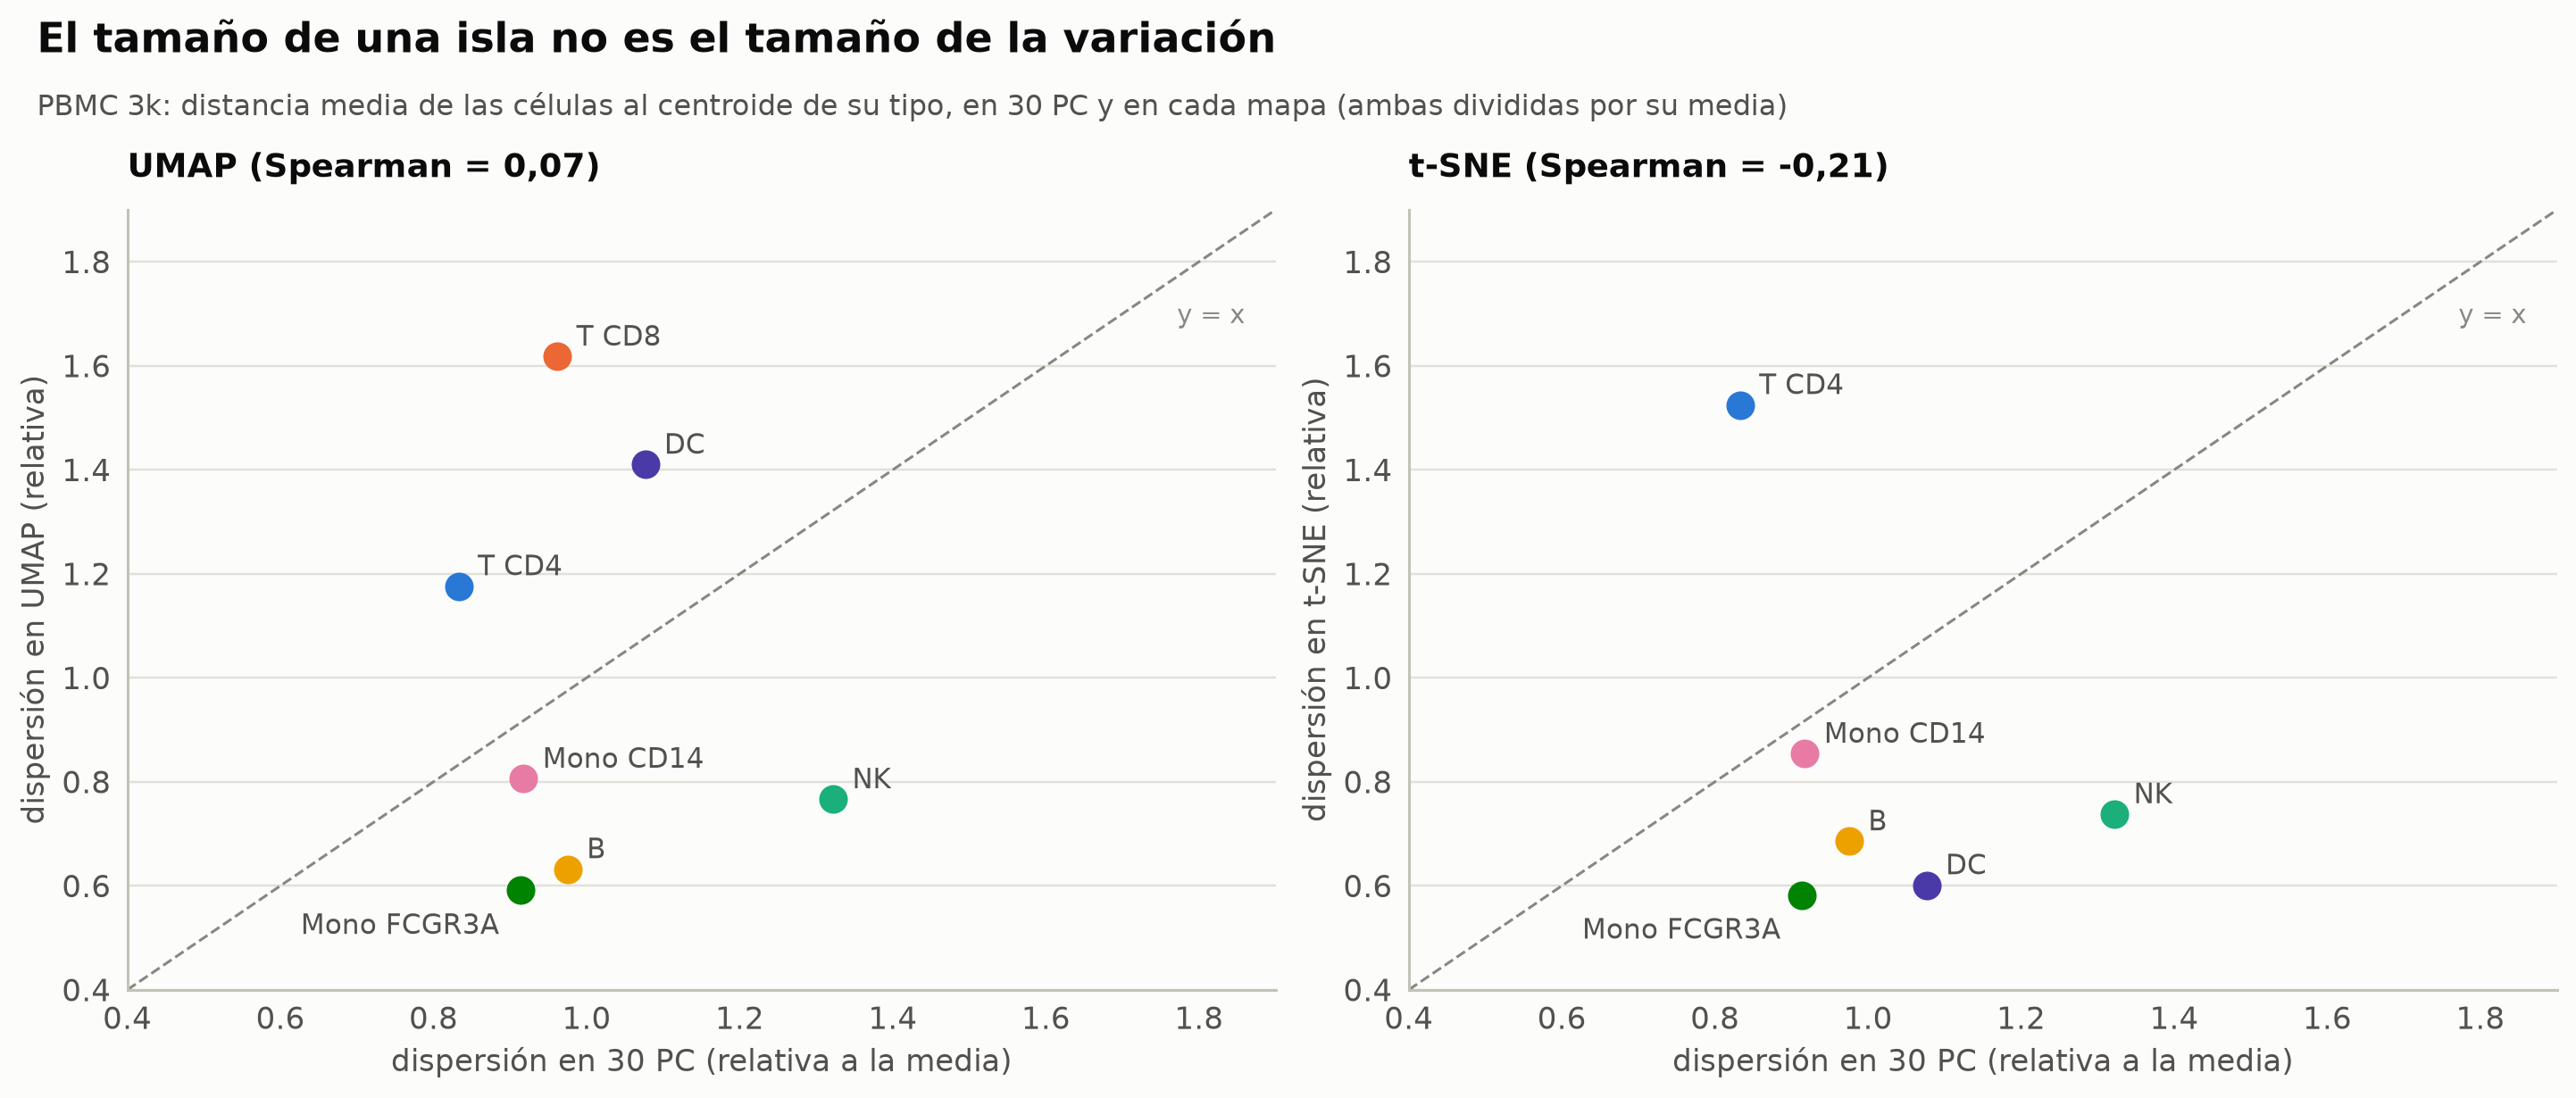

In [34]:
def spread(E, lab_, t):
    Et = E[lab_ == t]
    return np.linalg.norm(Et - Et.mean(0), axis=1).mean()
types_ok = [t for t in MARKERS if np.sum(cell_type == t) >= 30]
sp_pc = np.array([spread(X30, cell_type, t) for t in types_ok])
sp_um = np.array([spread(emb_umap, cell_type, t) for t in types_ok])
sp_ts = np.array([spread(emb_tsne, cell_type, t) for t in types_ok])
fig, axs = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, sp2, nm in ((axs[0], sp_um, "UMAP"), (axs[1], sp_ts, "t-SNE")):
    for t, x_, y_ in zip(types_ok, sp_pc / sp_pc.mean(), sp2 / sp2.mean()):
        ax.scatter(x_, y_, s=110, color=TYPE_COLORS[t], edgecolor="white", zorder=3)
        below = t == "Mono FCGR3A"
        ax.annotate(t, (x_, y_), xytext=(-8, -16) if below else (7, 4), textcoords="offset points",
                    ha="right" if below else "left", fontsize=10, color=ec.INK_2)
    lim_ = [0.4, 1.9]
    ax.plot(lim_, lim_, color=ec.MUTED, ls="--", lw=1)
    ax.text(1.86, 1.72, "y = x", ha="right", va="top", fontsize=9.5, color=ec.MUTED)
    ax.set_xlim(*lim_); ax.set_ylim(*lim_)
    rr = stats.spearmanr(sp_pc, sp2).statistic
    ax.set_title(f"{nm} (Spearman = {rr:.2f})".replace(".", ","), fontsize=12, loc="left")
    ax.set_xlabel("dispersión en 30 PC (relativa a la media)"); ax.set_ylabel(f"dispersión en {nm} (relativa)")
ec.fig_title(fig, "El tamaño de una isla no es el tamaño de la variación",
             "PBMC 3k: distancia media de las células al centroide de su tipo, en 30 PC y en cada mapa (ambas divididas por su media)")
plt.show()

> 🔎 **Qué observamos.** Si el mapa conservara la heterogeneidad, los puntos caerían sobre la diagonal y la
> correlación de Spearman sería cercana a 1. Es prácticamente nula en UMAP e incluso negativa en t-SNE. Las NK, el tipo
> más disperso en el espacio de 30 PC, forman una isla pequeña; las T CD4, de las más compactas en PC, ocupan una de
> las mayores áreas del mapa, sobre todo porque son muchas células: t-SNE y UMAP reparten espacio según el **número**
> de células y su densidad local, no según su variabilidad.

### 5.3 La lista de prohibiciones

Chari y Pachter (2023) llevaron el argumento al extremo: mostraron que los *embeddings* de t-SNE y UMAP distorsionan
severamente las distancias de conjuntos de datos reales, y que se puede forzar a los datos a adoptar casi cualquier
forma deseada (¡incluso la de un elefante!) conservando niveles de preservación de vecindarios comparables. La lección
práctica:

* **No interprete tamaños.** t-SNE y UMAP adaptan la escala local a la densidad; un grupo grande en el mapa no es un
  grupo más heterogéneo (sección 5.2).
* **No interprete distancias entre grupos.** En la simulación, la correlación entre las distancias de los centroides
  de los siete tipos en el espacio de PC y en el mapa es de 0,835 para t-SNE y 0,801 para UMAP: el **orden** se
  conserva en gran parte, pero no la magnitud.
* **No cuantifique en 2D.** Agrupamientos, trayectorias y distancias se calculan en el espacio de PC (o en el grafo de
  vecinos), nunca en las coordenadas del mapa.

> 💡 **Idea clave.** PCA para calcular; t-SNE y UMAP para mirar. Un vecino en el mapa es probablemente un vecino
> real; una distancia en el mapa no es una distancia.

> ✅ **Compruebe su comprensión.** En un ensayo clínico, el grupo de monocitos de los pacientes tratados aparece «más
> lejos» de las células T en el UMAP que el de los controles. ¿Puede concluir que el tratamiento cambió el perfil de
> los monocitos? *(Respuesta: no a partir del mapa. Habría que comparar los perfiles en el espacio de expresión o de
> PC, con una prueba de expresión diferencial por muestra —pseudobulk—; la posición relativa de las islas depende de
> la semilla, de $k$ y de la composición de cada muestra.)*

## 6. El código de producción con Scanpy

Todo lo que hicimos desde cero cabe en siete líneas. Así se ve en un análisis real (el bloque del libro):

```python
sc.pp.scale(adata, max_value=10)           # z-score, truncado en 10
sc.tl.pca(adata, n_comps=50, mask_var="highly_variable")
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)   # grafo kNN
sc.tl.umap(adata, min_dist=0.3)
sc.tl.tsne(adata, n_pcs=30, perplexity=30)
sc.pl.umap(adata, color=["CD3E", "MS4A1", "LYZ", "pct_counts_mt"])
```

| Línea | Qué hace | Sección de esta clase |
|---|---|---|
| `sc.pp.scale` | Construye $Z$: centra, escala y trunca en ±10 | 1.3 |
| `sc.tl.pca` | SVD de $Z$ restringida a los HVG | 2.3–2.5 |
| `sc.pl.pca_variance_ratio` | Gráfico de codo | 2.4 |
| `sc.pp.neighbors` | Grafo difuso de UMAP ($\rho_i$, $\sigma_i$, unión) sobre 30 PC | 4.1 |
| `sc.tl.umap` | Optimiza la entropía cruzada con $a$, $b$ de `min_dist` | 4.2–4.4 |
| `sc.tl.tsne` | t-SNE con perplejidad 30 (scikit-learn) | 3.5 |

> ⚠️ **Cuidado: UMAP necesita el grafo.** En Scanpy, `sc.tl.umap` **no recalcula vecinos**: usa el grafo de
> `sc.pp.neighbors`. Cambiar `n_neighbors` en el grafo cambia a la vez el mapa y los *clusters* de la lección
> siguiente. Colorear el mapa por `pct_counts_mt` o `total_counts` es la forma más rápida de descubrir que un «tipo
> celular nuevo» es en realidad un grupo de células de mala calidad.

La figura siguiente es la versión estática de ese control: el UMAP de PBMC coloreado por las dos métricas de calidad.

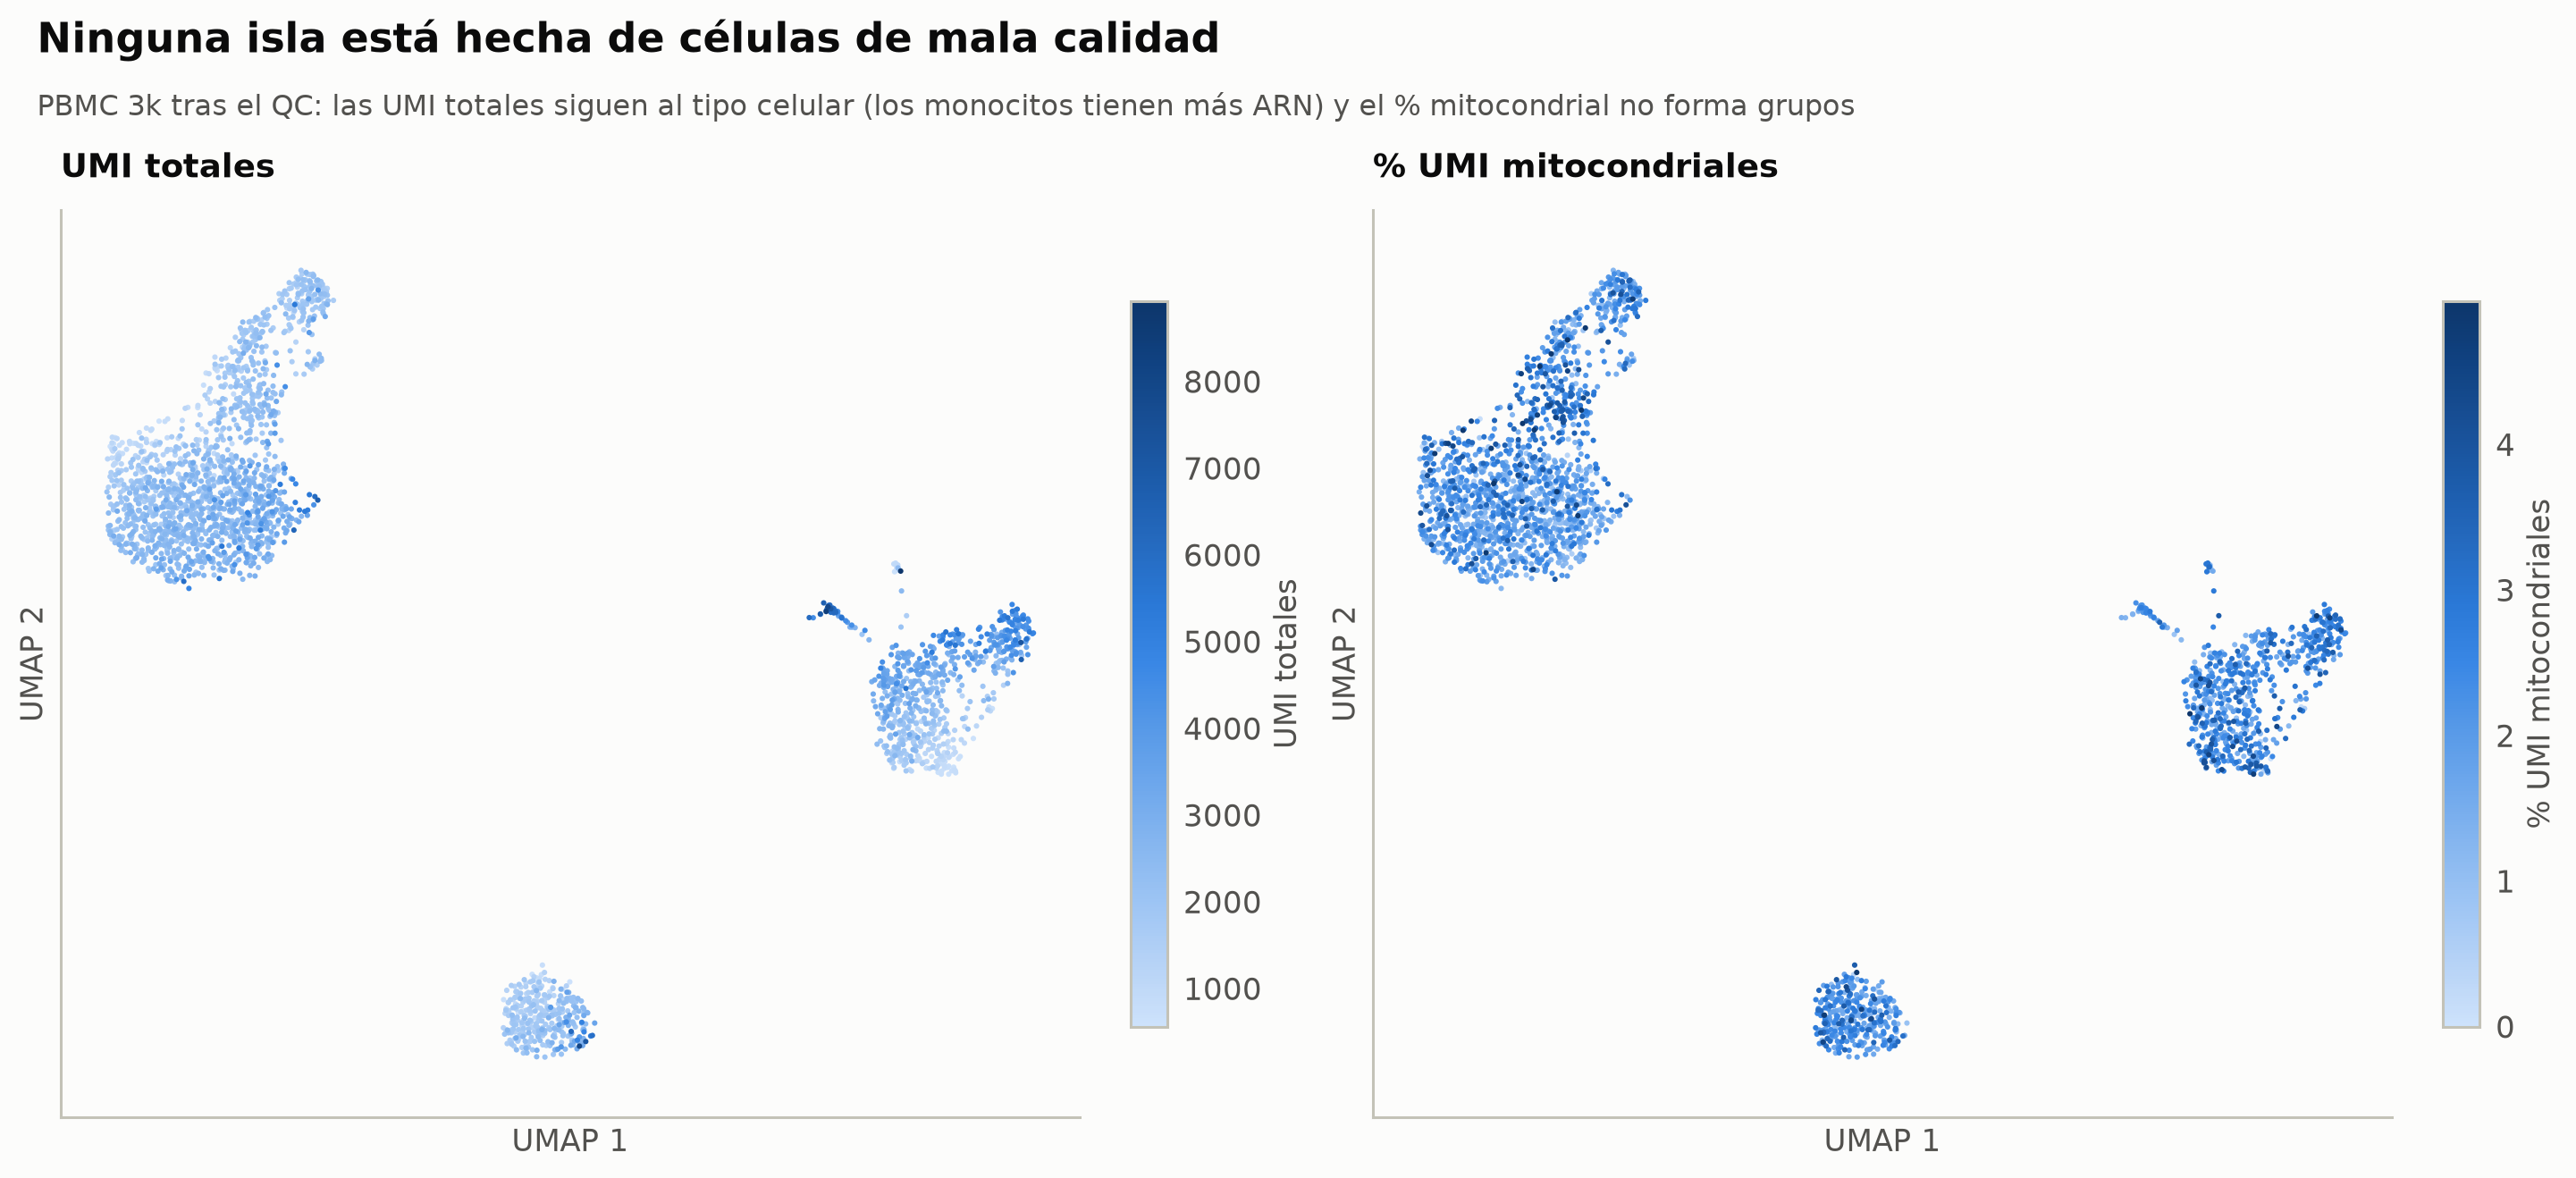

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, col_, lab_ in ((axs[0], "total_counts", "UMI totales"), (axs[1], "pct_counts_mt", "% UMI mitocondriales")):
    v_ = adata.obs[col_].values; o = np.argsort(v_)
    im_ = ax.scatter(emb_umap[o, 0], emb_umap[o, 1], c=v_[o], s=4, cmap=ec.CMAP_SEQ, lw=0)
    fig.colorbar(im_, ax=ax, shrink=0.8, label=lab_)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False); ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(lab_, fontsize=12, loc="left"); ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ec.fig_title(fig, "Ninguna isla está hecha de células de mala calidad",
             "PBMC 3k tras el QC: las UMI totales siguen al tipo celular (los monocitos tienen más ARN) y el % mitocondrial no forma grupos")
plt.show()

> 🔎 **Qué observamos.** Las UMI totales varían **por tipo** (los monocitos, más grandes y activos, capturan más ARN que
> los linfocitos), lo cual es biología y no un artefacto; el porcentaje mitocondrial se reparte sin formar ninguna
> isla. Si hubiéramos relajado el QC, aparecería un grupo de células con % mitocondrial alto y pocas UMI, a menudo
> «entre» otros grupos: el falso tipo celular más común de la literatura.

## 7. Ejercicios

**Ejercicio 1 (perplejidad y densidad).** En la simulación del libro, la célula 0 es una DC (un tipo escaso). Elija
la primera célula T CD4 (`np.argmax(T_sim == 0)`) y calcule $\sigma$ con perplejidades 5, 30 y 300 usando
`sigma_perp`. ¿Es mayor o menor que para la célula 0? Explique por qué con la idea de densidad local.

**Ejercicio 2 (escalar o no escalar).** Repita el PCA de PBMC **sin escalar** los genes (sólo centrados, sin dividir
por la desviación típica). ¿Cuántas componentes superan ahora al nulo y qué genes dominan PC1? ¿Qué se gana y qué se
pierde?

**Ejercicio 3 (vecinos conservados según la perplejidad).** Con la función `distortion`, compare la fracción de 15
vecinos conservados y la $\rho$ de Spearman para los t-SNE de PBMC con perplejidades 5, 30 y 300 (`emb_perp`).
¿Confirma los números la impresión visual de la sección 3.6?

**Ejercicio 4 (sin exageración temprana).** Ejecute `tsne_scratch` sobre las mismas 700 células con `exag=1.0`.
Compare la KL final y el mapa con la versión con exageración. ¿Qué papel cumple la exageración?

**Ejercicio 5 (la unión difusa).** Demuestre que $\max(v_{j\mid i},v_{i\mid j})\le v_{ij}\le\min(1,\,v_{j\mid i}+
v_{i\mid j})$. Después, en el grafo `V_ours` de PBMC, calcule qué fracción de las aristas tiene $v_{ij}>0{,}99$ y
qué fracción de las células tiene al menos una arista con peso 1 (pista: $\rho_i$).

In [36]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
i_cd4 = int(np.argmax(T_sim == 0))
d2_cd4 = np.sum((np.delete(X30_sim, i_cd4, axis=0) - X30_sim[i_cd4]) ** 2, axis=1)
for perp in (5, 30, 300):
    s_a, _ = sigma_perp(d2_c0, perp); s_b, _ = sigma_perp(d2_cd4, perp)
    print(f"Perp {perp:3d}: σ célula 0 (DC) = {s_a:.3f} · σ célula {i_cd4} (T CD4) = {s_b:.3f}")
print("Con perplejidad 5 y 30 la célula T CD4 necesita un σ MAYOR que la DC: en la simulación las T CD4 no forman\n"
      "una bola compacta sino un continuo (el estado naive → memoria), así que sus vecinas inmediatas están más\n"
      "lejos que las de una DC dentro de su grupo pequeño y apretado. Con perplejidad 300 se invierte: el grupo de DC\n"
      "(158 células) se agota y su σ debe crecer para alcanzar a células de otros tipos, mientras que la T CD4 aún\n"
      "encuentra 300 vecinas dentro de su propio tipo (869 células). La densidad que importa depende de la escala.")

Perp   5: σ célula 0 (DC) = 0.893 · σ célula 5 (T CD4) = 1.410
Perp  30: σ célula 0 (DC) = 1.722 · σ célula 5 (T CD4) = 1.887
Perp 300: σ célula 0 (DC) = 2.834 · σ célula 5 (T CD4) = 2.503
Con perplejidad 5 y 30 la célula T CD4 necesita un σ MAYOR que la DC: en la simulación las T CD4 no forman
una bola compacta sino un continuo (el estado naive → memoria), así que sus vecinas inmediatas están más
lejos que las de una DC dentro de su grupo pequeño y apretado. Con perplejidad 300 se invierte: el grupo de DC
(158 células) se agota y su σ debe crecer para alcanzar a células de otros tipos, mientras que la T CD4 aún
encuentra 300 vecinas dentro de su propio tipo (869 células). La densidad que importa depende de la escala.


In [37]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
Zc = L_hvg - L_hvg.mean(0)                       # sólo centrado
pcs_c, frac_c, V_c = pca_svd(Zc, 50)
rng_e = np.random.default_rng(0)
Zc_perm = np.column_stack([rng_e.permutation(c) for c in Zc.T])
s_cp = np.linalg.svd(Zc_perm - Zc_perm.mean(0), compute_uv=False)
fnull = s_cp ** 2 / (s_cp ** 2).sum()
print(f"Sin escalar: PC1 explica {frac_c[0]:.1%}; componentes sobre el nulo: {int(np.sum(frac_c > fnull[0]))}")
print("Genes con mayor carga en PC1:", hvg_names[np.argsort(-np.abs(V_c[:, 0]))[:8]].tolist())
print("Sin escalar, los genes muy expresados (LYZ, S100A8/9, FTL...) acaparan la varianza: PC1 explica mucho más\n"
      "pero casi sólo 'monocito sí/no'. Se pierde sensibilidad para programas de genes poco expresados (p. ej., DC,\n"
      "plaquetas). Se gana robustez frente al ruido de genes raros, que el escalado amplifica.")

Sin escalar: PC1 explica 10.1%; componentes sobre el nulo: 4
Genes con mayor carga en PC1: ['LYZ', 'S100A9', 'CST3', 'TYROBP', 'S100A8', 'LGALS1', 'AIF1', 'LST1']
Sin escalar, los genes muy expresados (LYZ, S100A8/9, FTL...) acaparan la varianza: PC1 explica mucho más
pero casi sólo 'monocito sí/no'. Se pierde sensibilidad para programas de genes poco expresados (p. ej., DC,
plaquetas). Se gana robustez frente al ruido de genes raros, que el escalado amplifica.


In [38]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
res_p, _ = distortion(X30, {f"Perp {p}": emb_perp[p] for p in (5, 30, 300)}, typ_idx, len(MARKERS))
print(res_p[["spearman", "knn", "centroides"]].round(3).to_string())
print("Con perplejidad 300 la ρ global sube con claridad y la fracción de 15 vecinos conservados cae: es el\n"
      "compromiso local/global del texto. La correlación entre centroides es inestable (sólo 8 tipos, 28 pares y una\n"
      "isla de 16 plaquetas que se coloca casi al azar): con tan pocos grupos no conviene sacar conclusiones de ella.")

          spearman    knn  centroides
Perp 5       0.579  0.235       0.300
Perp 30      0.590  0.268       0.107
Perp 300     0.723  0.154       0.250
Con perplejidad 300 la ρ global sube con claridad y la fracción de 15 vecinos conservados cae: es el
compromiso local/global del texto. La correlación entre centroides es inestable (sólo 8 tipos, 28 pares y una
isla de 16 plaquetas que se coloca casi al azar): con tan pocos grupos no conviene sacar conclusiones de ella.


KL final con exageración = 1.093 · sin exageración = 1.097


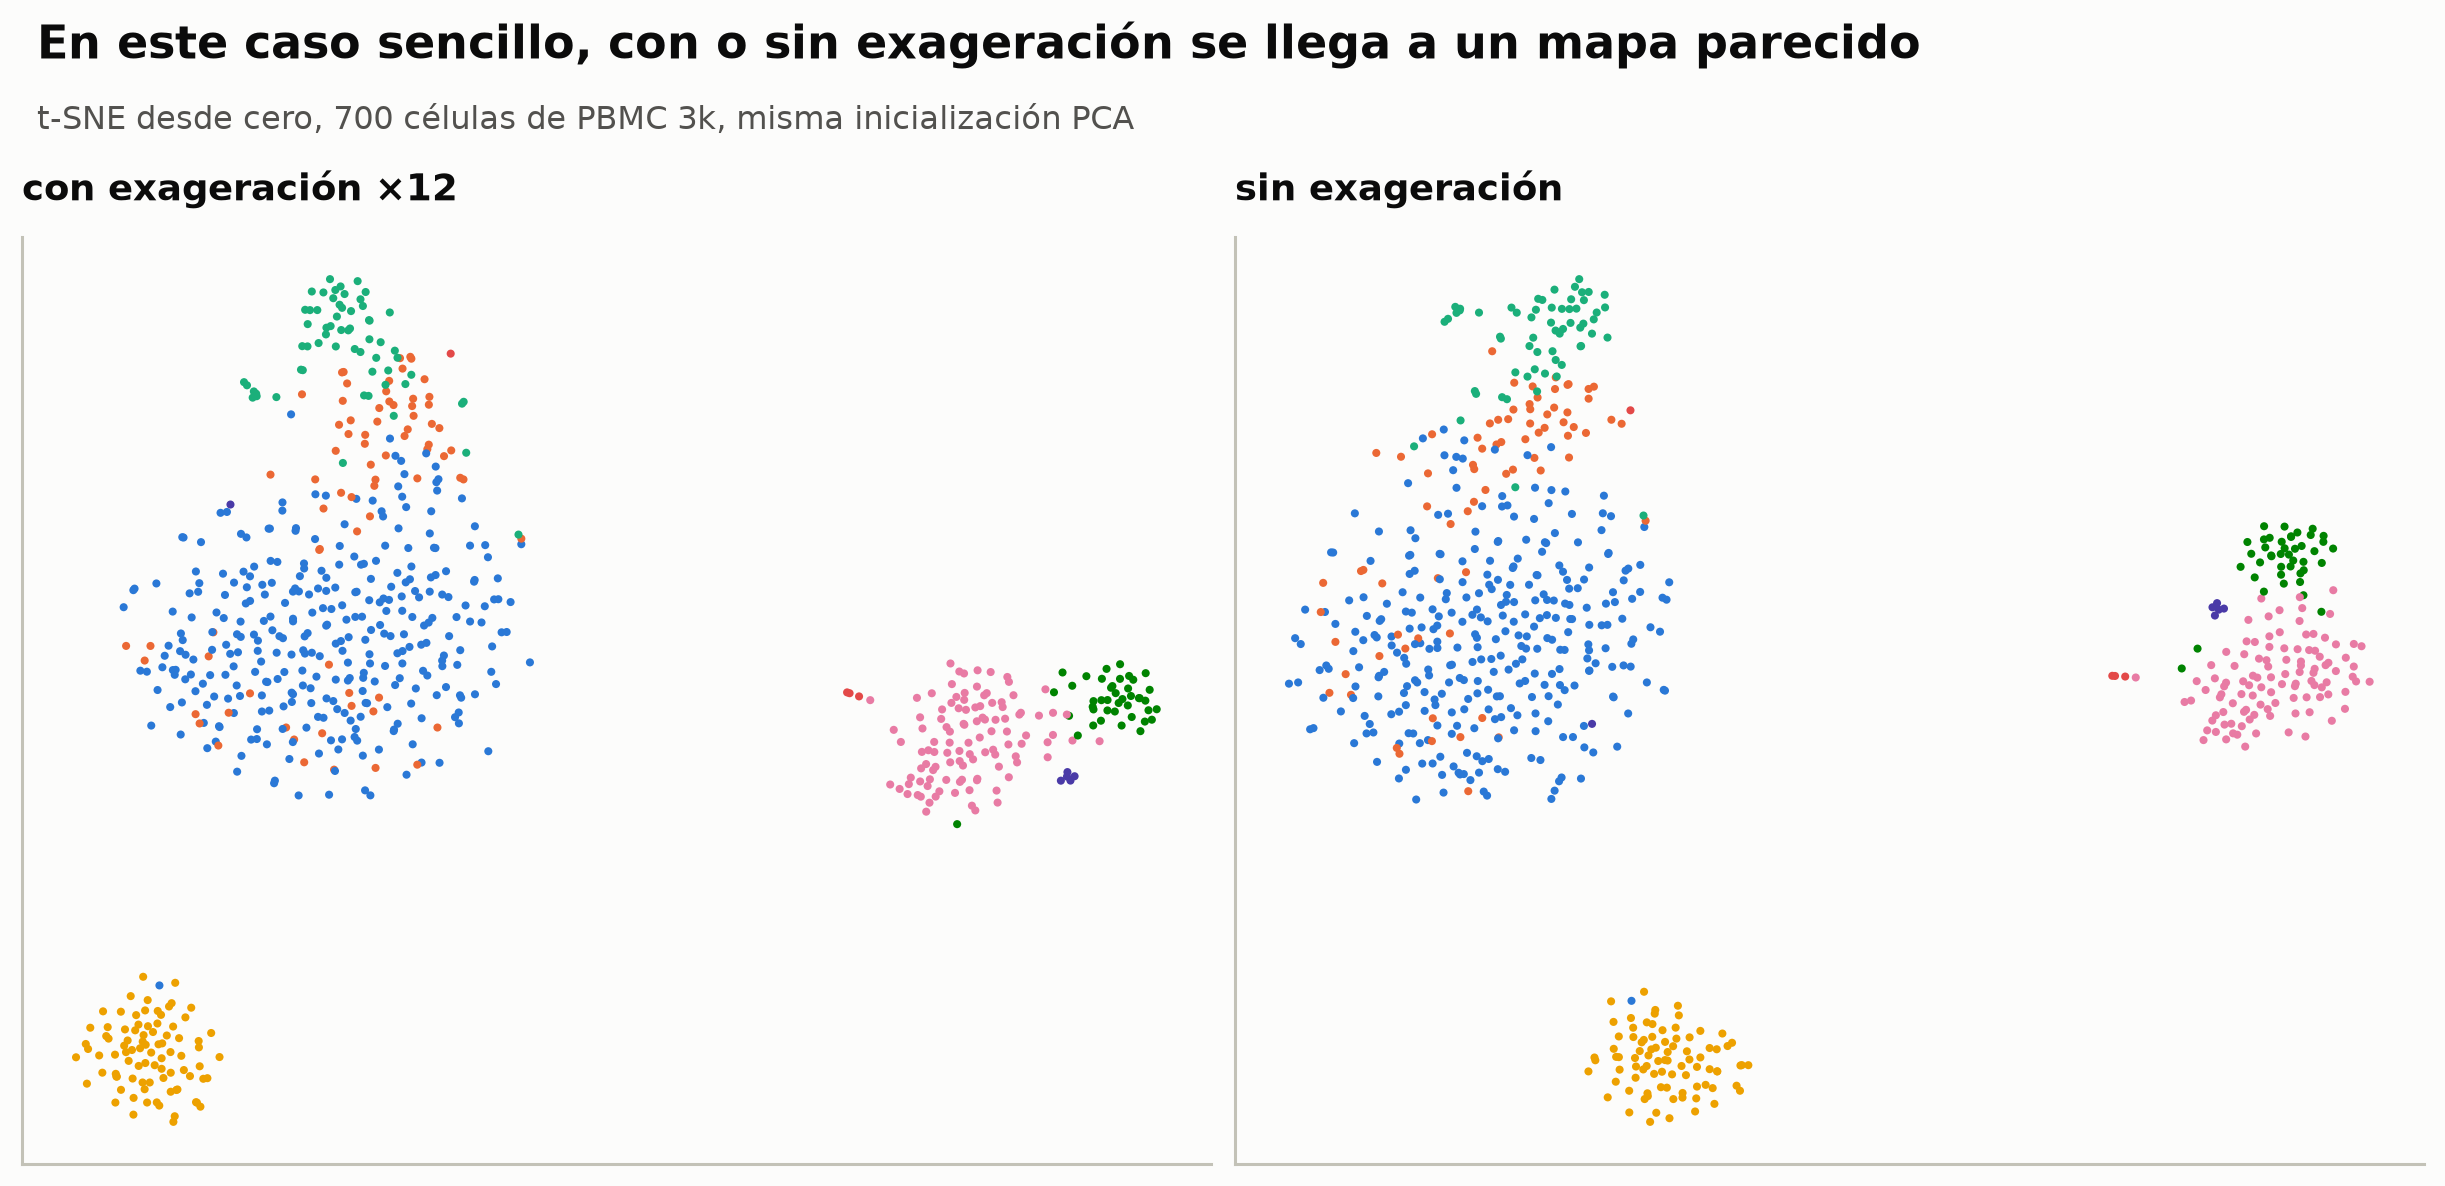

Con 700 células e inicialización PCA, ambos mapas y sus KL son casi iguales: la inicialización ya coloca bien
los grandes grupos. La exageración se vuelve decisiva con inicialización aleatoria o con decenas de miles de
células: sin ella, las repulsiones actúan desde el principio y fragmentos de un mismo tipo pueden quedar
atrapados lejos unos de otros (mínimos locales). Pruebe a repetir con Y0 aleatorio para verlo.


In [39]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
Y_noex, _, _, kl_noex = tsne_scratch(X_sub, 30, exag=1.0)
print(f"KL final con exageración = {kl_curve[-1, 1]:.3f} · sin exageración = {kl_noex[-1, 1]:.3f}")
fig, axs = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, E, nm in ((axs[0], Y_scr, "con exageración ×12"), (axs[1], Y_noex, "sin exageración")):
    ax.scatter(E[:, 0], E[:, 1], s=7, c=sub_cols, lw=0); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_title(nm, fontsize=12, loc="left")
ec.fig_title(fig, "En este caso sencillo, con o sin exageración se llega a un mapa parecido",
             "t-SNE desde cero, 700 células de PBMC 3k, misma inicialización PCA")
plt.show()
print("Con 700 células e inicialización PCA, ambos mapas y sus KL son casi iguales: la inicialización ya coloca bien\n"
      "los grandes grupos. La exageración se vuelve decisiva con inicialización aleatoria o con decenas de miles de\n"
      "células: sin ella, las repulsiones actúan desde el principio y fragmentos de un mismo tipo pueden quedar\n"
      "atrapados lejos unos de otros (mínimos locales). Pruebe a repetir con Y0 aleatorio para verlo.")

In [40]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
print("Con a = v_j|i y b = v_i|j en [0, 1]: a + b − ab = a + b(1 − a) ≥ a (y análogo ≥ b), luego ≥ max(a, b);\n"
      "y a + b − ab ≤ a + b, además a + b − ab = 1 − (1 − a)(1 − b) ≤ 1.")
vv = V_ours.tocoo()
m_up = vv.row < vv.col
print(f"Aristas (no dirigidas) con v_ij > 0,99: {np.mean(vv.data[m_up] > 0.99):.1%}")
has_one = np.asarray((V_ours >= 1 - 1e-9).sum(1)).ravel() > 0
print(f"Células con al menos una arista de peso 1: {has_one.mean():.1%} (garantizado por ρ_i: la vecina más cercana pesa 1)")

Con a = v_j|i y b = v_i|j en [0, 1]: a + b − ab = a + b(1 − a) ≥ a (y análogo ≥ b), luego ≥ max(a, b);
y a + b − ab ≤ a + b, además a + b − ab = 1 − (1 − a)(1 − b) ≤ 1.
Aristas (no dirigidas) con v_ij > 0,99: 7.8%
Células con al menos una arista de peso 1: 100.0% (garantizado por ρ_i: la vecina más cercana pesa 1)


## 📌 Resumen

* La reducción de dimensión cumple **dos papeles**: **compresión** (PCA, 30–50 PC) para vecinos, grupos y
  trayectorias, y **visualización** (t-SNE, UMAP, 2D) sólo para mirar.
* El **PCA** maximiza $w^\top Sw$ con $w^\top w=1$ (12-pca-prob); el lagrangiano da $Sw=\lambda w$ (12-pca-eig): las
  componentes son vectores propios de $S$ y $\lambda$ es la varianza capturada. En la práctica, $Z=U\Sigma V^\top$:
  cargas $V$, coordenadas $U\Sigma$, $\lambda_k=\sigma_k^2/(n-1)$ y la mejor aproximación de rango $k$ (Eckart-Young).
* En la simulación del libro PC1 explica el **2,45 %** y 30 PC el **15,2 %**; frente a un nulo de genes permutados
  (máximo **0,39 %**) sólo **7** componentes tienen señal. Se usan 30–50: tomar de más es barato, de menos puede fundir
  poblaciones raras. En PBMC 3k, PC1 = mieloide/linfoide, PC2 = citotóxicas, PC3 = plaquetas.
* **t-SNE**: $p_{j\mid i}$ gaussiana con $\sigma_i$ propio por bisección para una **perplejidad** $2^{H(P_i)}$ dada
  (12-tsne-p); simetrización $/2n$; $q_{ij}$ con núcleo de Cauchy contra el **hacinamiento** (12-tsne-q); minimiza
  $\mathrm{KL}(P\Vert Q)$ con el gradiente de resortes 12-grad. Ejemplo del libro: $\sigma=0{,}893/1{,}722/2{,}834$ con
  perplejidad 5/30/300; el vecino más cercano recibe 42,4 %/12,1 %/2,5 %.
* **UMAP**: grafo de $k$ vecinos con $v_{j\mid i}=\exp(-(d-\rho_i)/\sigma_i)$, $\sum v=\log_2k$ y **unión difusa**
  (12-umap-v); mapa con $w_{ij}=(1+a\,d^{2b})^{-1}$ ($a,b$ desde `min_dist`) y **entropía cruzada** con término
  repulsivo explícito (12-umap-ce). En Scanpy, `sc.tl.umap` usa el grafo de `sc.pp.neighbors`.
* **Perplejidad** y `n_neighbors` fijan la escala (baja → fragmentos espurios; alta → estructura global y fusión de
  tipos cercanos); `min_dist`, sólo lo compacto.
* **Distorsión** (libro): Spearman de distancias 0,61 (PCA), 0,44 (t-SNE), 0,42 (UMAP); vecinos conservados 4,3 %,
  23,3 % y 11,9 %; centroides 0,835 y 0,801. **No interprete tamaños ni distancias entre grupos; no cuantifique en 2D.**
  Colorear por `pct_counts_mt` y `total_counts` desenmascara falsos tipos celulares.

## 📚 Lecturas recomendadas

* van der Maaten, L. y Hinton, G. (2008). Visualizing data using t-SNE. *Journal of Machine Learning Research*, 9,
  2579–2605. https://jmlr.org/papers/v9/vandermaaten08a.html
* Kobak, D. y Berens, P. (2019). The art of using t-SNE for single-cell transcriptomics. *Nature Communications*,
  10, 5416. https://doi.org/10.1038/s41467-019-13056-x
* Belkina, A. C. et al. (2019). Automated optimized parameters for T-distributed stochastic neighbor embedding improve
  visualization and analysis of large datasets. *Nature Communications*, 10, 5415.
  https://doi.org/10.1038/s41467-019-13055-y
* Linderman, G. C., Rachh, M., Hoskins, J. G., Steinerberger, S. y Kluger, Y. (2019). Fast interpolation-based t-SNE
  for improved visualization of single-cell RNA-seq data. *Nature Methods*, 16(3), 243–245.
  https://doi.org/10.1038/s41592-018-0308-4
* Poličar, P. G., Stražar, M. y Zupan, B. (2024). openTSNE: A modular Python library for t-SNE dimensionality reduction
  and embedding. *Journal of Statistical Software*, 109(3). https://doi.org/10.18637/jss.v109.i03
* McInnes, L., Healy, J. y Melville, J. (2018). UMAP: Uniform Manifold Approximation and Projection for Dimension
  Reduction. *arXiv*. https://doi.org/10.48550/arXiv.1802.03426
* Becht, E. et al. (2019). Dimensionality reduction for visualizing single-cell data using UMAP. *Nature
  Biotechnology*, 37(1), 38–44. https://doi.org/10.1038/nbt.4314
* Chari, T. y Pachter, L. (2023). The specious art of single-cell genomics. *PLOS Computational Biology*, 19(8),
  e1011288. https://doi.org/10.1371/journal.pcbi.1011288
* Hastie, T., Tibshirani, R. y Friedman, J. (2009). *The Elements of Statistical Learning* (2.ª ed.). Springer.
  https://doi.org/10.1007/978-0-387-84858-7
* Wolf, F. A., Angerer, P. y Theis, F. J. (2018). SCANPY: large-scale single-cell gene expression data analysis.
  *Genome Biology*, 19, 15. https://doi.org/10.1186/s13059-017-1382-0
* Luecken, M. D. y Theis, F. J. (2019). Current best practices in single-cell RNA-seq analysis: a tutorial.
  *Molecular Systems Biology*, 15(6), e8746. https://doi.org/10.15252/msb.20188746
* Zheng, G. X. Y. et al. (2017). Massively parallel digital transcriptional profiling of single cells. *Nature
  Communications*, 8, 14049. https://doi.org/10.1038/ncomms14049 (la tecnología con la que se generó PBMC 3k)

In [41]:
print(f"⏱️ Tiempo total de ejecución del notebook: {time.time() - t_start:.0f} s")

⏱️ Tiempo total de ejecución del notebook: 104 s


---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)